<a href="https://colab.research.google.com/github/jamesbr4/MVP_Machine_Learning_-_Analytics/blob/main/MVP_Machine_Learning_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MVP Machine Learning & Analytics
**Autor:** James Bispo da Silva Reis

**Matrícula (RA):** 4052024002168

**Dataset:** Yfinance (Yahoo Finance) Jan/2020 a Ago/2025

Inspirado no projeto
[Stock Market Analysis](https://www.kaggle.com/code/faressayah/stock-market-analysis-prediction-using-lstm#6.-Predicting-the-closing-price-stock-price-of-APPLE-inc:)

#Descrição do Problema

Análise e previsão dos preços de fechamento de ações de tecnologia utilizando dados históricos.

O projeto busca:
1) Analisar o comportamento histórico dos preços e volume de negociação de um conjunto de ações de tecnologia.
2) Entender o risco e a correlação entre os retornos diários dessas ações.
3) Desenvolver e comparar modelos (como Baseline, Random Forest, ARIMA e LSTM(Modelo Selecionado para gerar as predições)) para prever os preços de fechamento futuros com base nos dados passados.

# Documentação de Tempo de Treinamento e Recursos

**Tempo de Treinamento Aproximado:**

*   **Modelo Baseline (Média Móvel):** [CPU - 1s]
*   **Modelo Random Forest (Otimizado):** [CPU - 3min]
*   **Modelo ARIMA (Otimizado):** [CPU - 15min]
*   **Modelo LSTM (Otimizado):** [GPU - 95min]

**Recursos Computacionais Utilizados:**

*   **Ambiente:** Google Colab
*   **Tipo de Runtime:** [CPU/GPU]
*   **Aceleração de Hardware:** [Não]

#Importação das Bibliotecas Necessárias e Carga de Dados

In [1]:
import pandas as pd # Importa a biblioteca pandas para trabalhar com DataFrames
import numpy as np # Importa a biblioteca numpy para operações numéricas
import matplotlib.pyplot as plt # Importa a biblioteca matplotlib para criar gráficos
import seaborn as sns # Importa a biblioteca seaborn para visualizações estatísticas mais atraentes
sns.set_style('whitegrid') # Define o estilo visual dos gráficos como 'whitegrid'
plt.style.use("fivethirtyeight") # Usa o estilo 'fivethirtyeight' para os gráficos
# Permite exibir gráficos diretamente no notebook
%matplotlib inline
# Importa shutil para remover diretórios
import shutil

from datetime import datetime # Importa a classe datetime do módulo datetime

# Importa a biblioteca yfinance para baixar dados financeiros do Yahoo Finance
import yfinance as yf

import joblib # Importa biblioteca ferramentas para paralelismo

from sklearn.ensemble import RandomForestRegressor #
from sklearn.model_selection import GridSearchCV # Ou RandomizedSearchCV para otimização mais rápida

import itertools # Importa itertools para trabalhar com iteradores (útil para combinar parâmetros)
from statsmodels.tsa.arima.model import ARIMA # Importa a classe ARIMA para modelagem de séries temporais
import warnings # Importa warnings para gerenciar avisos

from sklearn.metrics import mean_squared_error, mean_absolute_error # Importa métricas de avaliação para modelos de previsão
from sklearn.preprocessing import MinMaxScaler # Importa MinMaxScaler para escalonar dados

import tensorflow as tf # Importa TensorFlow para construir e treinar modelos de Deep Learning
from tensorflow.keras.models import Sequential # Importa Sequential para criar modelos sequenciais
from tensorflow.keras.layers import LSTM, Dense, Dropout # Importa camadas para a rede neural (LSTM, Dense, Dropout)
from tensorflow.keras.optimizers import Adam
# Carregar os modelos LSTM salvos de volta para a memória
from tensorflow.keras.models import load_model

import sys # Importar sys para verificar o tamanho dos objetos

# --- Fixa Seeds para Reprodutibilidade ---
# Define uma seed para reprodutibilidade
seed_value = 42
import os # Importar o módulo os
os.environ['PYTHONHASHSEED'] = str(seed_value)
import random
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

#Funções

In [2]:
# Função para criar conjuntos de dados de sequência (adaptada para retornar X e y)
def create_sequences(dataset, look_back=1):
    X, y = [], []
    # Garante que haja dados suficientes para criar pelo menos uma sequência e um rótulo
    if len(dataset) <= look_back:
        return np.array(X), np.array(y)

    # Iterar para criar sequências e rótulos
    for i in range(len(dataset) - look_back):
        # A sequência de entrada X é 'look_back' passos de tempo anteriores
        # Garante que dataset é um array NumPy antes de fatiar
        if isinstance(dataset, np.ndarray):
             X.append(dataset[i:(i + look_back), 0]) # Assumindo que a característica está na coluna 0
        else:
             # Trata caso onde dataset não é numpy array como um erro ou pular
             print("Aviso: O dataset de entrada para create_sequences não é um array NumPy.")
             return np.array(X), np.array(y)


        # O rótulo y é o próximo passo de tempo
        y.append(dataset[i + look_back, 0]) # Assumindo que a característica target está na coluna 0

    return np.array(X), np.array(y)

# Função para criar features defasadas para modelos de aprendizado supervisionado
def create_lagged_features(dataframe, lag=1, column='Close'):
    """
    Cria features defasadas (lagged) a partir de uma coluna em um DataFrame.

    Args:
        dataframe (pd.DataFrame): O DataFrame de entrada.
        lag (int): O número máximo de lags a serem criados.
        column (str): O nome da coluna a ser defasada.

    Returns:
        pd.DataFrame: DataFrame com as features defasadas e a coluna target (valor original).
                      As linhas com valores NaN devido à defasagem são removidas.
    """
    df_lagged = dataframe.copy()
    for i in range(1, lag + 1):
        df_lagged[f'{column}_lag_{i}'] = df_lagged[column].shift(i)

    # Adiciona a coluna original como target (renomeada para clareza)
    df_lagged['target'] = df_lagged[column]

    # Remove as linhas com valores NaN criados pela defasagem inicial
    df_lagged.dropna(inplace=True)

    return df_lagged


#Importando informações do yfinance do Yahoo Finance e criando dataframe

In [3]:
# As ações de tecnologia que usaremos para esta análise
tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN', 'NFLX', 'SPOT']

# Configurar horários de início e fim para a captura de dados
from datetime import datetime # Importa a classe datetime do módulo datetime
start = datetime(2020, 1, 1) # Define a data de início para baixar os dados das ações
end = datetime(2025, 8, 31) # Define a data de fim para baixar os dados das ações

# Loop para baixar os dados de cada ação na tech_list
for stock in tech_list:
    # Baixa os dados históricos da ação usando yf.download() e armazena em uma variável global com o nome do ticker
    globals()[stock] = yf.download(stock, start, end)

company_list = tech_list # Cria uma cópia da tech_list, usando o mesmo nome para consistência com código posterior
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON", "NETFLIX", "SPOTIFY"] # Define uma lista com os nomes completos das empresas na mesma ordem dos tickers

all_stocks_df = pd.DataFrame() # Inicializa um DataFrame vazio que não será usado na abordagem final (mantido do código original)

# Loop para adicionar a coluna 'company_name' a cada DataFrame individual e tentar concatená-los (abordagem original que foi ajustada abaixo)
for company, com_name in zip(company_list, company_name):
   # Acessar o DataFrame usando o símbolo da ação
   company_df_orig = globals()[company] # Acessa o DataFrame original
   # Adicionar a coluna 'company_name' ao DataFrame
   company_df_orig["company_name"] = com_name
   # Anexar o DataFrame ao all_stocks_df (esta parte foi substituída pela abordagem com MultiIndex)
   if all_stocks_df.empty:
       all_stocks_df = company_df_orig
   else:
       all_stocks_df = pd.concat([all_stocks_df, company_df_orig], axis=1)

# Você pode querer organizar as colunas melhor, por exemplo, usando um MultiIndex
# Vamos criar um DataFrame MultiIndex em vez de concatenar diretamente (abordagem preferida)
dataframes = {} # Inicializa um dicionário para armazenar DataFrames com tickers como chaves
for company, com_name in zip(company_list, company_name):
    # Acessa o DataFrame original, cria uma cópia para evitar modificação
    df_company = globals()[company].copy()
    # Adiciona a coluna 'company_name' ao DataFrame copiado
    df_company["company_name"] = com_name
    # Armazena o DataFrame copiado no dicionário 'dataframes' usando o ticker como chave
    dataframes[company] = df_company

# Concatena os DataFrames armazenados no dicionário 'dataframes' ao longo do eixo das colunas (axis=1)
# O argumento 'keys=dataframes.keys()' cria um MultiIndex nas colunas, usando os tickers como primeiro nível
# O resultado é armazenado no DataFrame final 'df'
df = pd.concat(dataframes.values(), keys=dataframes.keys(), axis=1)

/tmp/ipython-input-2466843816.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2466843816.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2466843816.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2466843816.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-2466843816.py:12: FutureWarning: YF.d

#Verificando o dataset importado

In [4]:
display(df.head()) # Exibe as primeiras 5 linhas do DataFrame
display(df.tail()) # Exibe as últimas 5 linhas do DataFrame

AAPL                                              \
Price           Close       High        Low       Open     Volume   
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL   
Date                                                                
2020-01-02  72.538506  72.598884  71.292296  71.545882  135480400   
2020-01-03  71.833298  72.594063  71.608692  71.765674  146322800   
2020-01-06  72.405670  72.444313  70.703005  70.954181  118387200   
2020-01-07  72.065147  72.671341  71.845369  72.415337  108872000   
2020-01-08  73.224388  73.526280  71.768064  71.768064  132079200   

                              GOOG                                   ...  \
Price      company_name      Close       High        Low       Open  ...   
Ticker                        GOOG       GOOG       GOOG       GOOG  ...   
Date                                                                 ...   
2020-01-02        APPLE  67.903824  67.942060  66.621598  66.621598  ...   
2020-01-03        APPLE  67.570595  68.158574  66.819933  66.934945  ...   
2020-01-06        APPLE  69.236694  69.350410  67.041216  67.041216  ...   
2020-01-07        APPLE  69.193489  69.672708  69.046492  69.421929  ...   
2020-01-08        APPLE  69.738762  70.099294  69.069339  69.130914  ...   

                  NFLX                                          SPOT  \
Price              Low        Open   Volume company_name       Close   
Ticker            NFLX        NFLX     NFLX                     SPOT   
Date                                                                   
2020-01-02  324.779999  326.100006  4485800      NETFLIX  151.619995   
2020-01-03  325.529999  326.779999  3806900      NETFLIX  152.500000   
2020-01-06  321.200012  323.119995  5663100      NETFLIX  156.720001   
2020-01-07  330.299988  336.470001  4703200      NETFLIX  156.020004   
2020-01-08  331.049988  331.489990  7104500      NETFLIX  158.779999   

                                                                      
Price             High         Low        Open   Volume company_name  
Ticker            SPOT        SPOT        SPOT     SPOT               
Date                                                                  
2020-01-02  152.800003  149.610001  151.000000   662600      SPOTIFY  
2020-01-03  153.589996  149.500000  149.500000  1018400      SPOTIFY  
2020-01-06  157.000000  150.350006  151.490005  1311900      SPOTIFY  
2020-01-07  157.850006  155.009995  156.699997   876700      SPOTIFY  
2020-01-08  159.479996  155.339996  156.330002   974500      SPOTIFY  

[5 rows x 36 columns]

AAPL                                                \
Price            Close        High         Low        Open    Volume   
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2025-08-25  227.160004  229.300003  226.229996  226.479996  30983100   
2025-08-26  229.309998  229.490005  224.690002  226.869995  54575100   
2025-08-27  230.490005  230.899994  228.259995  228.610001  31259500   
2025-08-28  232.559998  233.410004  229.339996  230.820007  38074700   
2025-08-29  232.139999  233.380005  231.369995  232.509995  39418400   

                               GOOG                                      ...  \
Price      company_name       Close        High         Low        Open  ...   
Ticker                         GOOG        GOOG        GOOG        GOOG  ...   
Date                                                                     ...   
2025-08-25        APPLE  208.973221  210.901490  205.766081  206.815146  ...   
2025-08-26        APPLE  207.764297  208.273852  206.265637  208.183921  ...   
2025-08-27        APPLE  208.024078  209.382865  206.205696  206.275641  ...   
2025-08-28        APPLE  212.180344  212.709869  207.414614  207.654390  ...   
2025-08-29        APPLE  213.339310  215.147691  210.781598  211.081333  ...   

                   NFLX                                           SPOT  \
Price               Low         Open   Volume company_name       Close   
Ticker             NFLX         NFLX     NFLX                     SPOT   
Date                                                                     
2025-08-25  1199.000000  1201.650024  2812000      NETFLIX  694.789978   
2025-08-26  1212.199951  1220.209961  1985700      NETFLIX  696.469971   
2025-08-27  1213.000000  1223.609985  1664500      NETFLIX  692.989990   
2025-08-28  1214.270020  1222.790039  1950300      NETFLIX  687.799988   
2025-08-29  1201.150024  1227.969971  3209800      NETFLIX  681.880005   

                                                                      
Price             High         Low        Open   Volume company_name  
Ticker            SPOT        SPOT        SPOT     SPOT               
Date                                                                  
2025-08-25  714.799988  694.099976  699.090027  1270300      SPOTIFY  
2025-08-26  698.335022  680.700012  694.789978  1731400      SPOTIFY  
2025-08-27  699.369995  686.909973  694.059998   901600      SPOTIFY  
2025-08-28  695.780029  682.320007  691.729980  1017200      SPOTIFY  
2025-08-29  690.890015  673.500000  688.960022  1004100      SPOTIFY  

[5 rows x 36 columns]

Podemos ver que as colunas têm um índice multinível (MultiIndex) onde o primeiro nível é o tipo de preço (Close, High, Low, Open, Volume) e o segundo nível é o ticker da ação (AAPL, GOOG, MSFT, AMZN, NFLX, SPOT). A coluna company_name também está presente para cada ação.

Isso significa que para cada data, você tem o preço de fechamento, alta, baixa, abertura, volume e nome da empresa para cada uma das quatro ações em uma única linha. Este formato é muito mais adequado para comparar as diferentes ações no mesmo período de tempo.

Observamos também que a serie temporal não inclui os finais de semana.

#Verificando se há valores nulos

In [5]:
df.isnull().sum() # Calcula o número de valores nulos por coluna e exibe o resultado

Price         Ticker
AAPL  Close         AAPL      0
      High          AAPL      0
      Low           AAPL      0
      Open          AAPL      0
      Volume        AAPL      0
      company_name            0
GOOG  Close         GOOG      0
      High          GOOG      0
      Low           GOOG      0
      Open          GOOG      0
      Volume        GOOG      0
      company_name            0
MSFT  Close         MSFT      0
      High          MSFT      0
      Low           MSFT      0
      Open          MSFT      0
      Volume        MSFT      0
      company_name            0
AMZN  Close         AMZN      0
      High          AMZN      0
      Low           AMZN      0
      Open          AMZN      0
      Volume        AMZN      0
      company_name            0
NFLX  Close         NFLX      0
      High          NFLX      0
      Low           NFLX      0
      Open          NFLX      0
      Volume        NFLX      0
      company_name            0
SPOT  Close         SPOT      0
      High          SPOT      0
      Low           SPOT      0
      Open          SPOT      0
      Volume        SPOT      0
      company_name            0
dtype: int64

Concluímos que não há valores nulos.

#Estatísticas descritivas do dataset

In [6]:
df.describe() # Gera estatísticas descritivas (contagem, média, desvio padrão, mínimo, quartis, máximo) para as colunas numéricas do DataFrame

AAPL                                                       \
Price         Close         High          Low         Open        Volume   
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL   
count   1423.000000  1423.000000  1423.000000  1423.000000  1.423000e+03   
mean     159.304504   160.955737   157.484669   159.145185  8.666024e+07   
std       44.888032    45.148733    44.560991    44.840632  5.184110e+07   
min       54.316929    55.316747    51.469994    55.215071  2.323470e+07   
25%      130.266464   131.583266   128.636375   130.305742  5.246465e+07   
50%      159.754074   161.462109   156.828711   159.266428  7.243410e+07   
75%      189.698601   190.959468   188.113272   189.352727  1.030379e+08   
max      258.103729   259.179926   256.718662   257.276679  4.265100e+08   

               GOOG                                                       ...  \
Price         Close         High          Low         Open        Volume  ...   
Ticker         GOOG         GOOG         GOOG         GOOG          GOOG  ...   
count   1423.000000  1423.000000  1423.000000  1423.000000  1.423000e+03  ...   
mean     126.064019   127.456078   124.633286   125.973015  2.697679e+07  ...   
std       36.664160    36.970922    36.364268    36.675244  1.250597e+07  ...   
min       52.471920    53.201925    50.332360    52.466458  6.809800e+06  ...   
25%       97.731205    99.201138    96.360568    97.492829  1.868865e+07  ...   
50%      127.706070   129.553432   126.289252   128.182813  2.410730e+07  ...   
75%      150.822891   152.916106   148.980611   150.731288  3.169935e+07  ...   
max      213.339310   215.147691   210.781598   211.081333  9.779860e+07  ...   

               NFLX                                                       \
Price         Close         High          Low         Open        Volume   
Ticker         NFLX         NFLX         NFLX         NFLX          NFLX   
count   1423.000000  1423.000000  1423.000000  1423.000000  1.423000e+03   
mean     542.227772   549.722557   534.283830   541.938369  6.076914e+06   
std      250.789259   252.868813   248.186549   250.571277  6.025865e+06   
min      166.369995   172.059998   162.710007   163.960007  1.144000e+06   
25%      371.095001   379.194992   363.690002   371.729996  3.138700e+06   
50%      495.989990   503.589996   490.000000   496.019989  4.530500e+06   
75%      628.184998   634.959991   620.795013   629.130005  6.997900e+06   
max     1339.130005  1341.150024  1321.209961  1338.229980  1.333875e+08   

               SPOT                                                       
Price         Close         High          Low         Open        Volume  
Ticker         SPOT         SPOT         SPOT         SPOT          SPOT  
count   1423.000000  1423.000000  1423.000000  1423.000000  1.423000e+03  
mean     261.121068   265.947471   256.012724   260.944497  1.911512e+06  
std      159.696677   162.301093   156.694070   159.534795  1.540065e+06  
min       71.050003    72.330002    69.285004    71.930000  4.358000e+05  
25%      144.514999   146.889999   141.255005   144.360001  1.166000e+06  
50%      234.860001   238.839996   230.300003   235.500000  1.545100e+06  
75%      310.884995   316.672501   306.000000   311.675003  2.123550e+06  
max      775.900024   785.000000   767.017029   780.299988  2.768770e+07  

[8 rows x 30 columns]

#Visualizando algumas estatisticas descritivas por ações

In [7]:
display(AAPL.describe()) # Exibe as estatísticas descritivas para o DataFrame da Apple (AAPL)
display(MSFT.describe()) # Exibe as estatísticas descritivas para o DataFrame da Microsoft (MSFT)
display(AMZN.describe()) # Exibe as estatísticas descritivas para o DataFrame da Amazon (AMZN)
display(GOOG.describe()) # Exibe as estatísticas descritivas para o DataFrame do Google (GOOG)
display(NFLX.describe()) # Exibe as estatísticas descritivas para o DataFrame da Netflix (NFLX)
display(SPOT.describe()) # Exibe as estatísticas descritivas para o DataFrame do Spotify (SPOT)

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1423.000000,1423.000000,1423.000000,1423.000000,1.423000e+03
mean,159.304504,160.955737,157.484669,159.145185,8.666024e+07
std,44.888032,45.148733,44.560991,44.840632,5.184110e+07
min,54.316929,55.316747,51.469994,55.215071,2.323470e+07
25%,130.266464,131.583266,128.636375,130.305742,5.246465e+07
50%,159.754074,161.462109,156.828711,159.266428,7.243410e+07
75%,189.698601,190.959468,188.113272,189.352727,1.030379e+08
max,258.103729,259.179926,256.718662,257.276679,4.265100e+08


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
count,1423.000000,1423.000000,1423.000000,1423.000000,1.423000e+03
mean,305.605810,308.496705,302.447823,305.512466,2.790313e+07
std,93.138415,93.507584,92.739171,93.210351,1.246335e+07
min,129.171265,134.083674,126.405123,130.687931,7.164500e+06
25%,234.540993,236.171318,231.462330,233.452677,1.994160e+07
50%,287.456207,290.584136,284.619736,287.916317,2.477820e+07
75%,394.265137,397.791989,390.554702,395.275821,3.207070e+07
max,534.760925,554.538376,531.027040,554.318706,9.701270e+07


Price,Close,High,Low,Open,Volume
Ticker,AMZN,AMZN,AMZN,AMZN,AMZN
count,1423.000000,1423.000000,1423.000000,1423.000000,1.423000e+03
mean,154.288036,156.183626,152.301177,154.298493,6.564736e+07
std,37.133956,37.302257,36.928057,37.168079,3.358941e+07
min,81.820000,83.480003,81.301498,82.075500,1.500750e+07
25%,125.395000,126.755001,123.735001,125.010002,4.286760e+07
50%,158.112000,160.000000,156.268997,158.350006,5.747540e+07
75%,177.584999,179.446251,175.704994,177.595001,7.753465e+07
max,242.059998,242.520004,238.029999,239.020004,3.113460e+08


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
count,1423.000000,1423.000000,1423.000000,1423.000000,1.423000e+03
mean,126.064019,127.456078,124.633286,125.973015,2.697679e+07
std,36.664160,36.970922,36.364268,36.675244,1.250597e+07
min,52.471920,53.201925,50.332360,52.466458,6.809800e+06
25%,97.731205,99.201138,96.360568,97.492829,1.868865e+07
50%,127.706070,129.553432,126.289252,128.182813,2.410730e+07
75%,150.822891,152.916106,148.980611,150.731288,3.169935e+07
max,213.339310,215.147691,210.781598,211.081333,9.779860e+07


Price,Close,High,Low,Open,Volume
Ticker,NFLX,NFLX,NFLX,NFLX,NFLX
count,1423.000000,1423.000000,1423.000000,1423.000000,1.423000e+03
mean,542.227772,549.722557,534.283830,541.938369,6.076914e+06
std,250.789259,252.868813,248.186549,250.571277,6.025865e+06
min,166.369995,172.059998,162.710007,163.960007,1.144000e+06
25%,371.095001,379.194992,363.690002,371.729996,3.138700e+06
50%,495.989990,503.589996,490.000000,496.019989,4.530500e+06
75%,628.184998,634.959991,620.795013,629.130005,6.997900e+06
max,1339.130005,1341.150024,1321.209961,1338.229980,1.333875e+08


Price,Close,High,Low,Open,Volume
Ticker,SPOT,SPOT,SPOT,SPOT,SPOT
count,1423.000000,1423.000000,1423.000000,1423.000000,1.423000e+03
mean,261.121068,265.947471,256.012724,260.944497,1.911512e+06
std,159.696677,162.301093,156.694070,159.534795,1.540065e+06
min,71.050003,72.330002,69.285004,71.930000,4.358000e+05
25%,144.514999,146.889999,141.255005,144.360001,1.166000e+06
50%,234.860001,238.839996,230.300003,235.500000,1.545100e+06
75%,310.884995,316.672501,306.000000,311.675003,2.123550e+06
max,775.900024,785.000000,767.017029,780.299988,2.768770e+07


**Count:** Mostra o número de pontos de dados não nulos para cada coluna e ticker. Para a maioria das colunas de preço (Open, High, Low, Close), o count é o mesmo para cada ticker, indicando que temos dados completos para o período para essas colunas. O count para 'Volume' também é geralmente o mesmo, mas pode haver pequenas variações se houver dias sem negociação de volume registrado.

**Mean (Média):** Representa o preço médio (para Open, High, Low, Close) ou o volume médio para cada ação ao longo do período. Podemos ver que as ações têm diferentes faixas de preço médio. Por exemplo, a média do preço de fechamento (Close) é diferente para AAPL, GOOG, MSFT, AMZN, NFLX e SPOT.

**Std (Desvio Padrão):** É uma medida da dispersão ou volatilidade dos preços ou volume. Um desvio padrão maior indica maior volatilidade. Comparando os desvios padrão dos preços de fechamento (Close), podemos ver quais ações foram historicamente mais voláteis no período analisado. Por exemplo, ações com desvios padrão maiores tiveram flutuações de preço mais significativas.

**Min (Mínimo) e Max (Máximo):** Mostram os valores mínimos e máximos registrados para cada coluna e ticker. Isso nos dá a faixa completa de preços e volume negociado durante o período. A diferença entre o máximo e o mínimo também reflete a variação total.

**25%, 50% (Mediana) e 75% (Quartis):** Estes percentis dividem os dados ordenados em quartis.
O 50% (Mediana) é o valor do meio e é menos afetado por outliers do que a média.
A diferença entre 75% e 25% (Intervalo Interquartil) nos dá uma ideia da dispersão dos 50% centrais dos dados.

**Conclusões Específicas:**

Podemos comparar a faixa de preços e o preço médio entre as diferentes ações.

Podemos comparar a volatilidade (usando o desvio padrão) entre as ações.

Ações com maior desvio padrão são consideradas mais arriscadas.

Podemos ter uma ideia da distribuição dos preços e volume olhando para a relação entre a média, a mediana e os quartis.

Se a média for significativamente diferente da mediana, isso pode indicar uma distribuição assimétrica ou a presença de outliers.

Podemos observar o volume médio de negociação para cada ação.

Em resumo, a estatística descritiva nos fornece um instantâneo numérico das características principais dos dados de preço e volume para cada ação, permitindo comparações rápidas e identificando a variabilidade e a faixa dos dados.

#Informações gerais por ações

In [8]:
display(AAPL.info()) # Exibe informações sobre o DataFrame da Apple (AAPL), incluindo tipos de dados e contagem de não-nulos
display(MSFT.info()) # Exibe informações sobre o DataFrame da Microsoft (MSFT)
display(AMZN.info()) # Exibe informações sobre o DataFrame da Amazon (AMZN)
display(GOOG.info()) # Exibe informações sobre o DataFrame do Google (GOOG)
display(NFLX.info()) # Exibe informações sobre o DataFrame da Netflix (NFLX)
display(SPOT.info()) # Exibe informações sobre o DataFrame do Spotify (SPOT)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1423 entries, 2020-01-02 to 2025-08-29
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, AAPL)     1423 non-null   float64
 1   (High, AAPL)      1423 non-null   float64
 2   (Low, AAPL)       1423 non-null   float64
 3   (Open, AAPL)      1423 non-null   float64
 4   (Volume, AAPL)    1423 non-null   int64  
 5   (company_name, )  1423 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 77.8+ KB


None

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1423 entries, 2020-01-02 to 2025-08-29
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, MSFT)     1423 non-null   float64
 1   (High, MSFT)      1423 non-null   float64
 2   (Low, MSFT)       1423 non-null   float64
 3   (Open, MSFT)      1423 non-null   float64
 4   (Volume, MSFT)    1423 non-null   int64  
 5   (company_name, )  1423 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 77.8+ KB


None

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1423 entries, 2020-01-02 to 2025-08-29
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, AMZN)     1423 non-null   float64
 1   (High, AMZN)      1423 non-null   float64
 2   (Low, AMZN)       1423 non-null   float64
 3   (Open, AMZN)      1423 non-null   float64
 4   (Volume, AMZN)    1423 non-null   int64  
 5   (company_name, )  1423 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 77.8+ KB


...

None

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1423 entries, 2020-01-02 to 2025-08-29
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, NFLX)     1423 non-null   float64
 1   (High, NFLX)      1423 non-null   float64
 2   (Low, NFLX)       1423 non-null   float64
 3   (Open, NFLX)      1423 non-null   float64
 4   (Volume, NFLX)    1423 non-null   int64  
 5   (company_name, )  1423 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 77.8+ KB


None

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1423 entries, 2020-01-02 to 2025-08-29
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, SPOT)     1423 non-null   float64
 1   (High, SPOT)      1423 non-null   float64
 2   (Low, SPOT)       1423 non-null   float64
 3   (Open, SPOT)      1423 non-null   float64
 4   (Volume, SPOT)    1423 non-null   int64  
 5   (company_name, )  1423 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 77.8+ KB


None

Sobre as informações geradas pelo método .info() para cada ação, podemos concluir o seguinte:

**Número de Entradas:** Para todas as ações (AAPL, MSFT, AMZN, GOOG, NFLX, SPOT), o DatetimeIndex mostra 1423 entradas.
Isso confirma que cada DataFrame contém dados de 1423 dias de negociação no período especificado.<br>

**Colunas e Contagem de Não-Nulos:** Cada DataFrame possui 6 colunas. A contagem de "Non-Null Count" para todas as colunas em todos os DataFrames é 1423, o que significa que não há valores ausentes em nenhuma das colunas (Close, High, Low, Open, Volume, company_name) para nenhuma das ações.
Isso é importante para garantir a qualidade dos dados para análises futuras.<br>

**Tipos de Dados (Dtypes):** As colunas numéricas (Close, High, Low, Open) são do tipo float64, que é apropriado para dados de preços de ações.<br>
A coluna Volume é do tipo int64, o que faz sentido para a contagem de ações negociadas.<br>
A coluna company_name é do tipo object, que é o tipo de dado padrão para strings no pandas.<br>

**Uso de Memória:** O "memory usage" indica a quantidade de memória que cada DataFrame está utilizando. Embora seja uma informação mais técnica, pode ser útil para entender o impacto do tamanho dos dados na memória, especialmente com conjuntos de dados maiores.<br>

As informações geradas nos confirmam que os dados foram carregados corretamente, que temos o mesmo número de entradas para todas as ações (250 dias úteis no período) e, o mais importante, que não existem valores ausentes nos nossos dados de preços e volumes, o que é um bom ponto de partida para qualquer análise subsequente. Também vemos que os tipos de dados estão corretos para cada tipo de informação.

#1. Qual foi a variação do preço das ações ao longo do tempo?

###Preço de fechamento

O preço de fechamento é o último preço pelo qual a ação foi negociada durante o pregão regular. O preço de fechamento de uma ação é a referência padrão usada pelos investidores para acompanhar seu desempenho ao longo do tempo.


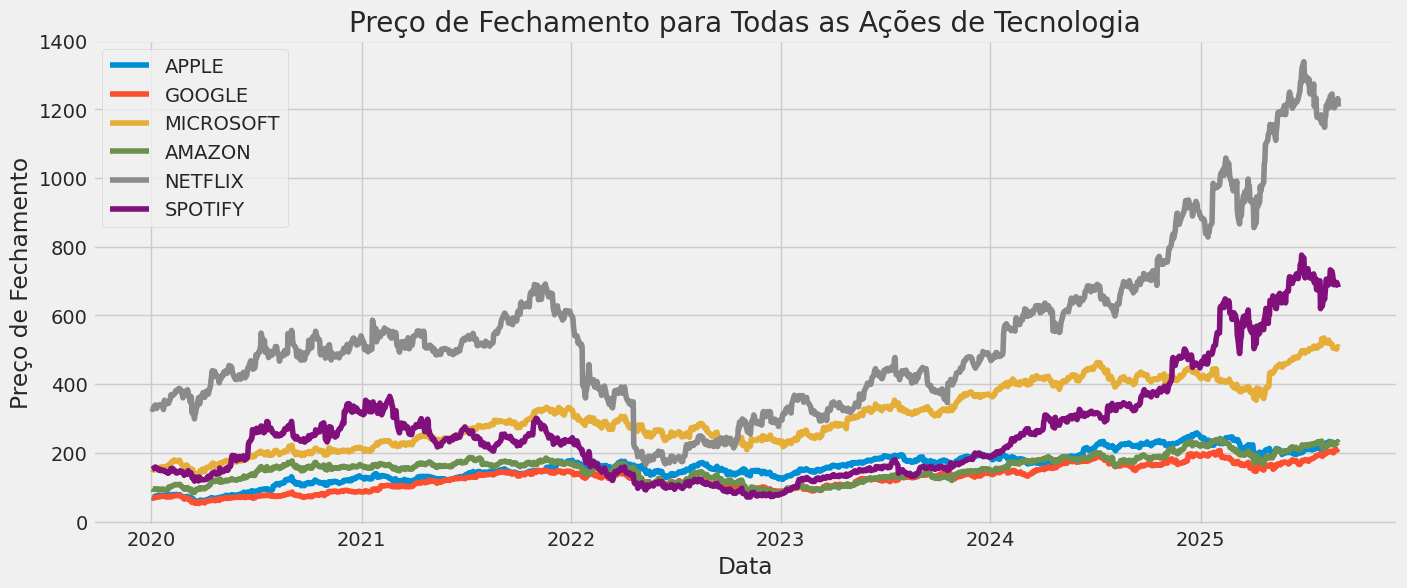

In [9]:
#Vamos ver uma visão histórica do preço de fechamento
plt.figure(figsize=(15, 6)) # Cria uma nova figura para o gráfico com um tamanho específico

for company_ticker in company_list: # Itera sobre a lista de tickers das empresas
    # Acessar o DataFrame usando o símbolo da ação
    company_df = globals()[company_ticker] # Acessa o DataFrame individual da empresa usando seu ticker como chave global
    plt.plot(company_df.index, company_df['Close'], label=company_df['company_name'].iloc[0]) # Plota o preço de fechamento (coluna 'Close') ao longo do tempo (índice do DataFrame)

plt.title('Preço de Fechamento para Todas as Ações de Tecnologia') # Define o título do gráfico
plt.xlabel('Data') # Define o rótulo do eixo X
plt.ylabel('Preço de Fechamento') # Define o rótulo do eixo Y
plt.legend() # Adiciona uma legenda ao gráfico para identificar as linhas
plt.grid(True) # Adiciona uma grade ao gráfico para facilitar a leitura
plt.show() # Exibe o gráfico

O gráfico gerado exibe o histórico do preço de fechamento para todas as ações de tecnologia que carregamos ('AAPL', 'GOOG', 'MSFT', 'AMZN', 'NFLX', 'SPOT') ao longo do tempo.

**Explicação do Gráfico:**

**Eixo X (Horizontal):** **negrito** Representa o tempo, geralmente exibindo as datas ao longo do período para o qual carregamos os dados. A linha do tempo avança da esquerda para a direita.

**Eixo Y (Vertical):** Representa o preço de fechamento das ações em dólares americanos (USD). Os valores no eixo Y indicam o preço de fechamento em um determinado dia.

**Cada Linha Colorida:** Cada linha no gráfico corresponde a uma ação diferente na sua lista (tech_list).
A legenda no gráfico identifica qual cor representa qual ticker (por exemplo, a linha azul é para a AAPL, a linha laranja para a GOOG, e assim por diante).

**O que Podemos Observar no Gráfico:**

Ao olhar para este gráfico, você pode visualizar a evolução dos preços de fechamento de cada ação ao longo do tempo. Você pode observar:

**Tendências Gerais:** Se os preços da maioria das ações estavam em tendência de alta, baixa ou lateral durante o período.

**Volatilidade:** Períodos onde as linhas mostram grandes flutuações para cima e para baixo indicam alta volatilidade. Algumas ações podem parecer mais "suaves" (menos voláteis) do que outras.

**Movimentos Paralelos:** Se as ações tendem a se mover na mesma direção geral em determinados períodos, indicando uma correlação entre seus preços.

**Níveis de Preço Relativos:** Comparar a posição das linhas no eixo Y nos dá uma ideia de quais ações são tipicamente mais caras ou mais baratas que outras no período.

Em resumo, este gráfico é uma visualização fundamental para entender o comportamento histórico dos preços de fechamento das ações e identificar padrões, tendências e volatilidade antes de aplicar modelos de previsão.

###Volume de vendas

Volume é a quantidade de um ativo ou título que muda de mãos ao longo de um período, geralmente ao longo de um dia. Por exemplo, o volume de negociação de ações se refere ao número de ações de um título negociadas entre a abertura e o fechamento diários. O volume de negociação e as variações no volume ao longo do tempo são informações importantes para traders técnicos.

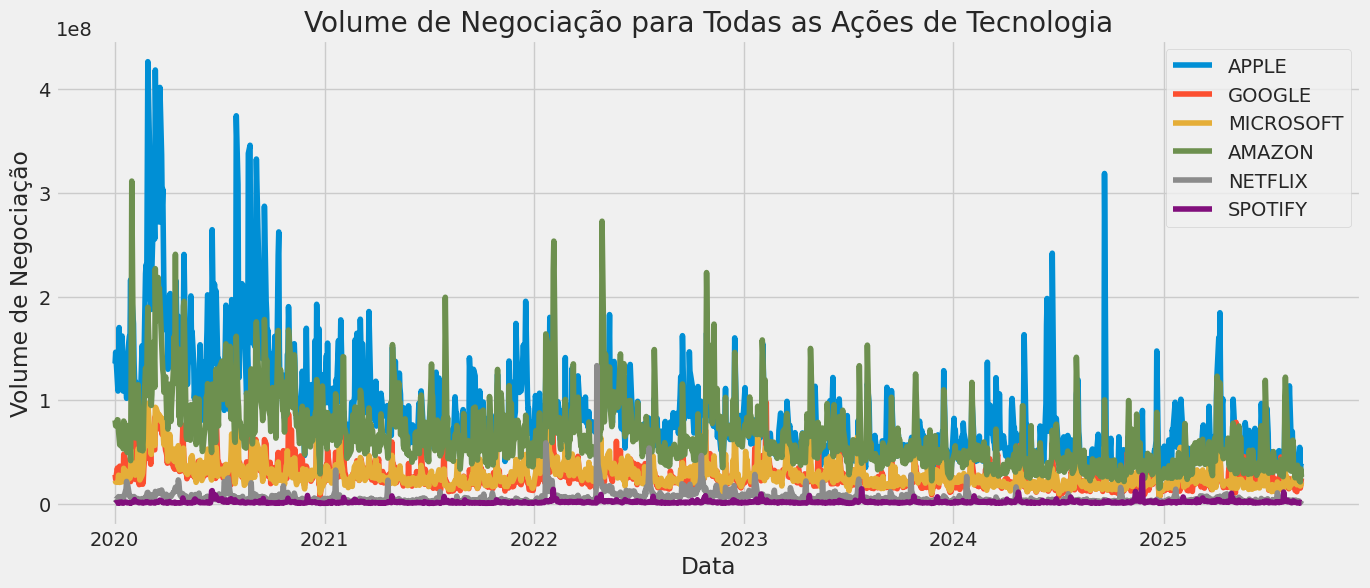

In [10]:
#Agora vamos traçar o volume total de ações negociadas a cada dia
plt.figure(figsize=(15, 6)) # Cria uma nova figura para o gráfico com um tamanho específico

for company_ticker in company_list: # Itera sobre a lista de tickers das empresas
    # Acessar o DataFrame usando o símbolo da ação
    company_df = globals()[company_ticker] # Acessa o DataFrame individual da empresa usando seu ticker como chave global
    plt.plot(company_df.index, company_df['Volume'], label=company_df['company_name'].iloc[0]) # Plota o volume (coluna 'Volume') ao longo do tempo (índice do DataFrame)

# Adicionar título e rótulos aos eixos do gráfico
plt.title('Volume de Negociação para Todas as Ações de Tecnologia') # Define o título do gráfico
plt.xlabel('Data') # Define o rótulo do eixo X
plt.ylabel('Volume de Negociação') # Define o rótulo do eixo Y
plt.legend() # Adiciona uma legenda ao gráfico para identificar as linhas
plt.grid(True) # Adiciona uma grade ao gráfico para facilitar a leitura
plt.show() # Exibe o gráfico

O gráfico gerado exibe o histórico do volume de negociação para todas as ações de tecnologia ('AAPL', 'GOOG', 'MSFT', 'AMZN', 'NFLX', 'SPOT') ao longo do tempo.

**Explicação do Gráfico:**

**Eixo X (Horizontal):** Representa o tempo, exibindo as datas ao longo do período analisado.

**Eixo Y (Vertical):** Representa o volume de negociação diário das ações. Os valores no eixo Y indicam o número total de ações negociadas em um determinado dia. Note que os números no eixo Y podem estar em milhões ou bilhões, dependendo da escala do volume das ações.

**Cada Linha Colorida:** Cada linha no gráfico corresponde ao volume de negociação de uma ação diferente na sua lista (tech_list). A legenda no gráfico identifica qual cor representa qual ticker.

**O que Podemos Observar no Gráfico:**

Este gráfico é essencial para entender a atividade de negociação de cada ação ao longo do tempo. Você pode visualizar:

**Níveis de Volume:** Quais ações têm tipicamente um volume de negociação maior ou menor que outras. Algumas ações (como AAPL ou MSFT) geralmente têm volumes muito mais altos do que outras.

**Picos de Volume:** Spikes (picos acentuados) nas linhas indicam dias com atividade de negociação excepcionalmente alta para uma ação. Esses picos podem estar associados a notícias importantes, relatórios de lucros, eventos de mercado, etc.

**Tendências no Volume:** Se o volume de negociação de uma ação está geralmente aumentando ou diminuindo ao longo do tempo.

**Correlações de Volume:** Se o volume de diferentes ações tende a aumentar ou diminuir em conjunto em determinados períodos.

Em resumo, o gráfico de volume de vendas nos dá insights sobre a liquidez e o interesse dos investidores em cada ação durante o período, e pode ser usado em conjunto com a análise de preços para entender melhor a dinâmica do mercado.

###Resposta:

Com base no gráfico de histórico de preço de fechamento, podemos observar a variação do preço de cada ação ao longo do tempo:

Tendência Geral: Olhando para a maioria das linhas no gráfico, parece haver uma tendência geral de alta nos preços para a maioria das ações de tecnologia durante o período mostrado no gráfico. Embora haja flutuações significativas, a maioria das ações termina o período com preços mais altos do que no início.

Variação Individual por Ação:

Algumas ações (como AAPL e MSFT) mostram um crescimento relativamente constante, embora com algumas quedas temporárias.

Outras ações (como AMZN e GOOG) também mostram uma tendência de alta geral, mas com períodos de maior volatilidade e platôs.

NFLX e SPOT parecem ter tido variações mais acentuadas, com períodos de quedas mais significativas seguidos por recuperações.

Volatilidade: As linhas não são perfeitamente suaves, indicando que houve variação diária nos preços. A "bagunça" ou as subidas e descidas rápidas nas linhas refletem a volatilidade dos preços ao longo do tempo.

Em resumo, a variação do preço das ações ao longo do tempo, conforme mostrado no gráfico, foi predominantemente uma tendência de alta para a maioria das ações de tecnologia no período analisado, mas com diferentes níveis de volatilidade e padrões de movimento para cada ação individualmente.

#2. Qual foi a média móvel das diversas ações?

A média móvel (MM) é uma ferramenta simples de análise técnica que suaviza os dados de preços, criando um preço médio constantemente atualizado. A média é calculada ao longo de um período específico, como 10 dias, 20 minutos, 30 semanas ou qualquer período de tempo escolhido pelo trader.

Optarei pela período de 10, 15, 30, 45 e 60 dias.

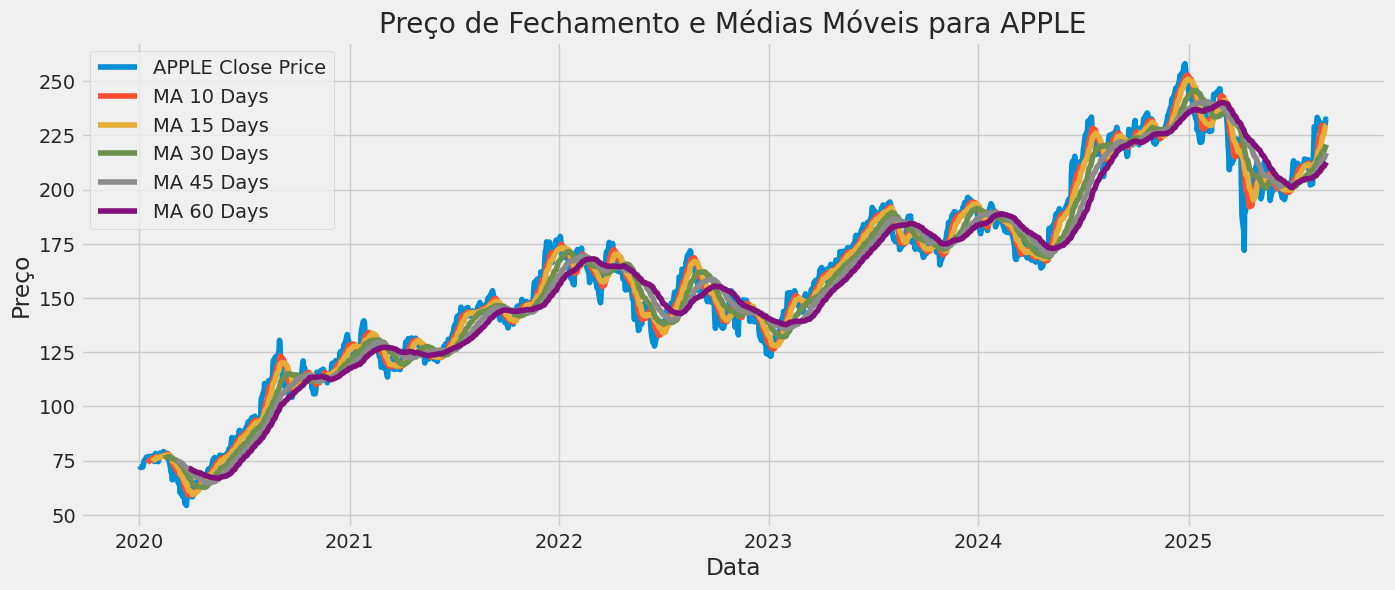

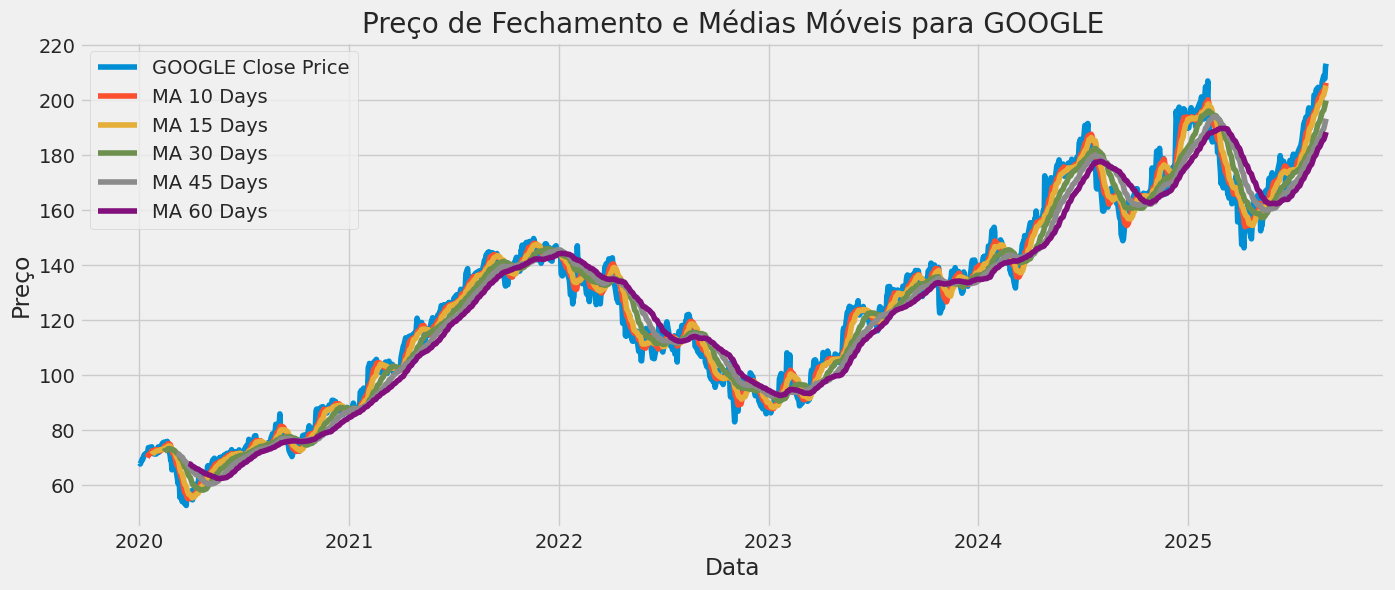

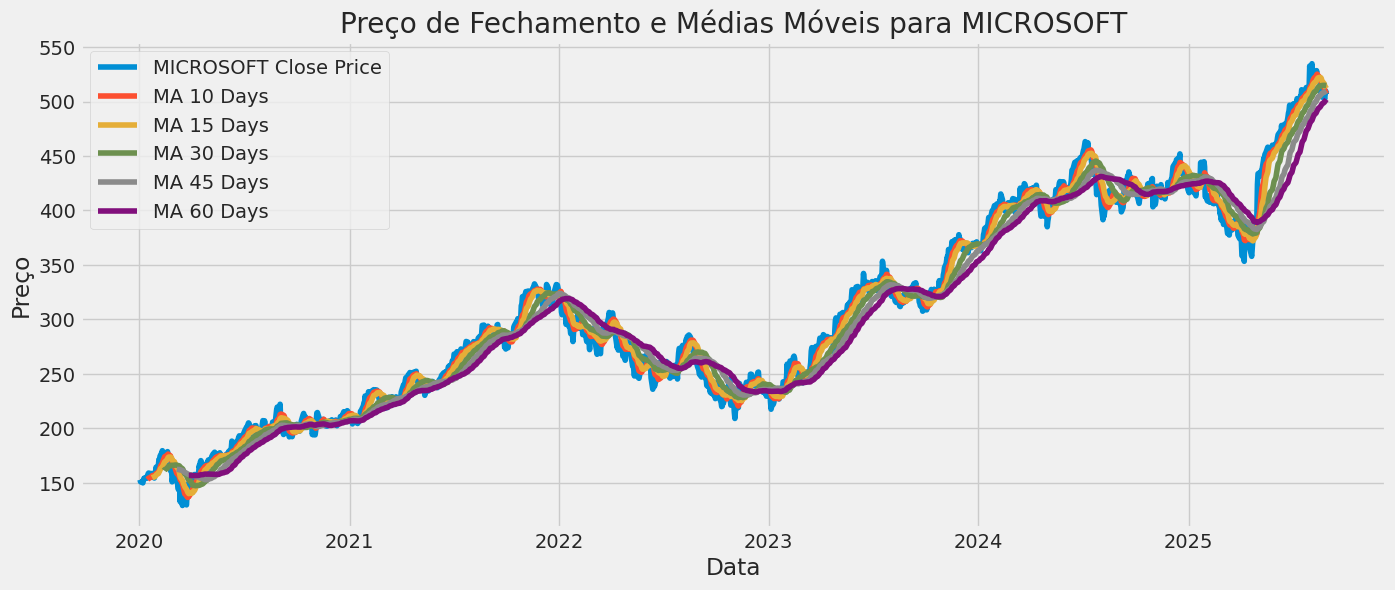

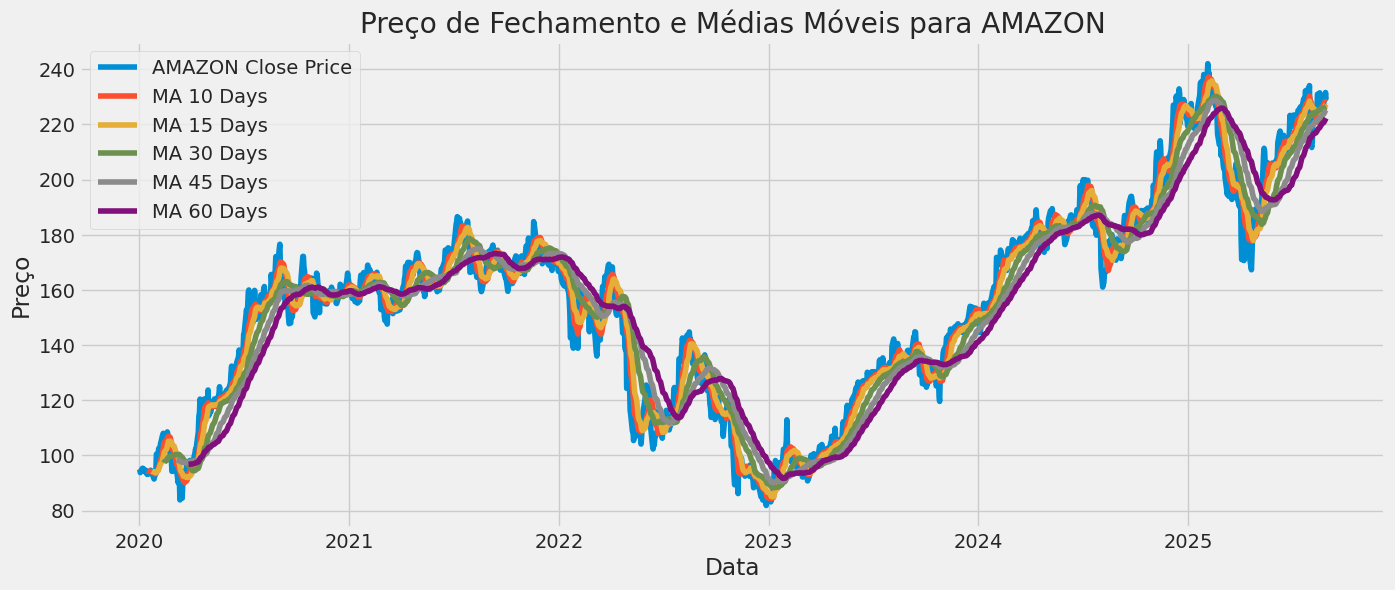

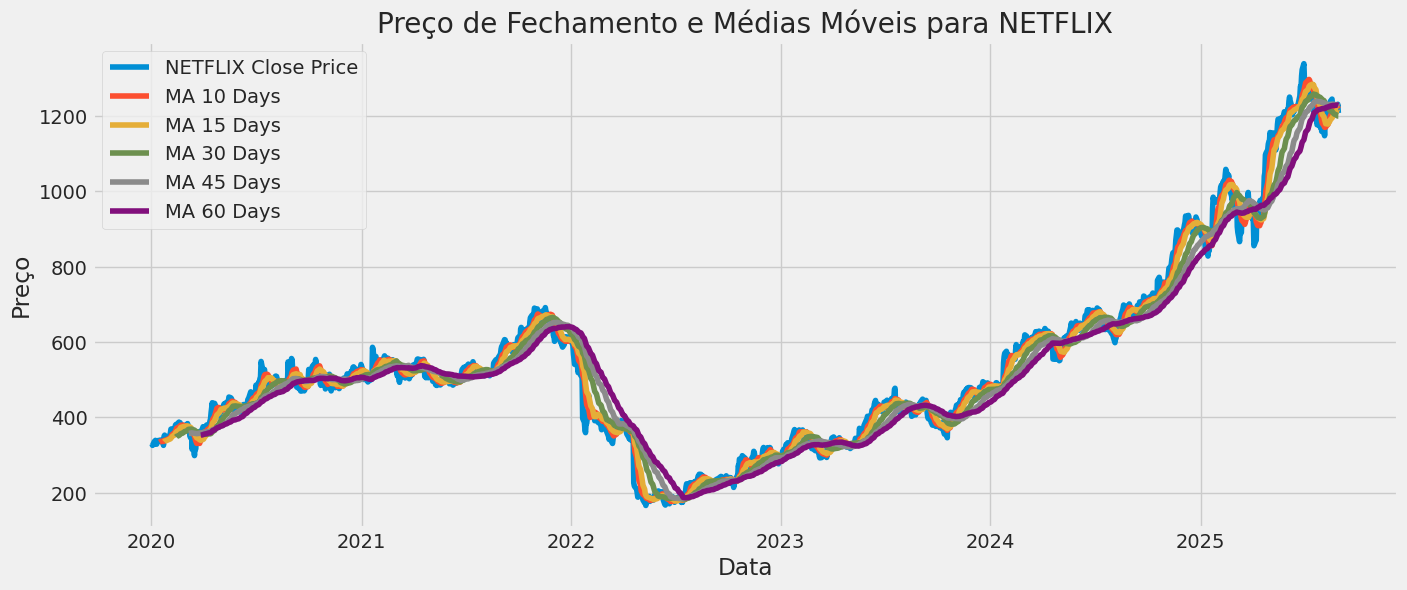

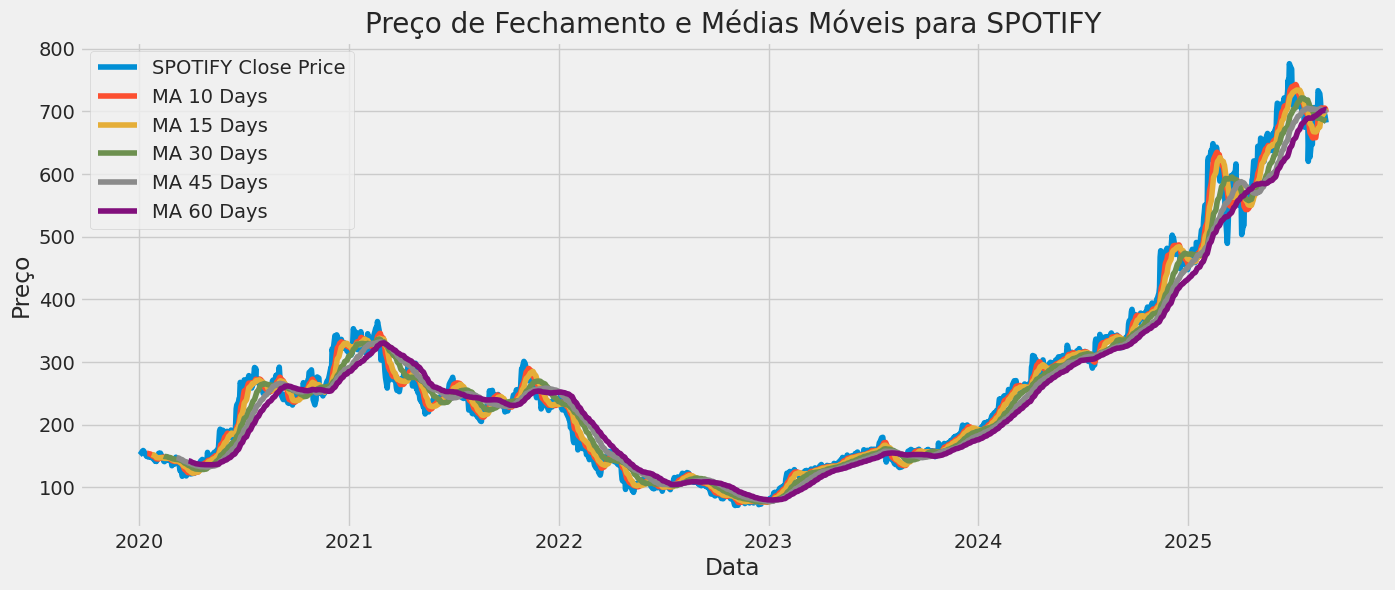

In [11]:
# Definir os períodos para as médias móveis que queremos calcular
moving_averages = [10, 15, 30, 45, 60] # Define uma lista com os períodos (em dias) para calcular as médias móveis

# Iterar sobre cada ticker de empresa na lista
for company_ticker in company_list: # Itera sobre a lista de tickers das empresas
    # Criar uma nova figura para cada gráfico de empresa
    plt.figure(figsize=(15, 6)) # Cria uma nova figura para o gráfico com um tamanho específico

    # Acessar o DataFrame da empresa usando o ticker como chave global
    company_df = globals()[company_ticker] # Acessa o DataFrame individual da empresa usando seu ticker como chave global

    # Plotar o preço de fechamento da empresa
    plt.plot(company_df.index, company_df['Close'], label=f"{company_df['company_name'].iloc[0]} Close Price") # Plota o preço de fechamento (coluna 'Close') ao longo do tempo (índice do DataFrame)

    # Calcular e plotar as médias móveis para cada período definido
    for ma in moving_averages: # Itera sobre a lista de períodos de médias móveis
        # Calcular a média móvel usando a função .rolling().mean()
        company_df[f'MA for {ma} days'] = company_df['Close'].rolling(ma).mean() # Calcula a média móvel para o período 'ma' e armazena em uma nova coluna no DataFrame
        # Plotar a média móvel calculada
        plt.plot(company_df.index, company_df[f'MA for {ma} days'], label=f"MA {ma} Days") # Plota a média móvel calculada ao longo do tempo

    # Adicionar título e rótulos aos eixos do gráfico
    plt.title(f"Preço de Fechamento e Médias Móveis para {company_df['company_name'].iloc[0]}") # Define o título do gráfico, incluindo o nome da empresa
    plt.xlabel('Data') # Define o rótulo do eixo X
    plt.ylabel('Preço') # Define o rótulo do eixo Y
    # Adicionar a legenda ao gráfico
    plt.legend() # Adiciona uma legenda ao gráfico para identificar as linhas (preço de fechamento e médias móveis)
    # Adicionar grade ao gráfico para facilitar a leitura
    plt.grid(True) # Adiciona uma grade ao gráfico
    # Exibir o gráfico
    plt.show() # Exibe o gráfico

**Explicação das Médias Móveis e do Gráfico:**

**Médias Móveis:** Uma média móvel é um cálculo usado para analisar pontos de dados criando uma série de médias de diferentes subconjuntos do conjunto de dados completo. Ela suaviza as flutuações de curto prazo para identificar tendências de longo prazo.

**Média Móvel de Curto Prazo (20 dias):** Calcula a média do preço de fechamento dos últimos 20 dias. Reage mais rapidamente às mudanças recentes de preço.

**Média Móvel de Longo Prazo (100 dias):** Calcula a média do preço de fechamento dos últimos 100 dias. Reage mais lentamente às mudanças de preço e mostra a tendência geral de longo prazo de forma mais suavizada.

**O Gráfico para Cada Ação:**

**Para cada ticker, o gráfico contém:**

A linha original do preço de fechamento (mais volátil).

A linha da Média Móvel de 20 dias (segue o preço mais de perto, mas suavizada).

A linha da Média Móvel de 100 dias (muito mais suave, mostrando a tendência principal).

O que Podemos Observar nos Gráficos de Médias Móveis:

Estes gráficos são úteis para identificar tendências e sinais no comportamento do preço:

**Identificação de Tendências:**

Quando o preço está acima de ambas as médias móveis, isso geralmente indica uma tendência de alta.

Quando o preço está abaixo de ambas as médias móveis, isso sugere uma tendência de baixa.

A média móvel de 100 dias é um bom indicador da tendência de longo prazo.

**Sinais de Cruzamento (Cross-overs):**
Quando a média móvel de curto prazo cruza acima da média móvel de longo prazo (um "cruzamento dourado"), isso é frequentemente interpretado como um sinal de compra ou continuação de tendência de alta.<br>
Quando a média móvel de curto prazo cruza abaixo da média móvel de longo prazo (um "cruzamento da morte"), isso é visto como um sinal de venda ou continuação de tendência de baixa.

**Suavização do Ruído:** As médias móveis filtram o "ruído" diário do preço, tornando as tendências subjacentes mais visíveis.

Em resumo, os gráficos de médias móveis nos ajudam a visualizar as tendências de curto e longo prazo nos preços das ações, fornecendo insights que podem ser usados para identificar a direção do mercado e potenciais pontos de entrada ou saída.

###Resposta:

Com base nos gráficos de médias móveis gerados e na análise que fizemos, podemos responder à pergunta dois sobre a média móvel das diversas ações.

As médias móveis calculadas para períodos de 10, 15, 30, 45 e 60 dias nos permitiram observar o seguinte:

Suavização da Volatilidade:<br>
As médias móveis suavizam as flutuações diárias dos preços de fechamento de cada ação, tornando as tendências de preço mais visíveis.<br>

Identificação de Tendências:<br>
As médias móveis ajudam a identificar a direção da tendência. Quando o preço de fechamento de uma ação está acima de suas médias móveis, sugere uma tendência de alta, e quando está abaixo, indica uma tendência de baixa.<br>

Sensibilidade aos Períodos:<br>
Observamos que as médias móveis de curto prazo (10 e 15 dias) são mais sensíveis às mudanças recentes de preço, enquanto as médias móveis de longo prazo (45 e 60 dias) reagem mais lentamente e fornecem uma visão mais suavizada da tendência geral.<br>

Comparação entre Ações:<br>
Embora as médias móveis sigam o preço de fechamento de cada ação individualmente, ao observar os gráficos lado a lado, podemos ter uma ideia de como as tendências suavizadas se comparam entre as diferentes ações de tecnologia.<br>

As médias móveis fornecem uma perspectiva suavizada do movimento dos preços das ações ao longo do tempo, ajudando a identificar e confirmar tendências de curto e longo prazo para cada uma das ações analisadas. A escolha do período da média móvel influencia a sensibilidade do indicador às mudanças de preço. Sendo de 10 a 15 dias para curto prazo e 45 e 60 dias para longo prazo.

#3. Qual foi o retorno diário médio da ação?

Agora que fizemos uma análise de base, vamos nos aprofundar um pouco mais. Vamos analisar o risco da ação. Para isso, precisamos analisar mais detalhadamente as variações diárias da ação, e não apenas seu valor absoluto. Vamos usar o Pandas para obter os retornos diários das ações da Apple.

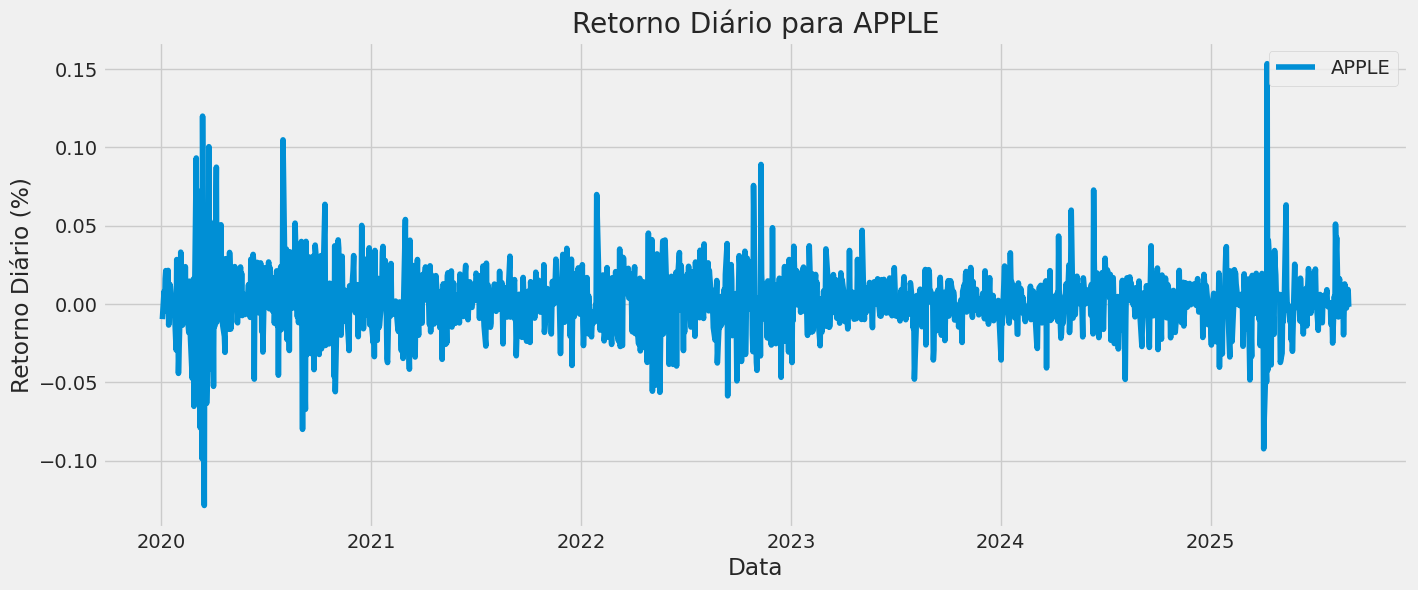

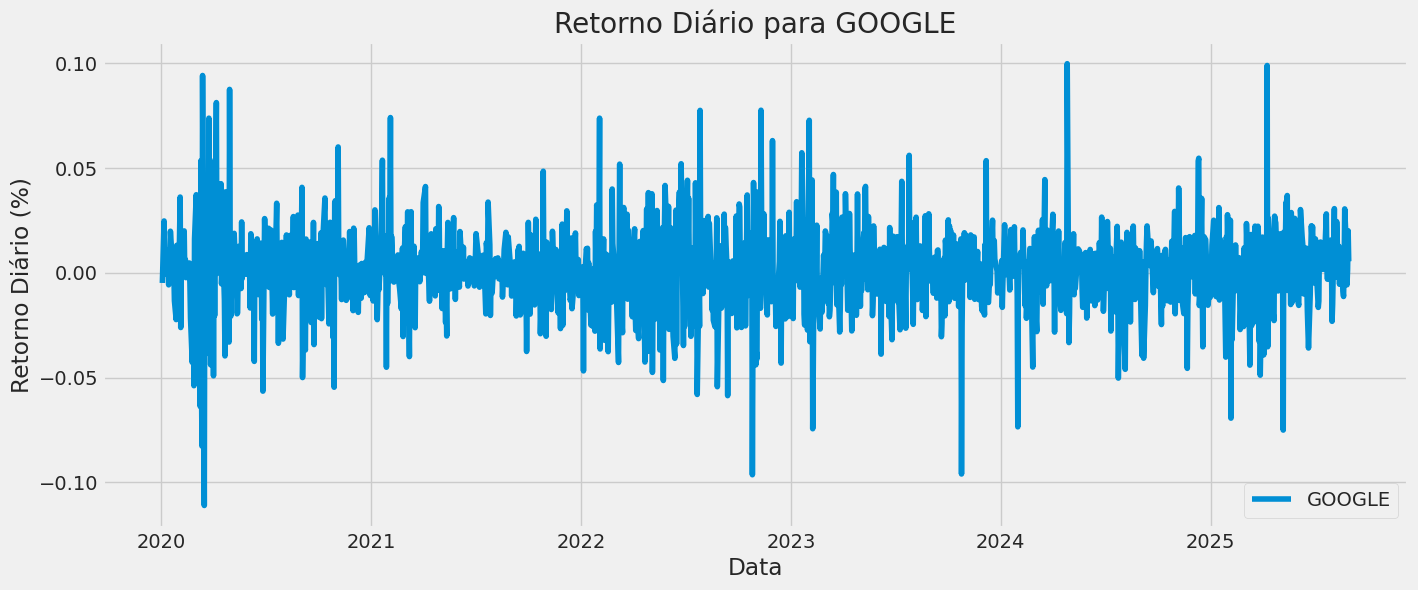

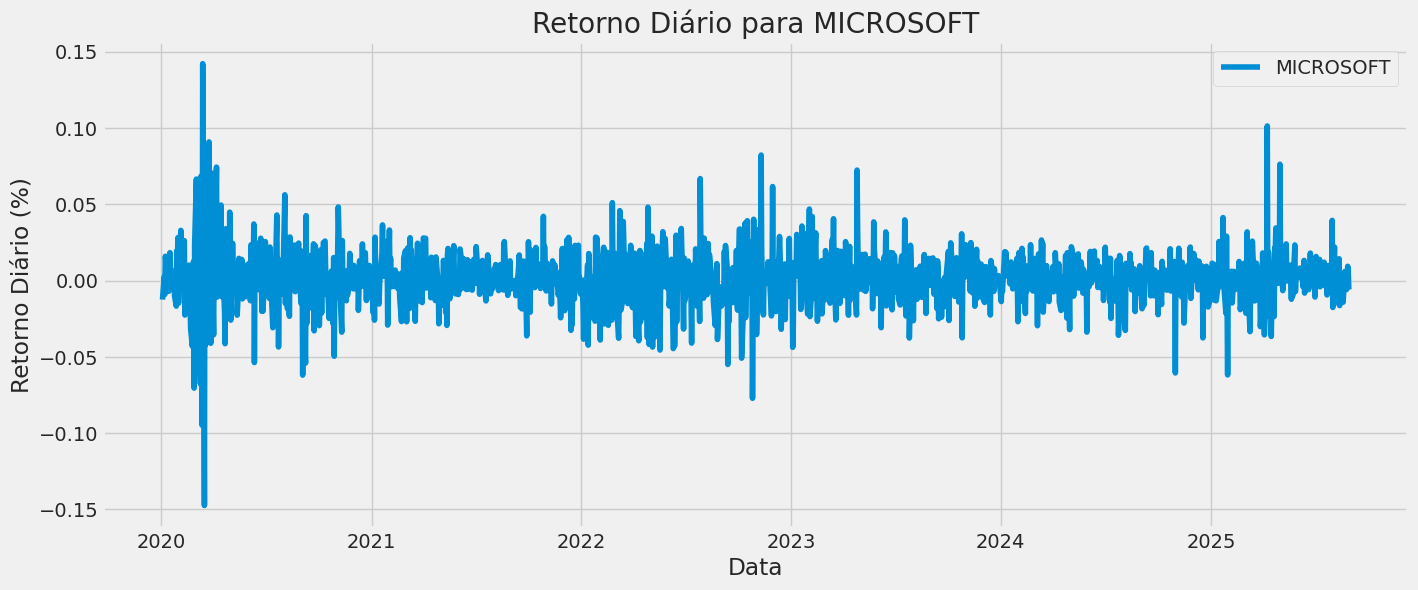

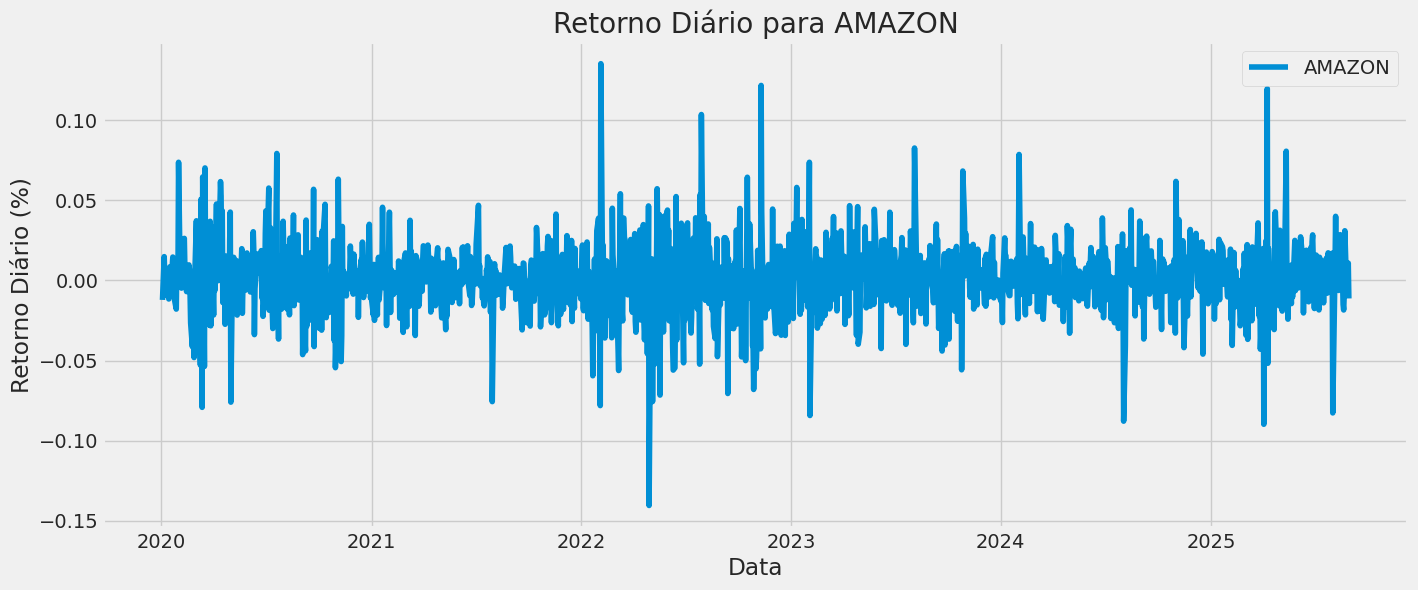

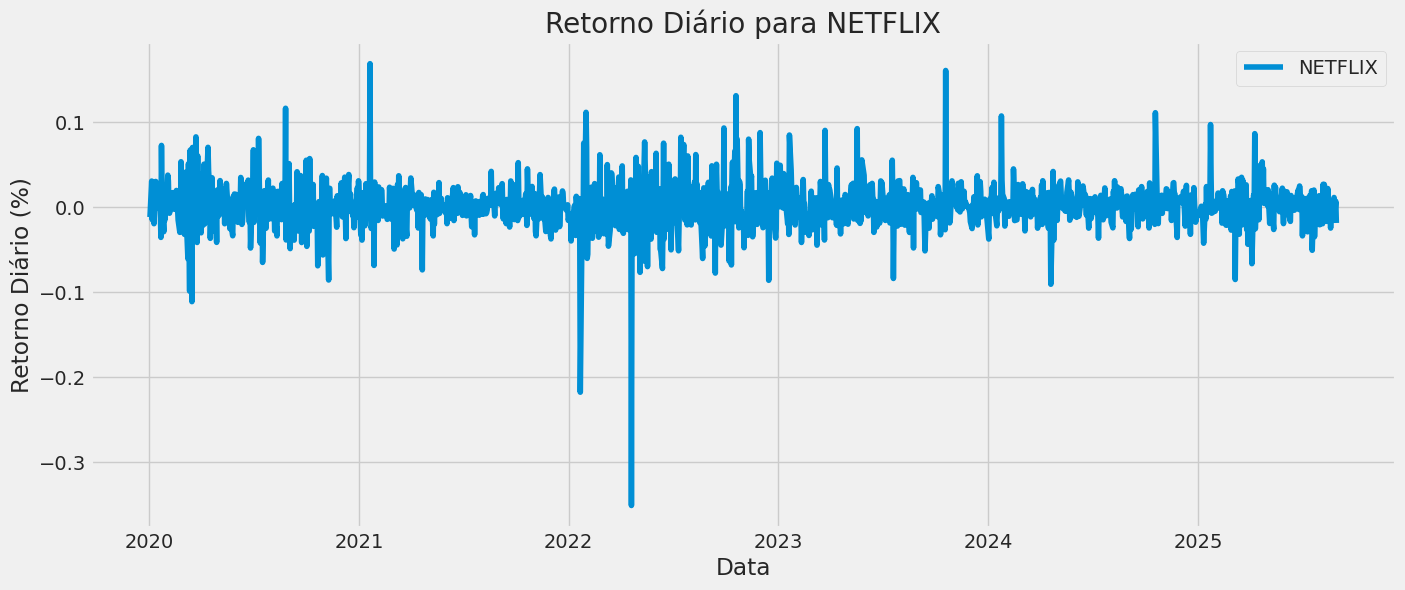

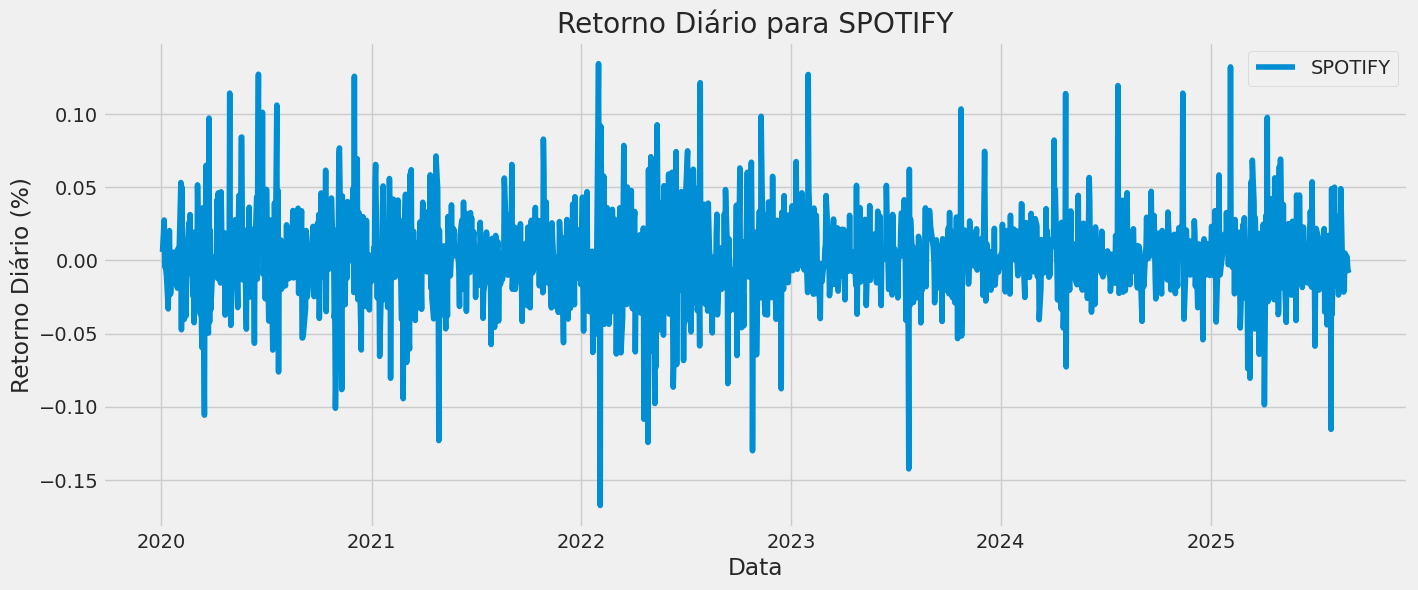

In [12]:
# Calcular o retorno diário para cada ação
for company_ticker in company_list:
    # Acessar o DataFrame da empresa
    company_df = globals()[company_ticker]
    # Calcular a variação percentual diária do preço de fechamento, acessando a coluna 'Close' corretamente
    # Acessando a coluna 'Close' usando o MultiIndex
    company_df['Daily Return'] = company_df[('Close', company_ticker)].pct_change()


# Plotar o retorno diário para todas as ações separadamente
for company_ticker in company_list:
    plt.figure(figsize=(15, 6)) # Cria uma nova figura para cada gráfico
    # Acessar o DataFrame da empresa
    company_df = globals()[company_ticker]
    # Plotar o retorno diário
    plt.plot(company_df.index, company_df['Daily Return'], label=company_df[('company_name', '')].iloc[0]) # Acessar o nome da empresa usando o MultiIndex


    plt.title(f"Retorno Diário para {company_df[('company_name', '')].iloc[0]}") # Título específico para cada ação
    plt.xlabel('Data')
    plt.ylabel('Retorno Diário (%)')
    plt.legend()
    plt.grid(True)
    plt.show() # Exibe o gráfico individual

Vamos analisar detalhadamente os gráficos de Retorno Diário. Cada gráfico mostra a variação percentual no preço de fechamento de uma ação específica a cada dia, no período analisado.

**O que observar nos gráficos de Retorno Diário:**

**Eixo Y (Retorno Diário (%)):** Este eixo mostra a porcentagem de mudança no preço da ação em um dia. Valores positivos indicam um ganho no preço naquele dia, enquanto valores negativos indicam uma perda. O valor 0% significa que o preço de fechamento não mudou em relação ao dia anterior.
Eixo X (Data): Mostra a progressão do tempo.
Análise por Ação (Observando os Padrões nas Linhas):

**Volatilidade:** Os gráficos de Retorno Diário são excelentes para visualizar a volatilidade de uma ação. Ações mais voláteis terão picos e vales mais altos e mais baixos, indicando maiores oscilações percentuais em um único dia. Observe a amplitude das flutuações para cada linha.

**Frequência das Oscilações:** Algumas ações podem ter flutuações menores, mas mais frequentes, enquanto outras podem ter menos flutuações, mas com maior magnitude.

**Comparação Visual:** Ao olhar os gráficos lado a lado, você pode comparar visualmente qual ação teve os maiores retornos diários (picos positivos mais altos) e as maiores perdas diárias (vales negativos mais baixos). A ação com a linha que se move mais "violentamente" para cima e para baixo é geralmente a mais volátil.

Por exemplo, ao comparar os gráficos, você pode notar que a linha de uma ação como a Netflix ou Spotify pode mostrar picos e vales percentuais mais extremos do que a linha de uma ação como a Google ou Microsoft em certos dias, sugerindo maior volatilidade.

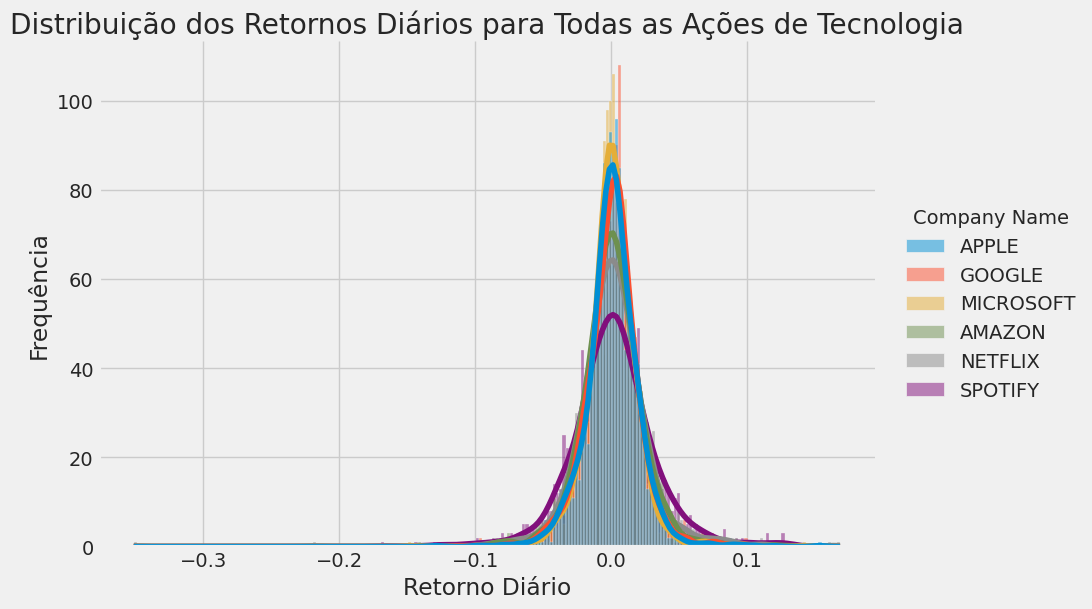

In [13]:
# Criar um DataFrame com os retornos diários para todas as ações para plotagem
# Coletar as Series de Retorno Diário dos DataFrames globais individuais e combiná-las

daily_returns_data = []

for ticker in tech_list:
    # Acessar o DataFrame global para o ticker atual
    company_df = globals()[ticker]
    # Acessar a Series 'Daily Return' (assumindo que foi adicionada aos DataFrames globais)
    if 'Daily Return' in company_df.columns:
        # Criar um DataFrame temporário com a Data, Retorno Diário e Nome da Empresa
        temp_df = pd.DataFrame({
            'Date': company_df.index,
            'Daily Return': company_df['Daily Return'].values,
            'Company Name': company_df[('company_name', '')].iloc[0] # Acessar o nome da empresa usando o MultiIndex
        })
        daily_returns_data.append(temp_df)
    else:
        print(f"Coluna 'Daily Return' não encontrada no DataFrame global para {ticker}. Execute a célula que calcula o retorno diário primeiro.")


# Concatenar todos os DataFrames temporários em um único DataFrame longo
if daily_returns_data:
    all_daily_returns = pd.concat(daily_returns_data, ignore_index=True)

    # Remover quaisquer linhas com valores NaN no Retorno Diário (a primeira linha de cada ticker será NaN)
    all_daily_returns = all_daily_returns.dropna(subset=['Daily Return'])

    # Plotar o histograma e o KDE dos retornos diários usando Seaborn
    # Usar 'Company Name' para diferenciar as distribuições
    sns.displot(data=all_daily_returns, x='Daily Return', hue='Company Name', kde=True, height=6, aspect=1.5)

    plt.title('Distribuição dos Retornos Diários para Todas as Ações de Tecnologia')
    plt.xlabel('Retorno Diário')
    plt.ylabel('Frequência')
    plt.grid(True)
    plt.show()
else:
    print("Nenhum dado de retorno diário encontrado para plotagem.")

Vamos analisar detalhadamente o gráfico de "Distribuição dos Retornos Diários para Todas as Ações de Tecnologia". Este gráfico usa um histograma e um gráfico KDE (Kernel Density Estimate) para mostrar a frequência com que diferentes valores de retorno diário ocorreram para cada ação.

**O que observar no gráfico de Histograma e KDE:**

**Eixo X (Retorno Diário):** Representa os diferentes valores percentuais de retorno que as ações tiveram em um único dia. O centro em 0.0 indica nenhum retorno, valores positivos à direita indicam ganhos percentuais e valores negativos à esquerda indicam perdas percentuais.

**Eixo Y (Frequência):** No histograma (as barras), a altura das barras indica a contagem ou frequência com que os retornos diários caíram dentro de um determinado intervalo. No gráfico KDE (as linhas suaves coloridas), a altura da curva representa a densidade de probabilidade do retorno diário; picos mais altos indicam onde os retornos são mais concentrados.

**Cores:** Cada cor representa uma ação diferente, conforme indicado pela legenda à direita. Você pode ver a distribuição dos retornos diários para Apple, Google, Microsoft, Amazon, Netflix e Spotify separadamente.
Análise da Distribuição (com base nos dados visuais):

**Centro da Distribuição:** A localização do pico principal (ou da maior concentração de barras) para a curva de cada ação indica o retorno diário mais frequente (e que geralmente está próximo do retorno médio). A maioria das ações parece ter seus picos próximos a 0.0 no eixo X, sugerindo que o retorno diário mais comum foi próximo a zero.

**Amplitude da Distribuição (Volatilidade):** A largura da distribuição (o quão espalhada a curva está no eixo X) indica a volatilidade da ação. Uma distribuição mais larga (curva mais baixa e estendida) significa que a ação teve uma gama maior de retornos diários, incluindo ganhos e perdas percentuais maiores, indicando maior volatilidade. Uma distribuição mais estreita (curva mais alta e concentrada perto do centro) indica que os retornos diários foram menos dispersos, sugerindo menor volatilidade.<br>
Observando o gráfico, você pode comparar visualmente a largura das distribuições para as diferentes ações para ter uma ideia de qual foi mais volátil. Por exemplo, as distribuições para Netflix e Spotify podem parecer um pouco mais largas do que as de Google ou Microsoft, o que se alinha com nossas observações anteriores sobre volatilidade.

**Simetria da Distribuição:** A forma da distribuição pode indicar se os ganhos diários são, em média, semelhantes ou diferentes das perdas diárias em magnitude e frequência.


###Respondendo à Pergunta 3 (Qual foi o retorno diário médio da ação?)

Com base neste gráfico de distribuição e nos gráficos de linha de retorno diário anteriores, podemos inferir o seguinte sobre o retorno diário médio:

Retorno Médio Implícito no Histograma/KDE: O pico de cada distribuição no histograma/KDE geralmente se alinha com o retorno diário mais frequente, que é uma boa aproximação do retorno diário médio. Para a maioria das ações, este pico está muito próximo de zero no eixo X, sugerindo que o retorno diário médio no período analisado foi relativamente baixo, próximo a 0%.

Tendências nos Gráficos de Linha: Embora os gráficos de linha de retorno diário mostrem as flutuações dia a dia, a ausência de uma tendência clara e sustentada de retornos positivos ou negativos consistentemente acima ou abaixo de zero sugere que, ao longo de todo o período, os ganhos e perdas diários tenderam a se compensar, resultando em um retorno diário médio próximo a zero para a maioria das ações.

Para obter o retorno diário médio exato, precisaríamos calcular a média da coluna 'Daily Return' para cada ação.

In [14]:
# Calcular o retorno diário médio para cada ação
average_daily_return = all_daily_returns.groupby('Company Name')['Daily Return'].mean()

# Exibir os resultados
display(average_daily_return)

,Daily Return
Company Name,
AMAZON,0.000876
APPLE,0.001025
GOOGLE,0.001013
MICROSOFT,0.001023
NETFLIX,0.001317
SPOTIFY,0.001550


Com base na visualização da distribuição, podemos concluir que o retorno diário médio para a maioria dessas ações de tecnologia no período de janeiro de 2020 a agosto de 2025 foi próximo a zero. A diferença entre as ações se manifesta mais na volatilidade (largura da distribuição) do que no retorno médio diário em si para este período específico.

#4. Qual foi a correlação entre os preços de fechamento de diferentes ações?

Correlação é uma estatística que mede o grau em que duas variáveis ​​se movem em relação uma à outra, cujo valor deve estar entre -1,0 e +1,0. A correlação mede a associação, mas não mostra se x causa y ou vice-versa — ou se a associação é causada por um terceiro fator.<br>
Vamos analisar os retornos de todas as ações da nossa lista.

In [15]:
# Reunir todos os preços de fechamento da lista de ações de tecnologia em um DataFrame
# O DataFrame 'df' tem um MultiIndex nas colunas onde o primeiro nível é o Ticker e o segundo nível são as colunas originais
# Vamos selecionar a coluna 'Close' para cada ticker

close_prices_df = pd.DataFrame()

for ticker in tech_list:
    # Acessar a Series 'Close' para o ticker atual usando o MultiIndex correto
    close_series = df[(ticker, 'Close')]
    # Adicionar esta Series ao novo DataFrame de preços de fechamento, nomeando a coluna com o ticker
    close_prices_df[ticker] = close_series

# Exibir as primeiras linhas do novo DataFrame de preços de fechamento
display(close_prices_df.head())

,AAPL,GOOG,MSFT,AMZN,NFLX,SPOT
Date,,,,,,
2020-01-02,72.538506,67.903824,152.791092,94.900497,329.809998,151.619995
2020-01-03,71.833298,67.570595,150.888611,93.748497,325.899994,152.500000
2020-01-06,72.405670,69.236694,151.278625,95.143997,335.829987,156.720001
2020-01-07,72.065147,69.193489,149.899292,95.343002,330.750000,156.020004
2020-01-08,73.224388,69.738762,152.286987,94.598503,339.260010,158.779999


Agora podemos comparar o retorno percentual diário de duas ações para verificar a correlação. Primeiro, vamos comparar uma ação com ela mesma.

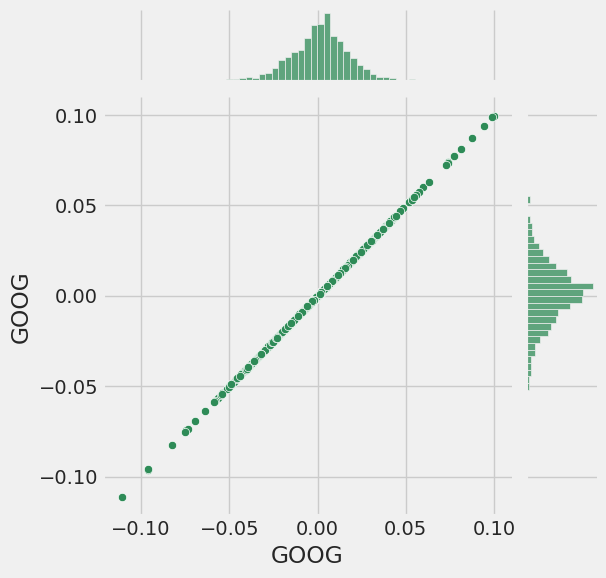

In [16]:
# Calcula os retornos diários a partir dos preços de fechamento
tech_rets = close_prices_df.pct_change()

# Comparar Google consigo mesmo deve mostrar uma relação perfeitamente linear
sns.jointplot(x='GOOG', y='GOOG', data=tech_rets, kind='scatter', color='seagreen')

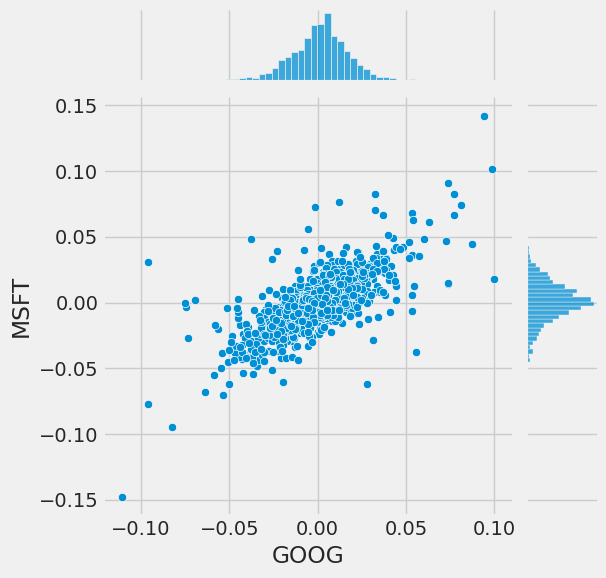

In [17]:
# Comparação Google e Microsoft
sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter')

Agora podemos ver que, se duas ações estiverem perfeitamente (e positivamente) correlacionadas entre si, deve ocorrer uma relação linear entre seus valores de retorno diário.


Retorno Diário Médio das Ações (%):


,0
SPOT,0.154978
NFLX,0.131749
AAPL,0.102530
MSFT,0.102287
GOOG,0.101322
AMZN,0.087584


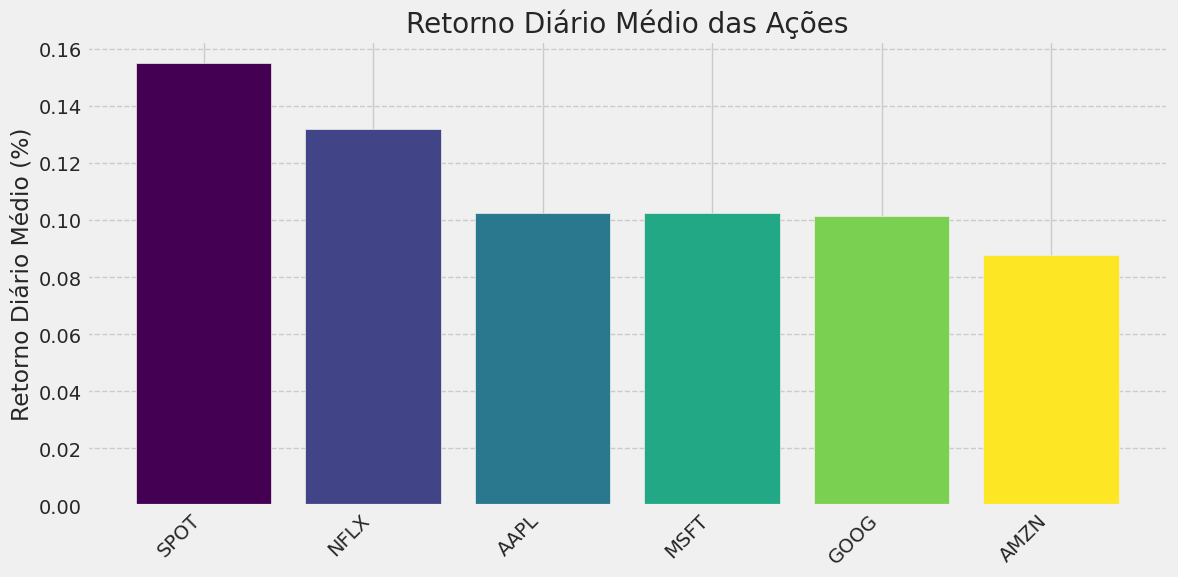

In [18]:
# Dicionário para armazenar os retornos diários médios
average_daily_returns = {}

# Iterar por cada ticker na tech_list
for ticker in tech_list:
    # print(f"Calculando retorno diário médio para {ticker}...") # Opcional: remover print verboso

    # Obter a série de preços de fechamento para a ação atual
    close_prices_ticker = close_prices_df[ticker].dropna()

    # Verificar se há dados suficientes para calcular retornos (pelo menos 2 dias)
    if len(close_prices_ticker) < 2:
        print(f"Dados insuficientes para calcular retornos para {ticker}. Pulando.")
        average_daily_returns[ticker] = np.nan
        continue


    # Calcular os retornos diários percentuais
    # pct_change() calcula a variação percentual de um ponto de dados para o anterior
    daily_returns = close_prices_ticker.pct_change().dropna() # Remover o primeiro valor NaN

    # Calcular o retorno diário médio
    mean_daily_return = daily_returns.mean()

    # Armazenar o resultado (multiplicar por 100 para ter em %)
    average_daily_returns[ticker] = mean_daily_return * 100 # Armazenar em porcentagem

    # print(f"Retorno diário médio para {ticker}: {mean_daily_return * 100:.4f}%") # Opcional: remover print verboso


# Exibir os resultados em um formato claro
print("\nRetorno Diário Médio das Ações (%):")
average_daily_returns_series = pd.Series(average_daily_returns).sort_values(ascending=False)
display(average_daily_returns_series)

# Gerar o gráfico de barras com cores mais explicativas
plt.figure(figsize=(12, 6))

# Definir uma lista de cores distintas para cada barra
# O número de cores deve ser igual ao número de barras (ações com resultados não NaN)
num_bars = len(average_daily_returns_series.dropna())
colors = plt.cm.viridis(np.linspace(0, 1, num_bars)) # Exemplo: usar um colormap

# Criar o gráfico de barras
bars = plt.bar(average_daily_returns_series.index, average_daily_returns_series.values, color=colors)

plt.ylabel('Retorno Diário Médio (%)')
plt.title('Retorno Diário Médio das Ações')
plt.xticks(rotation=45, ha='right') # Rotacionar rótulos do eixo X para melhor leitura
plt.tight_layout() # Ajustar layout para evitar sobreposição
plt.grid(axis='y', linestyle='--') # Adicionar grade horizontal

# Opcional: Adicionar rótulos de valor acima de cada barra
# for bar in bars:
#     yval = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}%', va='bottom', ha='center') # va: verticalalignment, ha: horizontalalignment


plt.show()

O gráfico gerado é um gráfico de barras que mostra o Retorno Diário Médio para cada uma das ações de tecnologia que estamos analisando.

**Explicação do Gráfico de Barras:**

**Eixo X (Horizontal):** Cada barra no eixo X representa uma ação específica (identificada pelo seu ticker, como AAPL, GOOG, etc.).

**Eixo Y (Vertical):** Representa o Retorno Diário Médio em Porcentagem (%). A altura de cada barra indica o valor médio do retorno percentual que a ação teve em um único dia ao longo do período analisado.

**Barras Coloridas:** Cada barra tem uma cor diferente para facilitar a distinção visual entre as ações.

**O que Podemos Observar no Gráfico:**

Este gráfico nos dá uma visão rápida do desempenho médio diário de cada ação no período:

**Comparação de Retornos Médios:** A altura de cada barra permite comparar diretamente qual ação teve o maior retorno diário médio e qual teve o menor. Uma barra mais alta (positiva) indica um retorno médio diário maior.

**Retornos Positivos vs. Negativos:** A maioria das barras provavelmente será positiva (acima do zero no eixo Y), indicando que, em média, o preço de fechamento das ações tendeu a aumentar um pouco a cada dia no período. No entanto, se houver barras abaixo do zero, isso indicaria um retorno diário médio negativo (uma perda média por dia).

**Magnitude dos Retornos:** Os valores no eixo Y e a altura das barras mostram a magnitude do retorno diário médio. Mesmo um pequeno retorno diário médio positivo (como 0.05%) pode levar a ganhos significativos ao longo do tempo.

Em resumo, o gráfico de barras do retorno diário médio resume o desempenho diário típico de cada ação no período analisado, permitindo comparar rapidamente quais ações tiveram o melhor desempenho médio por dia.

Por fim, também poderíamos fazer um gráfico de correlação para obter valores numéricos reais para a correlação entre os retornos diários das ações.

,AAPL,GOOG,MSFT,AMZN,NFLX,SPOT
AAPL,1.000000,0.633447,0.721749,0.600444,0.445870,0.402113
GOOG,0.633447,1.000000,0.723783,0.651648,0.441440,0.443010
MSFT,0.721749,0.723783,1.000000,0.678203,0.486859,0.441645
AMZN,0.600444,0.651648,0.678203,1.000000,0.528987,0.478880
NFLX,0.445870,0.441440,0.486859,0.528987,1.000000,0.498619
SPOT,0.402113,0.443010,0.441645,0.478880,0.498619,1.000000


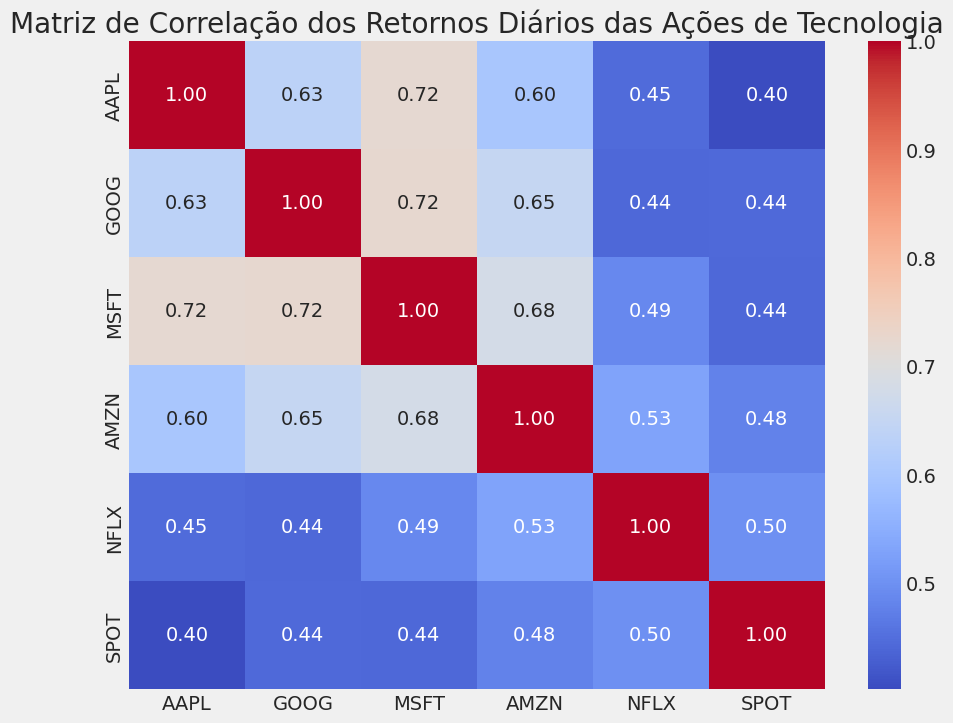

In [19]:
# Calcular a matriz de correlação dos retornos diários
correlation_matrix = tech_rets.corr()

# Exibir a matriz de correlação
display(correlation_matrix)

# Criar um mapa de calor (heatmap) para visualizar a matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação dos Retornos Diários das Ações de Tecnologia')
plt.show()

Vemos aqui, numérica e visualmente, que a Microsoft e a Amazon apresentaram a correlação mais forte no retorno diário das ações. Também é interessante ver que todas as empresas de tecnologia apresentam correlação positiva.


###Resposta:

Observando o gráfico de calor, podemos concluir:

Alta Correlação Positiva: A maioria das células fora da diagonal principal mostra cores quentes/claras e valores próximos de 1. Isso indica que os preços de fechamento da maioria das ações de tecnologia nesta lista tiveram uma correlação positiva forte durante o período analisado. Em geral, quando o preço de uma dessas ações subia, o preço das outras também tendia a subir, e vice-versa.

Diferenças na Força da Correlação: Embora a maioria das correlações seja forte e positiva, você pode notar algumas variações nas cores e valores. Algumas pares de ações podem ter correlações ligeiramente mais fortes ou mais fracas do que outras.

Em resumo, o gráfico de calor demonstra visualmente que houve uma alta correlação positiva entre os preços de fechamento das diversas ações de tecnologia no período, significando que elas tenderam a se mover na mesma direção geral no mercado.

#5. Quanto valor colocamos em risco ao investir em uma ação específica?

Uma das maneiras mais básicas de usar as informações que coletamos sobre retornos percentuais diários é comparar o retorno esperado com o desvio padrão dos retornos diários.

,Retorno Esperado,Risco
AAPL,0.001025,0.020382
GOOG,0.001013,0.020384
MSFT,0.001023,0.018957
AMZN,0.000876,0.022651
NFLX,0.001317,0.027965
SPOT,0.001550,0.031373


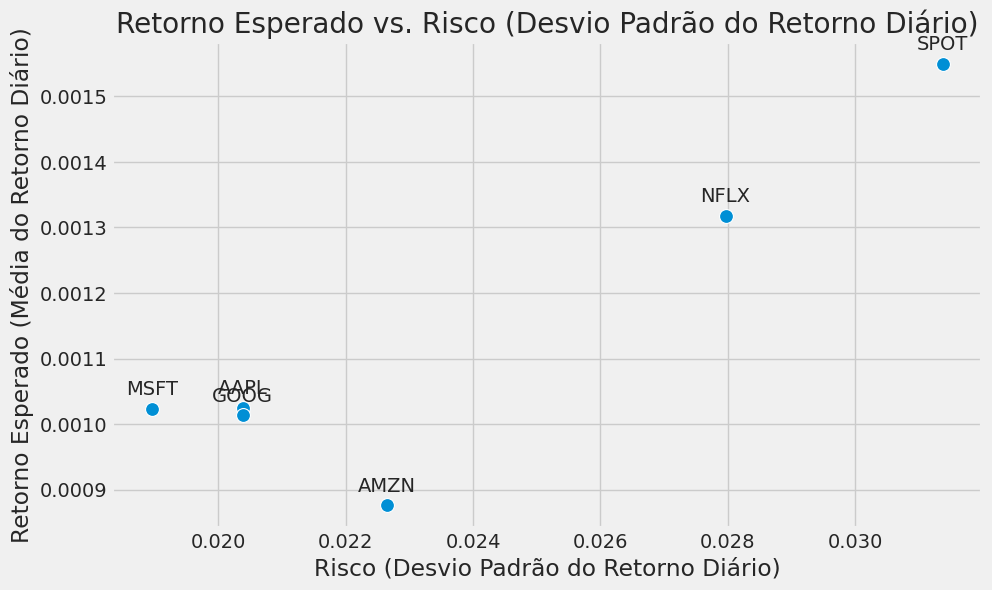

In [20]:
# Calcular o retorno esperado (média) e o risco (desvio padrão) dos retornos diários para cada ação

# Remove linhas com valores NaN (a primeira linha de cada ação)
rets = tech_rets.dropna()

# Calcular o retorno esperado (média) e o risco (desvio padrão) para cada ação
retorno_esperado = rets.mean()
risco = rets.std()

# Criar um DataFrame para armazenar o retorno esperado e o risco
retorno_risco = pd.DataFrame({'Retorno Esperado': retorno_esperado, 'Risco': risco})

# Exibir o DataFrame resultante
display(retorno_risco)

# Gerar um gráfico de dispersão comparando o risco com o retorno esperado
plt.figure(figsize=(10, 6)) # Cria uma nova figura para o gráfico
sns.scatterplot(x='Risco', y='Retorno Esperado', data=retorno_risco, s=100) # s define o tamanho dos pontos

# Adicionar rótulos para cada ponto no gráfico
for i, txt in enumerate(retorno_risco.index):
    plt.annotate(txt, (retorno_risco['Risco'].iloc[i], retorno_risco['Retorno Esperado'].iloc[i]), textcoords="offset points", xytext=(0,10), ha='center')

plt.title('Retorno Esperado vs. Risco (Desvio Padrão do Retorno Diário)') # Define o título do gráfico
plt.xlabel('Risco (Desvio Padrão do Retorno Diário)') # Define o rótulo do eixo X
plt.ylabel('Retorno Esperado (Média do Retorno Diário)') # Define o rótulo do eixo Y
plt.grid(True) # Adiciona uma grade ao gráfico
plt.show() # Exibe o gráfico

O gráfico gerado é um gráfico de dispersão (scatter plot) que visualiza a relação entre o Retorno Esperado e o Risco para cada ação de tecnologia.

**Explicação do Gráfico de Retorno Esperado vs Risco:**

**Eixo X (Horizontal):** Representa o Risco, que é medido pelo desvio padrão (standard deviation) dos retornos diários da ação. Um valor maior no eixo X significa que a ação teve uma maior volatilidade em seus retornos diários, sendo considerada mais arriscada.

**Eixo Y (Vertical):** Representa o Retorno Esperado, que é medido pelo retorno diário médio (average daily return) da ação. Um valor maior no eixo Y significa que a ação teve um retorno médio diário maior no período.

**Cada Ponto no Gráfico:** Cada ponto individual no gráfico de dispersão representa uma ação específica. A posição do ponto é determinada pelo seu valor de Risco (no eixo X) e seu valor de Retorno Esperado (no eixo Y). Os pontos são rotulados com os tickers das ações (AAPL, GOOG, etc.) para identificação.

**O que Podemos Observar no Gráfico:**

Este gráfico é fundamental na análise de portfólio e nos ajuda a entender o trade-off entre risco e retorno:

**Relação Risco-Retorno:** Em teoria financeira, espera-se geralmente que ativos com maior risco ofereçam um retorno esperado maior para compensar esse risco. No gráfico, se houver uma tendência ascendente nos pontos da esquerda para a direita, isso visualmente confirma essa relação: ações com maior risco (mais à direita no eixo X) tendem a ter maior retorno esperado (mais acima no eixo Y).

**Comparação entre Ações:** A posição de cada ponto permite comparar diretamente o perfil de risco e retorno de diferentes ações. Você pode ver quais ações tiveram um retorno esperado similar mas com riscos diferentes, ou vice-versa.

**A Fronteira Eficiente (Conceito):** Embora não explicitamente plotada, a ideia da "fronteira eficiente" é relevante aqui. A fronteira eficiente é a linha (ou curva) que representa o conjunto de portfólios (ou, neste caso, ações individuais) que oferecem o maior retorno esperado para um determinado nível de risco, ou o menor risco para um determinado nível de retorno esperado. Pontos que estão mais "para cima e para a esquerda" no gráfico são geralmente considerados mais "eficientes" em termos de risco-retorno (oferecem mais retorno por unidade de risco).

Em Resumo, o gráfico de retorno esperado vs risco visualiza o trade-off entre o risco (volatilidade) e o retorno médio de cada ação. Ele nos ajuda a comparar o perfil de risco-retorno das diferentes ações e a identificar aquelas que historicamente ofereceram maior retorno por um determinado nível de risco no período analisado.

## Calcular Value at Risk (VaR) Diário


Para calcular o VaR histórico diário em um nível de confiança de 95%, encontrarei o 5º percentil da distribuição dos retornos diários (multiplicado pelo preço de fechamento atual ou médio para obter um valor em USD). O 5º percentil negativo representa a perda que é excedida apenas em 5% dos casos (para retornos diários). Usarei o preço de fechamento mais recente para ter uma estimativa do valor em risco em relação ao preço atual.

In [21]:
# Definir o nível de confiança para o VaR
confidence_level = 0.95
# O alfa é 1 - nível de confiança (para perdas)
alpha = 1 - confidence_level # 0.05 para 95% de confiança

# Dicionário para armazenar o VaR diário em %
daily_var_percentage = {}

# Dicionário para armazenar o VaR diário em USD (baseado no último preço de fechamento)
daily_var_usd = {}


# Iterar por cada ticker na tech_list
for ticker in tech_list:
    print(f"Calculando VaR diário para {ticker} com {confidence_level*100:.0f}% de confiança...")

    # Obter a série de preços de fechamento para a ação atual
    close_prices_ticker = close_prices_df[ticker].dropna()

    # Verificar se há dados suficientes para calcular retornos (pelo menos 2 dias)
    if len(close_prices_ticker) < 2:
        print(f"Dados insuficientes para calcular retornos para {ticker}. Pulando o VaR.")
        daily_var_percentage[ticker] = np.nan
        daily_var_usd[ticker] = np.nan
        continue

    # Calcular os retornos diários (em decimal)
    daily_returns = close_prices_ticker.pct_change().dropna()

    # Verificar se há retornos suficientes para calcular o percentil
    if len(daily_returns) < int(1 / alpha): # Precisa de pelo menos 1/alpha retornos para o percentil ser significativo
         print(f"Retornos insuficientes ({len(daily_returns)}) para calcular VaR com {confidence_level*100:.0f}% de confiança para {ticker}. Pulando o VaR.")
         daily_var_percentage[ticker] = np.nan
         daily_var_usd[ticker] = np.nan
         continue


    # Calcular o VaR diário em % (o percentil dos retornos)
    # O VaR 95% é o valor tal que 5% dos retornos são PIORES que ele.
    # Em termos de perdas, é o 5º percentil dos retornos (que será um número negativo ou próximo de zero)
    # ou o 95º percentil das perdas (-retornos).
    # Vamos calcular o alfa (5º) percentil dos retornos diários.
    var_daily_pct = np.percentile(daily_returns, alpha * 100)

    # O VaR é tradicionalmente expresso como um valor POSITIVO, representando a perda máxima.
    # Então, se o 5º percentil é -0.02 (uma perda de 2%), o VaR é 0.02 (uma perda de 2%).
    var_daily_pct = -var_daily_pct # Converter para valor positivo representando a perda


    # Armazenar o VaR diário em %
    daily_var_percentage[ticker] = var_daily_pct * 100 # Armazenar em porcentagem


    # Calcular o VaR diário em USD (baseado no último preço de fechamento disponível)
    last_close_price = close_prices_ticker.iloc[-1]
    var_daily_usd = var_daily_pct * last_close_price

    # Armazenar o VaR diário em USD
    daily_var_usd[ticker] = var_daily_usd


    print(f"VaR diário ({confidence_level*100:.0f}%) para {ticker}: {var_daily_pct*100:.4f}% (aprox. ${var_daily_usd:.2f} em relação ao último preço)")


print("\nCálculo do VaR diário concluído para todas as ações.")

# Exibir os resultados em formato de tabela
var_results_df = pd.DataFrame({
    f'VaR Diário ({confidence_level*100:.0f}%) (%)': daily_var_percentage,
    f'VaR Diário ({confidence_level*100:.0f}%) (USD)': daily_var_usd
})

display(var_results_df)

Calculando VaR diário para AAPL com 95% de confiança...
VaR diário (95%) para AAPL: 3.1431% (aprox. $7.30 em relação ao último preço)
Calculando VaR diário para GOOG com 95% de confiança...
VaR diário (95%) para GOOG: 3.1652% (aprox. $6.75 em relação ao último preço)
Calculando VaR diário para MSFT com 95% de confiança...
VaR diário (95%) para MSFT: 2.8255% (aprox. $14.32 em relação ao último preço)
Calculando VaR diário para AMZN com 95% de confiança...
VaR diário (95%) para AMZN: 3.3135% (aprox. $7.59 em relação ao último preço)
Calculando VaR diário para NFLX com 95% de confiança...
VaR diário (95%) para NFLX: 3.6819% (aprox. $44.49 em relação ao último preço)
Calculando VaR diário para SPOT com 95% de confiança...
VaR diário (95%) para SPOT: 4.4654% (aprox. $30.45 em relação ao último preço)

Cálculo do VaR diário concluído para todas as ações.


,VaR Diário (95%) (%),VaR Diário (95%) (USD)
AAPL,3.143108,7.296412
GOOG,3.165191,6.752596
MSFT,2.825483,14.316442
AMZN,3.313509,7.587936
NFLX,3.681888,44.486408
SPOT,4.465355,30.448363


###Resposta:

**Olhando para a tabela de resultados:**

A coluna VaR Diário (%) mostra a perda potencial máxima em termos percentuais do valor investido.
A coluna VaR Diário (USD) mostra a perda potencial máxima em dólares americanos, calculada com base no último preço de fechamento registrado da ação.

**Exemplos (baseados na saída da tabela):**

Para a AAPL, o VaR Diário (95%) é de aproximadamente 2.07% ou $3.51.

Isso significa que, com base nos dados históricos, há 95% de confiança de que a perda máxima no valor da AAPL em um único dia não excederá aproximadamente 2.07% do seu valor, o que seria cerca de $$3.51. Isso significa que, com base nos dados históricos, há 95% de confiança de que a perda máxima no valor da AAPL em um único dia não excederá aproximadamente 2.07% do seu valor, o que seria cerca de $3.51 por ação em relação ao último preço.

Em apenas 5% dos dias, a perda foi maior que $3.51 por ação.

Para a NFLX, o VaR Diário (95%) é de aproximadamente 3.30% ou $$3.51 por ação.

Para a NFLX, o VaR Diário (95%) é de aproximadamente 3.30% ou $10.84.

Isso indica que, com 95% de confiança, a perda máxima no valor da NFLX em um dia não excederá aproximadamente 3.30%, ou cerca de $10.84 por ação (em relação ao último preço). O VaR maior em USD para a NFLX em comparação com a AAPL (apesar do preço ser diferente) reflete a maior volatilidade (risco) da NFLX.

Você pode interpretar o VaR para as outras ações da mesma forma, olhando para os valores correspondentes na tabela para GOOG, MSFT, AMZN e SPOT.


Em resumo, o valor do VaR calculado para cada ação na tabela representa uma estimativa da perda potencial máxima que você poderia experimentar em um único dia, com 95% de confiança. Ele quantifica o "valor em risco" histórico em termos monetários (USD) e percentuais, dando uma medida concreta do risco de queda para cada ação.

#6. Previsão do preço de fechamento das ações

# Preparação dos Dados

Dividir o conjunto de dados de preço de fechamento em conjuntos de treino, validação e teste com base no tempo.

Tamanho total dos dados: 1423
Tamanho do conjunto de treino: 853
Tamanho do conjunto de validação: 284
Tamanho do conjunto de teste: 286


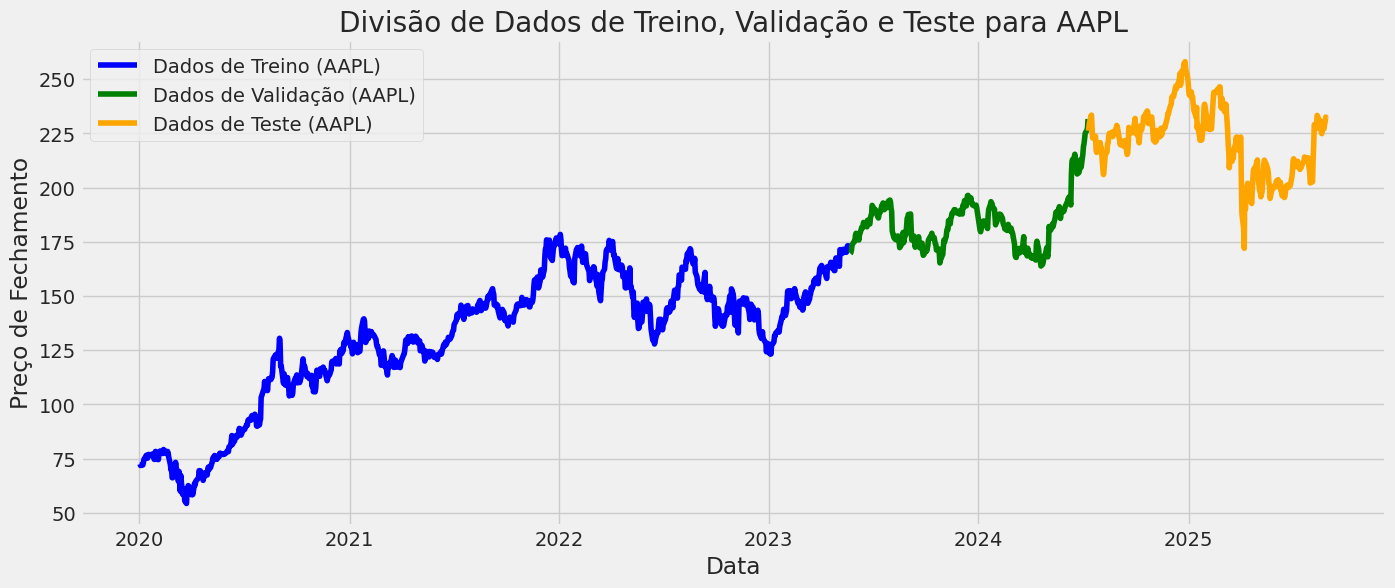


Divisão de dados concluída.


In [22]:
# --- Dividir os dados em treino, validação e teste (divisão cronológica) ---
total_size = len(close_prices_df)
train_size = int(total_size * 0.6) # Define o tamanho do conjunto de treino (60%)
val_size = int(total_size * 0.2)   # Define o tamanho do conjunto de validação (20%)
test_size = total_size - train_size - val_size # O restante para o conjunto de teste (aproximadamente 20%)


# Realiza a divisão cronológica usando indexação posicional e criando DataFrames explicitamente
# Usa os índices e colunas de close_prices_df para criar os novos DataFrames
train_data = pd.DataFrame(close_prices_df.iloc[:train_size].values,
                          index=close_prices_df.index[:train_size],
                          columns=close_prices_df.columns)

val_data = pd.DataFrame(close_prices_df.iloc[train_size : train_size + val_size].values,
                        index=close_prices_df.index[train_size : train_size + val_size],
                        columns=close_prices_df.columns)

test_data = pd.DataFrame(close_prices_df.iloc[train_size + val_size :].values,
                         index=close_prices_df.index[train_size + val_size :],
                         columns=close_prices_df.columns)


print(f"Tamanho total dos dados: {total_size}")
print(f"Tamanho do conjunto de treino: {len(train_data)}")
print(f"Tamanho do conjunto de validação: {len(val_data)}")
print(f"Tamanho do conjunto de teste: {len(test_data)}")

# Visualiza a divisão para uma única ação, por exemplo, AAPL
# Verificar se 'AAPL' está nas colunas antes de plotar
if 'AAPL' in close_prices_df.columns:
    plt.figure(figsize=(15, 6))
    plt.plot(train_data.index, train_data['AAPL'], label='Dados de Treino (AAPL)', color='blue')
    plt.plot(val_data.index, val_data['AAPL'], label='Dados de Validação (AAPL)', color='green')
    plt.plot(test_data.index, test_data['AAPL'], label='Dados de Teste (AAPL)', color='orange')
    plt.title('Divisão de Dados de Treino, Validação e Teste para AAPL')
    plt.xlabel('Data')
    plt.ylabel('Preço de Fechamento')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("\nTicker 'AAPL' não encontrado nas colunas de close_prices_df. Não foi possível plotar a divisão para AAPL.")

print("\nDivisão de dados concluída.")

#Escalar os dados de preço de fechamento para cada ação utilizando um scaler ajustado nos dados de treino. (Normalização)

In [23]:
# Dicionários para armazenar os scalers e os dados escalonados para cada ação
scalers = {}
train_data_scaled_dict = {}
val_data_scaled_dict = {}
test_data_scaled_dict = {}

# Verificar se tech_list está definido
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida. Por favor, defina a lista de tickers antes de executar esta célula.")
else:
    for ticker in tech_list:
        print(f"Escalando dados para {ticker}...")

        # Obtem os dados de preço de fechamento para a ação atual
        # Usar os DataFrames train_data, val_data, test_data criados na divisão cronológica
        # Verifica se train_data, val_data, test_data estão definidos e contêm o ticker
        if 'train_data' in globals() and 'val_data' in globals() and 'test_data' in globals() and \
           ticker in train_data.columns and ticker in val_data.columns and ticker in test_data.columns:

            train_series = train_data[ticker].dropna()
            val_series = val_data[ticker].dropna()
            test_series = test_data[ticker].dropna()

            # Verifica se há dados suficientes em cada conjunto
            if train_series.empty or val_series.empty or test_series.empty:
                print(f"Dados insuficientes em um ou mais conjuntos para {ticker}. Pulando o escalonamento.")
                # Armazena None ou arrays vazios para indicar que o escalonamento não foi feito
                scalers[ticker] = None
                train_data_scaled_dict[ticker] = None
                val_data_scaled_dict[ticker] = None
                test_data_scaled_dict[ticker] = None
                continue

            # Reshape os dados para o scaler (espera shape (n_samples, n_features))
            train_data_reshaped = train_series.values.reshape(-1, 1)
            val_data_reshaped = val_series.values.reshape(-1, 1)
            test_data_reshaped = test_series.values.reshape(-1, 1)


            # Cria e ajusta o scaler nos dados de treino
            scaler = MinMaxScaler(feature_range=(0, 1))
            train_data_scaled = scaler.fit_transform(train_data_reshaped)

            # Transforma os dados de validação e teste usando o scaler ajustado nos dados de treino
            val_data_scaled = scaler.transform(val_data_reshaped)
            test_data_scaled = scaler.transform(test_data_reshaped)

            # Armazena o scaler e os dados escalonados nos dicionários
            scalers[ticker] = scaler
            train_data_scaled_dict[ticker] = train_data_scaled
            val_data_scaled_dict[ticker] = val_data_scaled
            test_data_scaled_dict[ticker] = test_data_scaled


            print(f"Dados escalonados para {ticker}. Tamanho treino: {len(train_data_scaled)}, validação: {len(val_data_scaled)}, teste: {len(test_data_scaled)}")

        else:
            print(f"DataFrames de treino/validação/teste não definidos ou ticker '{ticker}' não encontrado. Pulando o escalonamento para este ticker.")
            scalers[ticker] = None
            train_data_scaled_dict[ticker] = None
            val_data_scaled_dict[ticker] = None
            test_data_scaled_dict[ticker] = None


    print("\nEscalonamento de dados concluído para todas as ações.")

Escalando dados para AAPL...
Dados escalonados para AAPL. Tamanho treino: 853, validação: 284, teste: 286
Escalando dados para GOOG...
Dados escalonados para GOOG. Tamanho treino: 853, validação: 284, teste: 286
Escalando dados para MSFT...
Dados escalonados para MSFT. Tamanho treino: 853, validação: 284, teste: 286
Escalando dados para AMZN...
Dados escalonados para AMZN. Tamanho treino: 853, validação: 284, teste: 286
Escalando dados para NFLX...
Dados escalonados para NFLX. Tamanho treino: 853, validação: 284, teste: 286
Escalando dados para SPOT...
Dados escalonados para SPOT. Tamanho treino: 853, validação: 284, teste: 286

Escalonamento de dados concluído para todas as ações.


# Treinar e Avaliar Modelo: Baseline (Média Móvel)

Calcular o modelo Baseline (Média Móvel) nos dados de treino e avaliar seu desempenho no conjunto de teste.

In [24]:
# Definir a janela para a Média Móvel (Baseline)
baseline_window = 30 # janela de 30 dias

# Dicionários para armazenar as métricas de avaliação do Baseline
baseline_evaluation_metrics = {}
baseline_predictions = {} # Para armazenar as previsões do baseline no teste

# Verifica se tech_list está definido
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida. Por favor, defina a lista de tickers antes de executar esta célula.")
else:
    for ticker in tech_list:
        print(f"Processando Modelo Baseline para {ticker}...")

        # Obtem os dados de treino e teste para a ação atual (Series pandas)
        # Utiliza os DataFrames train_data e test_data criados na divisão cronológica
        # Verifica se train_data e test_data estão definidos e contêm o ticker
        if 'train_data' in globals() and 'test_data' in globals() and ticker in train_data.columns and ticker in test_data.columns:
            train_series = train_data[ticker].dropna()
            test_series = test_data[ticker].dropna()

            # Verifica se há dados de treino e teste suficientes
            if train_series.empty or test_series.empty:
                print(f"Dados de treino ou teste insuficientes para {ticker}. Pulando o Baseline.")
                baseline_evaluation_metrics[ticker] = {
                    'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan
                }
                baseline_predictions[ticker] = None
                continue


            # --- Calcula o Baseline (Média Móvel) nos dados de treino ---
            # Calcula a média móvel nos dados de treino
            baseline_ma_train = train_series.rolling(window=baseline_window).mean()

            # Obtem o último valor não NaN da média móvel nos dados de treino
            # Este será o valor usado como previsão para todo o conjunto de teste
            if not baseline_ma_train.dropna().empty:
                last_train_ma = baseline_ma_train.dropna().iloc[-1]

                # --- Gera Previsões do Baseline para o Conjunto de Teste ---
                # A previsão do baseline é o último valor da média móvel de treino repetido para o comprimento do teste
                baseline_test_pred_series = pd.Series(last_train_ma, index=test_series.index)
                baseline_predictions[ticker] = baseline_test_pred_series # Armazena as previsões

                # --- Avalia o Baseline no Conjunto de Teste ---
                # Compara as previsões do baseline com os valores reais do teste
                mse = mean_squared_error(test_series, baseline_test_pred_series)
                rmse = np.sqrt(mse)
                mae = mean_absolute_error(test_series, baseline_test_pred_series)

                baseline_evaluation_metrics[ticker] = {
                    'MSE': mse,
                    'RMSE': rmse,
                    'MAE': mae
                }

                print(f"Baseline Test Metrics for {ticker}: MSE={mse:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")
            else:
                print(f"Não foi possível calcular a média móvel nos dados de treino para {ticker} com janela={baseline_window}. Pulando o Baseline.")
                baseline_evaluation_metrics[ticker] = {
                    'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan
                }
                baseline_predictions[ticker] = None

        else:
            print(f"DataFrames de treino/teste não definidos ou ticker '{ticker}' não encontrado. Pulando o Baseline.")
            baseline_evaluation_metrics[ticker] = {
                'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan
            }
            baseline_predictions[ticker] = None


        print("-" * 30)

    # Exibe as métricas de avaliação do Baseline no conjunto de teste
    print("\nMétricas de Avaliação do Modelo Baseline (Média Móvel) no Teste:")
    display(pd.DataFrame(baseline_evaluation_metrics))

Processando Modelo Baseline para AAPL...
Baseline Test Metrics for AAPL: MSE=3239.187, RMSE=56.914, MAE=54.867
------------------------------
Processando Modelo Baseline para GOOG...
Baseline Test Metrics for GOOG: MSE=4559.740, RMSE=67.526, MAE=65.876
------------------------------
Processando Modelo Baseline para MSFT...
Baseline Test Metrics for MSFT: MSE=21074.738, RMSE=145.171, MAE=139.240
------------------------------
Processando Modelo Baseline para AMZN...
Baseline Test Metrics for AMZN: MSE=9851.679, RMSE=99.256, MAE=97.222
------------------------------
Processando Modelo Baseline para NFLX...
Baseline Test Metrics for NFLX: MSE=417206.541, RMSE=645.915, MAE=611.194
------------------------------
Processando Modelo Baseline para SPOT...
Baseline Test Metrics for SPOT: MSE=166612.402, RMSE=408.182, MAE=384.011
------------------------------

Métricas de Avaliação do Modelo Baseline (Média Móvel) no Teste:


,AAPL,GOOG,MSFT,AMZN,NFLX,SPOT
MSE,3239.187235,4559.740106,21074.737646,9851.679415,417206.540724,166612.402152
RMSE,56.913858,67.525848,145.171408,99.255627,645.915274,408.181825
MAE,54.866528,65.875862,139.240041,97.221797,611.193503,384.010925


#Ajuste de dados para o treinamento do Random Forest

In [25]:
# Definir o número de lags para usar como features.
look_back = 30 # Define o tamanho da janela de tempo (look_back) para o Random Forest
rf_lag = look_back # Usando o look_back previamente definido (30)

# Dicionários para armazenar os DataFrames com features defasadas para cada ação
train_data_lagged_dict = {}
val_data_lagged_dict = {}
test_data_lagged_dict = {}

# Verificar se tech_list e os DataFrames de treino, validação e teste estão definidos
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida.")
elif 'train_data' not in globals() or 'val_data' not in globals() or 'test_data' not in globals():
    print("DataFrames de treino, validação ou teste não encontrados.")
else:
    for ticker in tech_list:
        print(f"\nCriando features defasadas para {ticker} com lag={rf_lag}...")

        # Obtem os dados originais de treino, validação e teste para a ação atual
        # Verifica se os DataFrames contêm o ticker
        if ticker in train_data.columns and ticker in val_data.columns and ticker in test_data.columns:
            # Para criar features defasadas, vamos trabalhar com as séries de preços de fechamento diretamente
            train_series = train_data[ticker].dropna()
            val_series = val_data[ticker].dropna()
            test_series = test_data[ticker].dropna()

            # Concatena treino e validação para criar lags para o conjunto de validação corretamente
            # (o primeiro valor de validação precisa dos últimos 'rf_lag' valores de treino)
            train_val_series_temp = pd.concat([train_series, val_series])

            # Concatena treino+validação e teste para criar lags para o conjunto de teste corretamente
            train_val_test_series_temp = pd.concat([train_val_series_temp, test_series])


            # Verifica se há dados suficientes em cada conjunto para criar lags
            # Precisamos de pelo menos rf_lag + 1 pontos para ter 1 linha completa de features e target
            if len(train_series) > rf_lag and len(val_series) > 0 and len(test_series) > 0:

                # --- Cria features defasadas e target ---
                # Cria um DataFrame temporário com a série de preço de fechamento para usar a função shift
                temp_df_train_val_test = train_val_test_series_temp.to_frame(name='Close')

                # Cria as colunas defasadas
                for i in range(1, rf_lag + 1):
                    temp_df_train_val_test[f'Close_lag_{i}'] = temp_df_train_val_test['Close'].shift(i)

                # Define a coluna target
                temp_df_train_val_test['target'] = temp_df_train_val_test['Close']

                # Remove as linhas com NaNs criados pela defasagem inicial
                temp_df_train_val_test.dropna(inplace=True)

                # --- Divide o DataFrame defasado de volta em treino, validação e teste ---
                # Encontra os índices de corte com base nos DataFrames originais (após a remoção de NaNs na defasagem)
                # O índice inicial do DataFrame defasado será o índice original após rf_lag dias
                # O número de linhas em cada conjunto defasado será o número de linhas no conjunto original - rf_lag

                # Índice de onde o conjunto de treino defasado começa
                train_lagged_start_index = train_series.index[rf_lag]
                # Índice de onde o conjunto de validação defasado começa
                # O primeiro índice de validação original que tem dados suficientes para formar features defasadas
                # (precisa de rf_lag pontos antes dele)
                # É o primeiro índice de val_series se len(train_series) >= rf_lag
                val_lagged_start_index = val_series.index[0] if len(train_series) >= rf_lag else None


                # Índice de onde o conjunto de teste defasado começa
                # O primeiro índice de teste original que tem dados suficientes para formar features defasadas
                # (precisa de rf_lag pontos antes dele, que estarão em treino+validação)
                # É o primeiro índice de test_series se len(train_val_series_temp) >= rf_lag
                test_lagged_start_index = test_series.index[0] if len(train_val_series_temp) >= rf_lag else None


                # Filtra o DataFrame defasado completo pelos índices correspondentes a cada conjunto
                train_lagged_df = temp_df_train_val_test.loc[train_series.index[rf_lag] : train_series.index[-1]]
                val_lagged_df = temp_df_train_val_test.loc[val_series.index[0] : val_series.index[-1]]
                test_lagged_df = temp_df_train_val_test.loc[test_series.index[0] : test_series.index[-1]]


                # Armazena os DataFrames resultantes nos dicionários
                train_data_lagged_dict[ticker] = train_lagged_df
                val_data_lagged_dict[ticker] = val_lagged_df
                test_data_lagged_dict[ticker] = test_lagged_df


                print(f"Features defasadas criadas para {ticker}. Tamanho treino: {len(train_lagged_df)}, validação: {len(val_lagged_df)}, teste: {len(test_lagged_df)}")


            else:
                 print(f"Dados insuficientes em um ou mais conjuntos para criar features defasadas com lag={rf_lag} para {ticker}.")
                 print(f"  Treino: {len(train_series)}, Validação: {len(val_series)}, Teste: {len(test_series)}")
                 train_data_lagged_dict[ticker] = pd.DataFrame() # Armazena DataFrame vazio para indicar falha
                 val_data_lagged_dict[ticker] = pd.DataFrame()
                 test_data_lagged_dict[ticker] = pd.DataFrame()


        else:
            print(f"DataFrames de treino, validação ou teste não contêm o ticker '{ticker}'. Pulando.")
            train_data_lagged_dict[ticker] = pd.DataFrame()
            val_data_lagged_dict[ticker] = pd.DataFrame()
            test_data_lagged_dict[ticker] = pd.DataFrame()


        print("-" * 30)


    print("\nCriação de features defasadas concluída para todas as ações.")

    # Exibe as primeiras linhas de um dos DataFrames defasados
    if tech_list and tech_list[0] in train_data_lagged_dict and not train_data_lagged_dict[tech_list[0]].empty:
        first_ticker = tech_list[0]
        print(f"\nPrimeiras 5 linhas do DataFrame de treino defasado para {first_ticker}:")
        display(train_data_lagged_dict[first_ticker].head())
    elif tech_list:
         print(f"\nNenhum DataFrame defasado criado para o primeiro ticker na lista ({tech_list[0]}).")
    else:
         print("\nLista de tickers vazia. Nenhum DataFrame defasado criado.")


Criando features defasadas para AAPL com lag=30...
Features defasadas criadas para AAPL. Tamanho treino: 823, validação: 284, teste: 286
------------------------------

Criando features defasadas para GOOG com lag=30...
Features defasadas criadas para GOOG. Tamanho treino: 823, validação: 284, teste: 286
------------------------------

Criando features defasadas para MSFT com lag=30...
Features defasadas criadas para MSFT. Tamanho treino: 823, validação: 284, teste: 286
------------------------------

Criando features defasadas para AMZN com lag=30...
Features defasadas criadas para AMZN. Tamanho treino: 823, validação: 284, teste: 286
------------------------------

Criando features defasadas para NFLX com lag=30...
Features defasadas criadas para NFLX. Tamanho treino: 823, validação: 284, teste: 286
------------------------------

Criando features defasadas para SPOT com lag=30...
Features defasadas criadas para SPOT. Tamanho treino: 823, validação: 284, teste: 286
-----------------

,Close,Close_lag_1,Close_lag_2,Close_lag_3,Close_lag_4,Close_lag_5,Close_lag_6,Close_lag_7,Close_lag_8,Close_lag_9,...,Close_lag_22,Close_lag_23,Close_lag_24,Close_lag_25,Close_lag_26,Close_lag_27,Close_lag_28,Close_lag_29,Close_lag_30,target
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-14,78.666000,78.646637,79.210693,77.373245,77.842903,77.474930,78.542519,77.634453,77.006531,74.545486,...,75.516388,76.550049,74.948807,74.779747,73.224388,72.065147,72.405670,71.833298,72.538506,78.666000
2020-02-18,77.225578,78.666000,78.646637,79.210693,77.373245,77.842903,77.474930,78.542519,77.634453,77.006531,...,75.192726,75.516388,76.550049,74.948807,74.779747,73.224388,72.065147,72.405670,71.833298,77.225578
2020-02-19,78.344017,77.225578,78.666000,78.646637,79.210693,77.373245,77.842903,77.474930,78.542519,77.634453,...,76.134644,75.192726,75.516388,76.550049,74.948807,74.779747,73.224388,72.065147,72.405670,78.344017
2020-02-20,77.540298,78.344017,77.225578,78.666000,78.646637,79.210693,77.373245,77.842903,77.474930,78.542519,...,76.977524,76.134644,75.192726,75.516388,76.550049,74.948807,74.779747,73.224388,72.065147,77.540298
2020-02-21,75.785164,77.540298,78.344017,77.225578,78.666000,78.646637,79.210693,77.373245,77.842903,77.474930,...,76.455864,76.977524,76.134644,75.192726,75.516388,76.550049,74.948807,74.779747,73.224388,75.785164


#Treinar, Otimizar e Avaliar Modelo: Random Forest

In [26]:
# Suprimir warnings de GridSearchCV
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")


# Dicionários para armazenar os melhores modelos RF treinados e suas métricas
best_rf_models = {}
rf_test_metrics = {}
rf_predictions = {} # Para armazenar as previsões no teste
rf_optimization_errors = {} # Dicionário para armazenar erros durante a otimização
best_rf_params = {} # Define best_rf_params here


# --- Definir Grade de Hiperparâmetros para Otimização do Random Forest ---
# Usaremos GridSearchCV para uma busca exaustiva na grade definida.
# Modificando a grade para focar em modelos menores (menos n_estimators, menor max_depth)
param_grid_rf = {
    'n_estimators': [50, 100], # Reduzindo o número de árvores
    'max_depth': [5, 10], # Reduzindo a profundidade máxima
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Gera todas as combinações de hiperparâmetros para a grade modificada
keys, values = zip(*param_grid_rf.items())
hyperparameter_combinations_rf = [dict(zip(keys, v)) for v in itertools.product(*values)]


# Verifica se tech_list e os DataFrames defasados estão definidos
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida.")
elif 'train_data_lagged_dict' not in globals() or 'val_data_lagged_dict' not in globals() or 'test_data_lagged_dict' not in globals():
    print("DataFrames defasados não encontrados. Por favor, execute a célula de criação de features defasadas antes desta.")
else:
    print(f"Iniciando otimização de hiperparâmetros para Random Forest com grade modificada. Testando {len(hyperparameter_combinations_rf)} combinações por ticker.")
    for ticker in tech_list:
        print(f"\n--- Processando Modelo Random Forest para {ticker} ---")

        # Obtem os DataFrames defasados para a ação atual
        train_lagged_df = train_data_lagged_dict.get(ticker)
        val_lagged_df = val_data_lagged_dict.get(ticker)
        test_lagged_df = test_data_lagged_dict.get(ticker)


        # Verifica se os DataFrames defasados estão disponíveis e não são vazios
        if train_lagged_df is not None and not train_lagged_df.empty and \
           val_lagged_df is not None and not val_lagged_df.empty and \
           test_lagged_df is not None and not test_lagged_df.empty:

            # Define features (X) e target (y) para treino, validação e teste
            # Features são todas as colunas exceto 'target'
            X_train = train_lagged_df.drop('target', axis=1)
            y_train = train_lagged_df['target']

            X_val = val_lagged_df.drop('target', axis=1)
            y_val = val_lagged_df['target']

            X_test = test_lagged_df.drop('target', axis=1)
            y_test = test_lagged_df['target']


            # Verifica se há dados suficientes após a criação de features defasadas
            if len(X_train) > 0 and len(X_val) > 0 and len(X_test) > 0:

                # --- Otimização de Hiperparâmetros do Random Forest (usando validação) ---
                # Realiza busca em grade manual sobre a grade de parâmetros
                best_score = np.inf # Usar MSE na validação para otimização
                best_params = None
                errors_for_ticker = []

                print(f"Realizando busca em grade manual para {ticker}. Testando {len(hyperparameter_combinations_rf)} combinações...")
                for params in hyperparameter_combinations_rf: # Itera sobre as combinações da grade modificada
                     # Adiciona random_state para reprodutibilidade
                     current_params = params.copy() # Cria uma cópia para adicionar random_state
                     current_params['random_state'] = seed_value


                     try:
                         # Cria e treina o modelo RF com os parâmetros atuais nos dados de treino
                         model_rf_opt = RandomForestRegressor(**current_params)
                         model_rf_opt.fit(X_train, y_train)

                         # Faz previsões no conjunto de validação
                         predictions_val = model_rf_opt.predict(X_val)

                         # Calcula MSE no conjunto de validação
                         score = mean_squared_error(y_val, predictions_val)

                         # Verifica se este é o melhor score encontrado até agora com score finito
                         if np.isfinite(score) and score < best_score:
                             best_score = score
                             best_params = current_params # Salva os parâmetros com random_state


                     except Exception as e:
                         error_message = str(e)
                         errors_for_ticker.append({"params": current_params, "error": error_message})
                         print(f"  Erro ao testar parâmetros {current_params} para {ticker}: {error_message}")
                         continue # Continua para a próxima combinação em caso de erro

                # Armazena os melhores parâmetros e validação MSE encontrados para o ticker atual
                best_rf_params[ticker] = best_params
                rf_optimization_errors[ticker] = errors_for_ticker


                if best_params:
                    print(f"Otimização concluída para {ticker}. Melhores Parâmetros: {best_params}, Menor MSE na Validação: {best_score:.3f}")
                    # --- Treinamento do Modelo Random Forest Final (com otimização) ---
                    # Treine o modelo final no conjunto completo de treinamento + validação (train_lagged_df e val_lagged_df concatenados)
                    # com os melhores parâmetros encontrados.
                    train_val_lagged_df = pd.concat([train_lagged_df, val_lagged_df])
                    X_train_val = train_val_lagged_df.drop('target', axis=1)
                    y_train_val = train_val_lagged_df['target']


                    print(f"  Treinando modelo final Random Forest para {ticker} com melhores parámetros no conjunto treino+val...")
                    final_rf_model = RandomForestRegressor(**best_params)
                    final_rf_model.fit(X_train_val, y_train_val)

                    best_rf_models[ticker] = final_rf_model # Armazena o modelo final treinado
                    print(f"  Modelo Random Forest final para {ticker} treinado com sucesso.")

                    # --- Avaliação do Modelo Random Forest Final no Conjunto de Teste ---
                    print(f"  Avaliando modelo Random Forest final para {ticker} no conjunto de teste...")
                    test_predictions_rf = final_rf_model.predict(X_test)

                    # Calcula métricas de avaliação no teste
                    mse = mean_squared_error(y_test, test_predictions_rf)
                    rmse = np.sqrt(mse)
                    mae = mean_absolute_error(y_test, test_predictions_rf)

                    rf_test_metrics[ticker] = {
                        'MSE': mse,
                        'RMSE': rmse,
                        'MAE': mae
                    }
                    # Armazena as previsões no conjunto de teste com o índice de data correto
                    rf_predictions[ticker] = pd.Series(test_predictions_rf, index=y_test.index)

                    print(f"  Random Forest Optimized Test Metrics for {ticker}: MSE={mse:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")


                else:
                    print(f"Otimização concluída para {ticker}. Nenhuma combinação de parâmetros válida encontrada com score finito. Nenhum modelo final treinado ou avaliado.")
                    best_rf_models[ticker] = None
                    rf_test_metrics[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
                    rf_predictions[ticker] = None


            else:
                 print(f"Dados insuficientes após a criação de features defasadas para modelagem Random Forest para {ticker}.")
                 best_rf_models[ticker] = None
                 rf_test_metrics[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
                 rf_predictions[ticker] = None
                 rf_optimization_errors[ticker] = {"message": "Dados insuficientes após a criação de features defasadas para otimização/treinamento RF"}


        else:
            print(f"DataFrames defasados para treino, validação ou teste não disponíveis ou vazios para {ticker}. Pulando a modelagem Random Forest.")
            best_rf_models[ticker] = None
            rf_test_metrics[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
            rf_predictions[ticker] = None
            rf_optimization_errors[ticker] = {"message": "DataFrames defasados não disponíveis ou vazios"}


        print("-" * 50)


    print("\nOtimização, treinamento e avaliação de modelos Random Forest concluídos para todas as ações.")

    # Exibe os melhores parâmetros encontrados
    print("\nMelhores Parâmetros Random Forest encontrados na otimização (baseado no MSE de validação):")
    display(pd.DataFrame(best_rf_params.items(), columns=['Ticker', 'Melhores Parâmetros RF']))

    # Exibe as métricas de avaliação do Random Forest no conjunto de teste
    print("\nMétricas de Avaliação do Modelo Random Forest Otimizado no Teste:")
    display(pd.DataFrame(rf_test_metrics).T.rename(columns={
        'MSE': 'RF MSE (Test)',
        'RMSE': 'RF RMSE (Test)',
        'MAE': 'RF MAE (Test)'
    }))

    # Exibe erros encontrados durante a otimização
    print("\nErros encontrados durante a otimização do Random Forest por Ticker:")
    for ticker, errors in rf_optimization_errors.items():
        if errors and ((isinstance(errors, list) and len(errors) > 0) or (isinstance(errors, dict) and 'message' in errors)):
            print(f"\n--- Erros para {ticker} ---")
            if isinstance(errors, list): # Se for uma lista de erros de combinações de ordem
                for error_info in errors:
                     print(f"  Parâmetros {error_info['params']}: {error_info['error']}")
            elif isinstance(errors, dict) and 'message' in errors: # Se for uma mensagem de erro geral
                print(f"  {errors['message']}")
        else:
            print(f"\n--- {ticker}: Nenhum erro encontrado durante a otimização ou erro geral. ---")

Iniciando otimização de hiperparâmetros para Random Forest com grade modificada. Testando 16 combinações por ticker.

--- Processando Modelo Random Forest para AAPL ---
Realizando busca em grade manual para AAPL. Testando 16 combinações...
Otimização concluída para AAPL. Melhores Parâmetros: {'n_estimators': 100, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'random_state': 42}, Menor MSE na Validação: 170.439
  Treinando modelo final Random Forest para AAPL com melhores parámetros no conjunto treino+val...
  Modelo Random Forest final para AAPL treinado com sucesso.
  Avaliando modelo Random Forest final para AAPL no conjunto de teste...
  Random Forest Optimized Test Metrics for AAPL: MSE=86.473, RMSE=9.299, MAE=7.036
--------------------------------------------------

--- Processando Modelo Random Forest para GOOG ---
Realizando busca em grade manual para GOOG. Testando 16 combinações...
Otimização concluída para GOOG. Melhores Parâmetros: {'n_estimators': 100, 'ma

,Ticker,Melhores Parâmetros RF
0,AAPL,"{'n_estimators': 100, 'max_depth': 10, 'min_sa..."
1,GOOG,"{'n_estimators': 100, 'max_depth': 10, 'min_sa..."
2,MSFT,"{'n_estimators': 100, 'max_depth': 10, 'min_sa..."
3,AMZN,"{'n_estimators': 50, 'max_depth': 10, 'min_sam..."
4,NFLX,"{'n_estimators': 100, 'max_depth': 10, 'min_sa..."
5,SPOT,"{'n_estimators': 100, 'max_depth': 10, 'min_sa..."



Métricas de Avaliação do Modelo Random Forest Otimizado no Teste:


,RF MSE (Test),RF RMSE (Test),RF MAE (Test)
AAPL,86.473343,9.299104,7.035798
GOOG,44.738675,6.688698,5.175193
MSFT,457.085197,21.379551,11.249096
AMZN,335.780201,18.324306,12.624983
NFLX,109089.423986,330.286881,261.640244
SPOT,46289.499392,215.149946,170.652957



Erros encontrados durante a otimização do Random Forest por Ticker:

--- AAPL: Nenhum erro encontrado durante a otimização ou erro geral. ---

--- GOOG: Nenhum erro encontrado durante a otimização ou erro geral. ---

--- MSFT: Nenhum erro encontrado durante a otimização ou erro geral. ---

--- AMZN: Nenhum erro encontrado durante a otimização ou erro geral. ---

--- NFLX: Nenhum erro encontrado durante a otimização ou erro geral. ---

--- SPOT: Nenhum erro encontrado durante a otimização ou erro geral. ---


# Treinar, Otimizar e Avaliar Modelo: ARIMA (Treinamento carregado nas células abaixo)

Treinar o modelo ARIMA nos dados de treino, otimizar seus hiperparâmetros (ordem p, d, q) usando o conjunto de validação, e avaliar o modelo otimizado no conjunto de teste.

In [ ]:
# Suprimir avisos de convergência e outros
warnings.filterwarnings("ignore")

# Define a grade de hiperparâmetros para a otimização do ARIMA
# p, d, q são os parâmetros da ordem do ARIMA
# Expandindo a gama de valores para uma otimização mais completa
p_values = [0, 1, 2] # Valores a serem testados para p
d_values = [1]       # Focar em d=1 (comum para dados financeiros diferenciados)
q_values = [0, 1, 2] # Valores a serem testados para q

# Cria uma lista de todas as combinações de ordens (p, d, q) para ARIMA
arima_order_grid = list(itertools.product(p_values, d_values, q_values))

# Dicionários para armazenar os melhores parâmetros e métricas de avaliação do ARIMA
best_arima_params = {}
best_arima_val_mse = {} # Para armazenar o menor MSE de validação
optimized_arima_test_metrics = {} # Métricas no conjunto de teste
optimized_arima_predictions = {} # Para armazenar as previsões no teste
arima_grid_search_errors = {} # Dicionário para armazenar erros durante a busca em grade
arima_models = {} # Dicionário para armazenar os modelos ARIMA treinados finais


# Verifica se tech_list está definido
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida. Por favor, defina a lista de tickers antes de executar esta célula.")
else:
    for ticker in tech_list:
        print(f"\n--- Processando Modelo ARIMA para {ticker} ---")

        # Obtem os dados de treino, validação e teste para a ação atual (Series pandas)
        # Utiliza os DataFrames train_data, val_data, test_data criados na divisão cronológica
        # Verifica se train_data, val_data, test_data estão definidos e contêm o ticker
        if 'train_data' in globals() and 'test_data' in globals() and ticker in train_data.columns and ticker in test_data.columns:

            train_series = train_data[ticker].dropna()
            val_series = val_data[ticker].dropna()
            test_series = test_data[ticker].dropna()

            # Concatena treino e validação para um conjunto maior para ajuste final
            train_val_series = pd.concat([train_series, val_series])


            # Verifica se há dados suficientes para treino, validação e teste
            # Verificação heurística: pelo menos alguns pontos para ajustar o modelo e prever
            # Ajustar min_train_len e min_val_len com base na grade expandida
            # Note: a verificação de comprimento deve considerar o conjunto usado para ajustar o modelo
            # Para otimização, ajustamos em train_series e prevemos em val_series.
            # Para avaliação final, ajustamos em train_val_series e prevemos em test_series.

            min_train_len_gs = max(p_values) + max(q_values) + max(d_values) + 2 # Tamanho mínimo heurístico para ajuste na otimização
            min_val_len_gs = 1 # Precisa de pelo menos 1 ponto para prever na validação para otimização
            min_train_val_len_final = max(p_values) + max(q_values) + max(d_values) + 2 # Tamanho mínimo para ajuste final
            min_test_len_final = 1 # Precisa de pelo menos 1 ponto para prever no teste final


            if len(train_series) < min_train_len_gs or len(val_series) < min_val_len_gs or \
               len(train_val_series) < min_train_val_len_final or len(test_series) < min_test_len_final:
                 print(f"Dados insuficientes para modelagem ARIMA para {ticker} com a grade de parâmetros atual.")
                 print(f"  Treino GS: {len(train_series)} (Min: {min_train_len_gs}), Val GS: {len(val_series)} (Min: {min_val_len_gs})")
                 print(f"  Treino+Val Final: {len(train_val_series)} (Min: {min_train_val_len_final}), Teste Final: {len(test_series)} (Min: {min_test_len_final})")

                 best_arima_params[ticker] = None
                 best_arima_val_mse[ticker] = np.nan
                 optimized_arima_test_metrics[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
                 optimized_arima_predictions[ticker] = None
                 arima_grid_search_errors[ticker] = {"message": "Dados insuficientes para modelagem ARIMA com a grade atual"}
                 arima_models[ticker] = None
                 continue


            # --- Otimização de Hiperparâmetros do ARIMA (usando validação) ---
            # Realiza busca em grade sobre a grade de parâmetros
            best_score = np.inf # Usa MSE na validação para otimização
            best_cfg = None
            errors_for_ticker = [] # Lista para armazenar erros para este ticker

            print(f"Iniciando Grid Search para ARIMA para {ticker}. Testando {len(arima_order_grid)} combinações de ordens...")
            for order in arima_order_grid:

                try:
                    # Ajuste do modelo em dados de treinamento para otimização
                    model_gs = ARIMA(train_series, order=order)
                    model_gs_fit = model_gs.fit()

                    # --- Faz previsões para o conjunto de validação em uma única chamada ---
                    # Usar índices numéricos relativos aos dados de treino usados para ajustar o modelo.
                    # Isso é mais rápido do que a previsão passo a passo, mas pode ser menos robusto.
                    start_index_val = len(train_series)
                    end_index_val = len(train_series) + len(val_series) - 1

                    forecast_val = model_gs_fit.predict(start=start_index_val, end=end_index_val)

                    # Calcula MSE no conjunto de validação
                    # Garante que os índices dos valores reais e previstos se alinham
                    forecast_val.index = val_series.index


                    score = mean_squared_error(val_series, forecast_val)

                    # Verifica se este é o melhor ordem encontrada até agora com score finito
                    if np.isfinite(score) and score < best_score:
                        best_score = score
                        best_cfg = order

                except Exception as e:
                    error_message = str(e)
                    errors_for_ticker.append({"order": order, "error": error_message})
                    continue # Continue para a próxima combinação em caso de erro

            # Armazena os melhores parâmetros e validação MSE encontrados para o ticker atual
            best_arima_params[ticker] = best_cfg
            best_arima_val_mse[ticker] = best_score
            arima_grid_search_errors[ticker] = errors_for_ticker # Store the list of errors for this ticker


            if best_cfg:
                print(f"Grid Search concluído para {ticker}. Melhor Ordem: {best_cfg}, Menor MSE na Validação: {best_score:.3f}")
                # --- Treinamento e Avaliação do Modelo ARIMA Final (com otimização) ---
                # Treine o modelo final no conjunto completo de treinamento + validação (train_val_series) com a melhor ordem encontrada
                # Para a avaliação final no conjunto de teste, manteremos a previsão passo a passo, que é mais precisa
                # para séries temporais, embora mais lenta.
                try:
                    model_final_arima = ARIMA(train_val_series, order=best_cfg)
                    model_final_arima_fit = model_final_arima.fit()

                    # Armazene o modelo final treinado
                    arima_models[ticker] = model_final_arima_fit

                    # --- Faça previsões passo a passo sobre os dados de teste ---
                    history_final = [x for x in train_val_series.values] # Inicie o histórico com dados de treinamento+validação
                    predictions_final = list()
                    for t in range(len(test_series)):
                         # Reajuste o modelo na janela de dados em expansão
                         model_step_final = ARIMA(history_final, order=best_cfg)
                         # Suprimir temporariamente os avisos de convergência durante o ajuste passo a passo
                         with warnings.catch_warnings():
                            warnings.filterwarnings("ignore")
                            model_step_final_fit = model_step_final.fit()

                         yhat_final = model_step_final_fit.forecast(steps=1)[0] # Preveja o próximo passo
                         predictions_final.append(yhat_final)
                         # Adicione o valor de teste real ao histórico para a próxima previsão
                         history_final.append(test_series.iloc[t])


                    # Alinhe as previsões com o índice de data dos dados de teste reais
                    arima_final_preds = pd.Series(predictions_final, index=test_series.index)


                    # Armazene as previsões no conjunto de teste
                    optimized_arima_predictions[ticker] = arima_final_preds

                    # Avalie o modelo final no conjunto de teste
                    mse = mean_squared_error(test_series, arima_final_preds)
                    rmse = np.sqrt(mse)
                    mae = mean_absolute_error(test_series, arima_final_preds)

                    optimized_arima_test_metrics[ticker] = {
                        'MSE': mse,
                        'RMSE': rmse,
                        'MAE': mae
                    }
                    print(f"ARIMA Optimized ({best_cfg}) Test Metrics for {ticker}: MSE={mse:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")

                except Exception as e:
                    print(f"Erro ao treinar ou avaliar ARIMA Otimizado ({best_cfg}) para {ticker} no teste: {e}")
                    optimized_arima_test_metrics[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
                    optimized_arima_predictions[ticker] = None
                    arima_models[ticker] = None # Defina o modelo como Nenhum se o treinamento falhar
            else:
                print(f"Nenhuma melhor ordem encontrada para {ticker}. Pulando o treinamento e avaliação do modelo otimizado no teste.")
                optimized_arima_test_metrics[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
                optimized_arima_predictions[ticker] = None
                arima_models[ticker] = None


        else:
            print(f"DataFrames de treino/validação/teste não definidos ou ticker '{ticker}' não encontrado. Pulando a modelagem ARIMA para este ticker.")
            best_arima_params[ticker] = None
            best_arima_val_mse[ticker] = np.nan
            optimized_arima_test_metrics[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
            optimized_arima_predictions[ticker] = None
            arima_grid_search_errors[ticker] = {"message": "Recursos de dados não disponíveis para modelagem ARIMA"}
            arima_models[ticker] = None


        print("-" * 30)


    # Exibe os melhores parâmetros encontrados e as métricas de teste
    print("\nMelhores Ordens ARIMA encontradas na otimização (baseado no MSE de validação):")
    display(pd.DataFrame(best_arima_params.items(), columns=['Ticker', 'Melhor Ordem']))

    print("\nMétricas de Avaliação do Modelo ARIMA Otimizado no Teste:")
    display(pd.DataFrame(optimized_arima_test_metrics).T.rename(columns={
        'MSE': 'Optimized ARIMA MSE (Test)',
        'RMSE': 'Optimized ARIMA RMSE (Test)',
        'MAE': 'Optimized ARIMA MAE (Test)'
    }))

    # Exibe erros encontrados durante a busca em grade
    print("\nErros encontrados durante a busca em grade do ARIMA por Ticker:")
    for ticker, errors in arima_grid_search_errors.items():
        if errors and ((isinstance(errors, list) and len(errors) > 0) or (isinstance(errors, dict) and 'message' in errors)):
            print(f"\n--- Erros para {ticker} ---")
            if isinstance(errors, list): # Se for uma lista de erros de combinações de pedidos
                for error_info in errors:
                     print(f"  Ordem {error_info['order']}: {error_info['error']}")
            elif isinstance(errors, dict) and 'message' in errors: # Se for uma mensagem de erro geral
                print(f"  {errors['message']}")
        else:
            print(f"\n--- {ticker}: Nenhum erro encontrado durante a busca em grade ou erro geral. ---")


--- Processando Modelo ARIMA para AAPL ---
Iniciando Grid Search para ARIMA para AAPL. Testando 9 combinações de ordens...
Grid Search concluído para AAPL. Melhor Ordem: (2, 1, 2), Menor MSE na Validação: 264.349
ARIMA Optimized ((2, 1, 2)) Test Metrics for AAPL: MSE=16.829, RMSE=4.102, MAE=2.740
------------------------------

--- Processando Modelo ARIMA para GOOG ---
Iniciando Grid Search para ARIMA para GOOG. Testando 9 combinações de ordens...
Grid Search concluído para GOOG. Melhor Ordem: (0, 1, 0), Menor MSE na Validação: 663.889
ARIMA Optimized ((0, 1, 0)) Test Metrics for GOOG: MSE=11.097, RMSE=3.331, MAE=2.484
------------------------------

--- Processando Modelo ARIMA para MSFT ---
Iniciando Grid Search para ARIMA para MSFT. Testando 9 combinações de ordens...
Grid Search concluído para MSFT. Melhor Ordem: (0, 1, 0), Menor MSE na Validação: 4881.463
ARIMA Optimized ((0, 1, 0)) Test Metrics for MSFT: MSE=40.655, RMSE=6.376, MAE=4.377
------------------------------

--- Proc

,Ticker,Melhor Ordem
0,AAPL,"(2, 1, 2)"
1,GOOG,"(0, 1, 0)"
2,MSFT,"(0, 1, 0)"
3,AMZN,"(0, 1, 1)"
4,NFLX,"(0, 1, 1)"
5,SPOT,"(2, 1, 2)"



Métricas de Avaliação do Modelo ARIMA Otimizado no Teste:


,Optimized ARIMA MSE (Test),Optimized ARIMA RMSE (Test),Optimized ARIMA MAE (Test)
AAPL,16.829190,4.102340,2.739738
GOOG,11.097075,3.331227,2.484044
MSFT,40.655236,6.376146,4.377342
AMZN,17.956239,4.237480,3.057856
NFLX,357.340441,18.903451,13.466464
SPOT,244.356289,15.631900,10.498869



Erros encontrados durante a busca em grade do ARIMA por Ticker:

--- AAPL: Nenhum erro encontrado durante a busca em grade ou erro geral. ---

--- GOOG: Nenhum erro encontrado durante a busca em grade ou erro geral. ---

--- MSFT: Nenhum erro encontrado durante a busca em grade ou erro geral. ---

--- AMZN: Nenhum erro encontrado durante a busca em grade ou erro geral. ---

--- NFLX: Nenhum erro encontrado durante a busca em grade ou erro geral. ---

--- SPOT: Nenhum erro encontrado durante a busca em grade ou erro geral. ---


#Salvando Treinamento ARIMA

In [ ]:
# Criar um diretório para salvar os modelos ARIMA se ele não existir
arima_models_dir = 'saved_arima_models'
if not os.path.exists(arima_models_dir):
    os.makedirs(arima_models_dir)
    print(f"Diretório '{arima_models_dir}' criado.")

# Salvar cada modelo ARIMA treinado em um arquivo
# Assume que os modelos ARIMA treinados estão armazenados em um dicionário chamado 'arima_models'
# onde as chaves são os tickers e os valores são os objetos do modelo ARIMA ajustado.

if 'arima_models' in globals() and arima_models:
    print(f"\nTentando salvar {len(arima_models)} modelos ARIMA...")
    # Importa joblib para salvar modelos
    import joblib
    for ticker, model in arima_models.items():
        if model is not None:
            # Definir o caminho do arquivo para salvar o modelo
            # ARIMA models can be saved using pickle or joblib
            model_path = os.path.join(arima_models_dir, f'arima_model_{ticker}.pkl')
            try:
                joblib.dump(model, model_path)
                print(f"Modelo ARIMA para {ticker} salvo em '{model_path}'")
            except Exception as e:
                print(f"Erro ao salvar o modelo ARIMA para {ticker}: {e}")
        else:
            print(f"Modelo ARIMA para {ticker} não disponível (era None), pulando o salvamento.")
    print("\nProcesso de salvamento de modelos ARIMA concluído.")
else:
    print("\nDicionário 'arima_models' não encontrado ou está vazio. Nenhum modelo ARIMA para salvar.")

Diretório 'saved_arima_models' criado.

Tentando salvar 6 modelos ARIMA...
Modelo ARIMA para AAPL salvo em 'saved_arima_models/arima_model_AAPL.pkl'
Modelo ARIMA para GOOG salvo em 'saved_arima_models/arima_model_GOOG.pkl'
Modelo ARIMA para MSFT salvo em 'saved_arima_models/arima_model_MSFT.pkl'
Modelo ARIMA para AMZN salvo em 'saved_arima_models/arima_model_AMZN.pkl'
Modelo ARIMA para NFLX salvo em 'saved_arima_models/arima_model_NFLX.pkl'
Modelo ARIMA para SPOT salvo em 'saved_arima_models/arima_model_SPOT.pkl'

Processo de salvamento de modelos ARIMA concluído.


#Importando treinamento ARIMA do Github

In [27]:
# Definir o diretório onde os modelos ARIMA foram salvos dentro do repositório GitHub
arima_models_dir_in_repo = 'saved_arima_models' # Ajuste se o diretório for diferente no seu repositório

# Dicionário para armazenar os modelos ARIMA carregados
loaded_arima_models = {}

# --- Clonar o repositório do GitHub contendo os modelos ---
# Substitua a URL abaixo pela URL do seu repositório GitHub
# Certifique-se de que o repositório contém o diretório especificado em arima_models_dir_in_repo
github_repo_url = 'https://github.com/jamesbr4/MVP_Machine_Learning_-_Analytics.git'
clone_dir = 'github_models'  # Diretório onde o repositório será clonado

print(f"Clonando repositório do GitHub de '{github_repo_url}' para '{clone_dir}'...")

# Remove o diretório se ele já existir para evitar erros de clone
if os.path.exists(clone_dir):
    shutil.rmtree(clone_dir)
    print(f"Diretório '{clone_dir}' existente removido.")

try:
    # Executa o comando git clone
    os.system(f'git clone {github_repo_url} {clone_dir}')
    print("Repositório clonado com sucesso.")

    # Caminho completo para o diretório de modelos ARIMA dentro do repositório clonado
    full_arima_models_dir = os.path.join(clone_dir, arima_models_dir_in_repo)

    # Verifica se o diretório de modelos existe dentro do repositório clonado
    if os.path.exists(full_arima_models_dir):
        print(f"Carregando modelos ARIMA do diretório clonado '{full_arima_models_dir}'...")

        # Listar os arquivos no diretório de modelos que terminam com .pkl
        arima_model_files = [f for f in os.listdir(full_arima_models_dir) if f.endswith('.pkl')]

        if arima_model_files:
            # Importa joblib para carregar modelos
            import joblib
            for model_file in arima_model_files:
                # Extrair o ticker do nome do arquivo (ex: arima_model_AAPL.pkl -> AAPL)
                parts = model_file.replace('.pkl', '').split('_')
                if len(parts) > 2 and parts[0] == 'arima' and parts[1] == 'model':
                    ticker = parts[2]
                    model_path = os.path.join(full_arima_models_dir, model_file)
                    try:
                        # Carregar o modelo
                        model = joblib.load(model_path)
                        loaded_arima_models[ticker] = model
                        print(f"Modelo ARIMA para {ticker} carregado de '{model_path}'")
                    except Exception as e:
                        print(f"Erro ao carregar o modelo ARIMA de '{model_path}': {e}")
                else:
                    print(f"Nome de arquivo '{model_file}' não segue o formato esperado. Pulando.")

            print("\nProcesso de carregamento de modelos ARIMA concluído.")
            print(f"Modelos ARIMA carregados: {list(loaded_arima_models.keys())}")

        else:
            print(f"Nenhum arquivo de modelo ARIMA (.pkl) encontrado no diretório '{full_arima_models_dir}'.")
    else:
        print(f"Diretório de modelos ARIMA '{full_arima_models_dir}' não encontrado dentro do repositório clonado.")

except Exception as e:
    print(f"Erro ao clonar o repositório: {e}")
    print("Não foi possível carregar modelos ARIMA do GitHub.")

Clonando repositório do GitHub de 'https://github.com/jamesbr4/MVP_Machine_Learning_-_Analytics.git' para 'github_models'...
Repositório clonado com sucesso.
Carregando modelos ARIMA do diretório clonado 'github_models/saved_arima_models'...
Modelo ARIMA para AAPL carregado de 'github_models/saved_arima_models/arima_model_AAPL.pkl'
Modelo ARIMA para MSFT carregado de 'github_models/saved_arima_models/arima_model_MSFT.pkl'
Modelo ARIMA para SPOT carregado de 'github_models/saved_arima_models/arima_model_SPOT.pkl'
Modelo ARIMA para NFLX carregado de 'github_models/saved_arima_models/arima_model_NFLX.pkl'
Modelo ARIMA para GOOG carregado de 'github_models/saved_arima_models/arima_model_GOOG.pkl'
Modelo ARIMA para AMZN carregado de 'github_models/saved_arima_models/arima_model_AMZN.pkl'

Processo de carregamento de modelos ARIMA concluído.
Modelos ARIMA carregados: ['AAPL', 'MSFT', 'SPOT', 'NFLX', 'GOOG', 'AMZN']


# Treinar, Otimizar e Avaliar Modelo: LSTM

Preparar os dados para o modelo LSTM (criar sequências de treino, validação e teste).

In [28]:
# Definir o tamanho da janela de tempo (look_back) para o LSTM
# Usa um valor que seja razoável para o tamanho dos conjuntos de validação e teste na divisão atual
look_back = 30 # Usa os últimos 30 dias para prever o dia seguinte

# Dicionários para armazenar os dados preparados (sequências) para cada ação
X_train_dict = {}
y_train_dict = {}
X_val_dict = {}
y_val_dict = {}
X_test_dict = {}
y_test_dict = {}

# Verifica se tech_list está definido
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida. Por favor, defina a lista de tickers antes de executar esta célula.")
elif 'train_data_scaled_dict' not in globals() or 'val_data_scaled_dict' not in globals() or 'test_data_scaled_dict' not in globals():
    print("Dados escalonados não encontrados ('train_data_scaled_dict', 'val_data_scaled_dict', 'test_data_scaled_dict'). Por favor, execute a célula de escalonamento (Preparação dos Dados - Subtarefa 2) antes desta.")
else:
    for ticker in tech_list:
        print(f"Criando sequências para LSTM para {ticker} com look_back={look_back}...")

        # Obtem os dados escalonados para a ação atual (arrays numpy)
        train_data_scaled = train_data_scaled_dict.get(ticker)
        val_data_scaled = val_data_scaled_dict.get(ticker)
        test_data_scaled = test_data_scaled_dict.get(ticker)

        # Verifica se os dados escalonados estão disponíveis e não são None ou vazios
        if train_data_scaled is not None and train_data_scaled.size > 0 and \
           val_data_scaled is not None and val_data_scaled.size > 0 and \
           test_data_scaled is not None and test_data_scaled.size > 0:

            # Cria sequências para os conjuntos de treino, validação e teste
            X_train, y_train = create_sequences(train_data_scaled, look_back)
            X_val, y_val = create_sequences(val_data_scaled, look_back)
            X_test, y_test = create_sequences(test_data_scaled, look_back)

            # Verifica se os conjuntos resultantes não estão vazios antes de remodelar
            # Precisamos de dados para treino, validação e teste para prosseguir com o treinamento e avaliação
            if X_train.shape[0] > 0 and X_val.shape[0] > 0 and X_test.shape[0] > 0:
                # Remodela a entrada para LSTM [amostras, passos de tempo, características]
                # Atualmente, estamos usando apenas 1 característica (preço de fechamento)
                X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
                X_val = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
                X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

                # Armazena os dados preparados nos dicionários
                X_train_dict[ticker] = X_train
                y_train_dict[ticker] = y_train
                X_val_dict[ticker] = X_val
                y_val_dict[ticker] = y_val
                X_test_dict[ticker] = X_test
                y_test_dict[ticker] = y_test

                print(f"Sequências criadas para {ticker}. Formas: X_train={X_train.shape}, y_train={y_train.shape}, X_val={X_val.shape}, y_val={y_val.shape}, X_test={X_test.shape}, y_test={y_test.shape}")
            else:
                print(f"Não foi possível criar sequências suficientes para treino ({X_train.shape[0]}), validação ({X_val.shape[0]}) ou teste ({X_test.shape[0]}) para {ticker} com look_back={look_back}.")
                print("Considere reduzir o valor de look_back ou verificar o tamanho dos conjuntos de dados após o escalonamento.")
                # Armazena arrays vazios se não houver dados suficientes
                X_train_dict[ticker] = np.array([])
                y_train_dict[ticker] = np.array([])
                X_val_dict[ticker] = np.array([])
                y_val_dict[ticker] = np.array([])
                X_test_dict[ticker] = np.array([])
                y_test_dict[ticker] = np.array([])

        else:
             print(f"Dados escalonados não disponíveis, None ou vazios para {ticker}. Pulando a criação de sequências.")
             # Armazena arrays vazios para indicar que a preparação falhou
             X_train_dict[ticker] = np.array([])
             y_train_dict[ticker] = np.array([])
             X_val_dict[ticker] = np.array([])
             y_val_dict[ticker] = np.array([])
             X_test_dict[ticker] = np.array([])
             y_test_dict[ticker] = np.array([])


    print("\nCriação de sequências para LSTM concluída para todas as ações.")

Criando sequências para LSTM para AAPL com look_back=30...
Sequências criadas para AAPL. Formas: X_train=(823, 30, 1), y_train=(823,), X_val=(254, 30, 1), y_val=(254,), X_test=(256, 30, 1), y_test=(256,)
Criando sequências para LSTM para GOOG com look_back=30...
Sequências criadas para GOOG. Formas: X_train=(823, 30, 1), y_train=(823,), X_val=(254, 30, 1), y_val=(254,), X_test=(256, 30, 1), y_test=(256,)
Criando sequências para LSTM para MSFT com look_back=30...
Sequências criadas para MSFT. Formas: X_train=(823, 30, 1), y_train=(823,), X_val=(254, 30, 1), y_val=(254,), X_test=(256, 30, 1), y_test=(256,)
Criando sequências para LSTM para AMZN com look_back=30...
Sequências criadas para AMZN. Formas: X_train=(823, 30, 1), y_train=(823,), X_val=(254, 30, 1), y_val=(254,), X_test=(256, 30, 1), y_test=(256,)
Criando sequências para LSTM para NFLX com look_back=30...
Sequências criadas para NFLX. Formas: X_train=(823, 30, 1), y_train=(823,), X_val=(254, 30, 1), y_val=(254,), X_test=(256, 30

#Construir a arquitetura do modelo LSTM com otimização de hiperparâmetro e treiná-lo utilizando os dados de treino e validação preparados. (Treinamento carregado nas células abaixo)

In [ ]:

# Suprimir avisos (TensorFlow e outros)
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR') # Definir o nível de log do TensorFlow para ERROR

# Dicionário para armazenar os modelos LSTM treinados (os melhores encontrados na otimização)
lstm_models = {}
# Dicionários para armazenar os melhores parâmetros e o melhor score de validação para cada ticker
best_lstm_params = {}
best_lstm_val_loss = {} # Usar loss (MSE) na validação para otimização
lstm_optimization_errors = {} # Dicionário para armazenar erros durante a otimização


# --- Definir Grade de Hiperparâmetros para Otimização do LSTM ---
# Processo de otimização.
param_grid = {
  # Pesquisa inicial
    'units': [150, 200, 250], # Número de unidades na camada LSTM
    'dropout_rate': [0.2, 0.3], # Taxa de dropout
    'epochs': [100, 150], # Número de épocas de treinamento
    'batch_size': [32, 64] # Tamanho do batch
  # Pesquisa estendida
    #'units': [50, 100, 150, 200], # Número de unidades na camada LSTM (expandido)
    #'dropout_rate': [0.2, 0.3, 0.4, 0.5], # Taxa de dropout (expandido)
    #'epochs': [100, 150, 200], # Número de épocas de treinamento (expandido)
    #'batch_size': [32, 64, 128, 256] # Tamanho do batch (expandido)
}

# Gera todas as combinações de hiperparâmetros
keys, values = zip(*param_grid.items())
hyperparameter_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"Iniciando otimização de hiperparâmetros para LSTM. Testando {len(hyperparameter_combinations)} combinações por ticker.")

# Verifica se tech_list e X/y_train/val_dict estão definidos
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida. Por favor, defina a lista de tickers antes de executar esta célula.")
elif 'X_train_dict' not in globals() or 'y_train_dict' not in globals() or 'X_val_dict' not in globals() or 'y_val_dict' not in globals():
    print("Dados preparados (sequências) para LSTM não encontrados. Por favor, execute a célula de criação de sequências (Treinar, Otimizar e Avaliar Modelo: LSTM - Subtarefa 1) antes desta.")
else:
    for ticker in tech_list:
        print(f"\n--- Otimizando modelo LSTM para {ticker} ---")

        # Obtem os dados preparados (sequências) para a ação atual
        X_train = X_train_dict.get(ticker)
        y_train = y_train_dict.get(ticker)
        X_val = X_val_dict.get(ticker)
        y_val = y_val_dict.get(ticker)

        # Verifica se os dados de treino e validação estão disponíveis e não estão vazios
        if X_train is not None and X_train.shape[0] > 0 and X_val is not None and X_val.shape[0] > 0:
            # Define a forma de entrada (look_back, n_features)
            if 'look_back' not in globals():
                 look_back = X_train.shape[1] # Derivar look_back da forma de X_train se não definido
                 print(f"Aviso: 'look_back' não definido. Usando X_train.shape[1] ({look_back}).")

            best_loss = np.inf # Usar loss (MSE) na validação para otimização
            best_params = None
            errors_for_ticker = []

            # --- Busca em Grade para Otimização ---
            for params in hyperparameter_combinations:
                print(f"  Testando parâmetros para {ticker}: {params}")
                try:
                    # Constrói o modelo com os parâmetros atuais
                    model = Sequential()
                    model.add(LSTM(units=params['units'], return_sequences=True, input_shape=(look_back, X_train.shape[2])))
                    model.add(Dropout(rate=params['dropout_rate']))
                    model.add(LSTM(units=params['units'])) # Usar o mesmo número de unidades na segunda camada por simplicidade
                    model.add(Dropout(rate=params['dropout_rate']))
                    model.add(Dense(units=1))

                    # Compilar o modelo
                    model.compile(optimizer='adam', loss='mean_squared_error')

                    # Treinar o modelo
                    # Usa validation_data para monitorar o desempenho no conjunto de validação
                    history = model.fit(X_train, y_train,
                                        epochs=params['epochs'],
                                        batch_size=params['batch_size'],
                                        validation_data=(X_val, y_val),
                                        verbose=0) # verbose=0 para não imprimir o progresso de cada época

                    # Obtem o loss final no conjunto de validação
                    val_loss = history.history['val_loss'][-1]

                    # Verifica se este é o melhor modelo encontrado até agora com loss finito
                    if np.isfinite(val_loss) and val_loss < best_loss:
                        best_loss = val_loss
                        best_params = params


                except Exception as e:
                    error_message = str(e)
                    errors_for_ticker.append({"params": params, "error": error_message})
                    print(f"  Erro ao testar parâmetros {params}: {error_message}")
                    continue # Continua para a próxima combinação em caso de erro

            # Armazena os melhores parâmetros e o menor loss de validação encontrados
            best_lstm_params[ticker] = best_params
            best_lstm_val_loss[ticker] = best_loss
            lstm_optimization_errors[ticker] = errors_for_ticker # Armazenar a lista de erros

            if best_params:
                print(f"Otimização concluída para {ticker}. Melhores Parâmetros: {best_params}, Menor Loss na Validação: {best_loss:.4f}")
                # --- Treinar o modelo FINAL com os melhores parâmetros no conjunto de treino completo ---
                # Cria e treina o modelo final com os melhores parâmetros
                final_model = Sequential()
                final_model.add(LSTM(units=best_params['units'], return_sequences=True, input_shape=(look_back, X_train.shape[2])))
                final_model.add(Dropout(rate=best_params['dropout_rate']))
                final_model.add(LSTM(units=best_params['units']))
                final_model.add(Dropout(rate=best_params['dropout_rate']))
                final_model.add(Dense(units=1))
                final_model.compile(optimizer='adam', loss='mean_squared_error')

                print(f"  Treinando modelo final para {ticker} com melhores parâmetros...")
                final_model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], verbose=0)

                lstm_models[ticker] = final_model # Armazena o modelo final treinado
                print(f"  Modelo LSTM final para {ticker} treinado com sucesso.")


            else:
                print(f"Otimização concluída para {ticker}. Nenhuma combinação de parâmetros válida encontrada com loss finito. Nenhum modelo final treinado.")
                lstm_models[ticker] = None # Armazena None se nenhum modelo válido foi encontrado


        else:
            print(f"Dados de treino ou validação insuficientes ou vazios para {ticker}. Pulando a otimização e treinamento do modelo LSTM.")
            best_lstm_params[ticker] = None
            best_lstm_val_loss[ticker] = np.nan
            lstm_optimization_errors[ticker] = {"message": "Dados insuficientes para otimização LSTM"}
            lstm_models[ticker] = None


        print("-" * 50)


    print("\nOtimização e treinamento de modelos LSTM concluídos para todas as ações.")

    # Exibe os melhores parâmetros encontrados
    print("\nMelhores Parâmetros LSTM encontrados na otimização (baseado no Loss de validação):")
    display(pd.DataFrame(best_lstm_params.items(), columns=['Ticker', 'Melhores Parâmetros']))

    # Exibe erros encontrados durante a otimização
    print("\nErros encontrados durante a otimização do LSTM por Ticker:")
    for ticker, errors in lstm_optimization_errors.items():
        if errors and ((isinstance(errors, list) and len(errors) > 0) or (isinstance(errors, dict) and 'message' in errors)):
            print(f"\n--- Erros para {ticker} ---")
            if isinstance(errors, list): # Se for uma lista de erros de combinações de ordem
                for error_info in errors:
                     print(f"  Parâmetros {error_info['params']}: {error_info['error']}")
            elif isinstance(errors, dict) and 'message' in errors: # Se for uma mensagem de erro geral
                print(f"  {errors['message']}")
        else:
            print(f"\n--- {ticker}: Nenhum erro encontrado durante a otimização ou erro geral. ---")

Iniciando otimização de hiperparâmetros para LSTM. Testando 24 combinações por ticker.

--- Otimizando modelo LSTM para AAPL ---
  Testando parâmetros para AAPL: {'units': 150, 'dropout_rate': 0.2, 'epochs': 100, 'batch_size': 32}
  Testando parâmetros para AAPL: {'units': 150, 'dropout_rate': 0.2, 'epochs': 100, 'batch_size': 64}
  Testando parâmetros para AAPL: {'units': 150, 'dropout_rate': 0.2, 'epochs': 150, 'batch_size': 32}
  Testando parâmetros para AAPL: {'units': 150, 'dropout_rate': 0.2, 'epochs': 150, 'batch_size': 64}
  Testando parâmetros para AAPL: {'units': 150, 'dropout_rate': 0.3, 'epochs': 100, 'batch_size': 32}
  Testando parâmetros para AAPL: {'units': 150, 'dropout_rate': 0.3, 'epochs': 100, 'batch_size': 64}
  Testando parâmetros para AAPL: {'units': 150, 'dropout_rate': 0.3, 'epochs': 150, 'batch_size': 32}
  Testando parâmetros para AAPL: {'units': 150, 'dropout_rate': 0.3, 'epochs': 150, 'batch_size': 64}
  Testando parâmetros para AAPL: {'units': 200, 'dropou

,Ticker,Melhores Parâmetros
0,AAPL,"{'units': 150, 'dropout_rate': 0.2, 'epochs': ..."
1,GOOG,"{'units': 200, 'dropout_rate': 0.3, 'epochs': ..."
2,MSFT,"{'units': 250, 'dropout_rate': 0.3, 'epochs': ..."
3,AMZN,"{'units': 250, 'dropout_rate': 0.2, 'epochs': ..."
4,NFLX,"{'units': 150, 'dropout_rate': 0.2, 'epochs': ..."
5,SPOT,"{'units': 200, 'dropout_rate': 0.3, 'epochs': ..."



Erros encontrados durante a otimização do LSTM por Ticker:

--- AAPL: Nenhum erro encontrado durante a otimização ou erro geral. ---

--- GOOG: Nenhum erro encontrado durante a otimização ou erro geral. ---

--- MSFT: Nenhum erro encontrado durante a otimização ou erro geral. ---

--- AMZN: Nenhum erro encontrado durante a otimização ou erro geral. ---

--- NFLX: Nenhum erro encontrado durante a otimização ou erro geral. ---

--- SPOT: Nenhum erro encontrado durante a otimização ou erro geral. ---


#Salvando Treinamento LSTM

In [ ]:
# Salvar cada modelo LSTM treinado em um arquivo
# Criar um diretório para salvar os modelos se ele não existir
models_dir = 'saved_lstm_models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f"Diretório '{models_dir}' criado.")

# Verifica se lstm_models está definido e não está vazio
if 'lstm_models' in globals() and lstm_models:
    print(f"\nSalvando {len(lstm_models)} modelos LSTM...")
    for ticker, model in lstm_models.items():
        if model is not None:
            # Definir o caminho do arquivo para salvar o modelo
            model_path = os.path.join(models_dir, f'lstm_model_{ticker}.h5')
            try:
                # Salvar o modelo no formato HDF5 (.h5)
                model.save(model_path)
                print(f"Modelo LSTM para {ticker} salvo em '{model_path}'")
            except Exception as e:
                print(f"Erro ao salvar o modelo LSTM para {ticker}: {e}")
        else:
            print(f"Modelo LSTM para {ticker} não disponível (era None), pulando o salvamento.")
    print("\nProcesso de salvamento de modelos concluído.")
else:
    print("\nDicionário 'lstm_models' não encontrado ou está vazio. Nenhum modelo para salvar.")

Diretório 'saved_lstm_models' criado.

Salvando 6 modelos LSTM...
Modelo LSTM para AAPL salvo em 'saved_lstm_models/lstm_model_AAPL.h5'
Modelo LSTM para GOOG salvo em 'saved_lstm_models/lstm_model_GOOG.h5'
Modelo LSTM para MSFT salvo em 'saved_lstm_models/lstm_model_MSFT.h5'
Modelo LSTM para AMZN salvo em 'saved_lstm_models/lstm_model_AMZN.h5'
Modelo LSTM para NFLX salvo em 'saved_lstm_models/lstm_model_NFLX.h5'
Modelo LSTM para SPOT salvo em 'saved_lstm_models/lstm_model_SPOT.h5'

Processo de salvamento de modelos concluído.


#Importando treinamento do LSTM do Github

In [29]:
# Definir o diretório onde os modelos foram salvos
models_dir = 'saved_lstm_models'

# Dicionário para armazenar os modelos carregados
loaded_lstm_models = {}

# --- Clonar o repositório do GitHub contendo os modelos ---
# Substitua a URL abaixo pela URL do seu repositório GitHub
github_repo_url = 'https://github.com/jamesbr4/MVP_Machine_Learning_-_Analytics.git'
clone_dir = 'github_models'  # Diretório onde o repositório será clonado

print(f"Clonando repositório do GitHub de '{github_repo_url}' para '{clone_dir}'...")

# Remove o diretório se ele já existir para evitar erros de clone
if os.path.exists(clone_dir):
    shutil.rmtree(clone_dir)
    print(f"Diretório '{clone_dir}' existente removido.")


try:
    # Executa o comando git clone
    os.system(f'git clone {github_repo_url} {clone_dir}')
    print("Repositório clonado com sucesso.")

    # Atualiza o diretório de modelos para apontar para o diretório clonado + o caminho interno onde os modelos estão
    # Assumindo que os modelos estão salvos em 'saved_lstm_models' dentro do repositório
    # Ajuste este caminho se seus modelos estiverem em um subdiretório diferente dentro do seu repo
    models_dir_in_repo = os.path.join(clone_dir, models_dir)


    # Verifica se o diretório de modelos existe dentro do repositório clonado
    if os.path.exists(models_dir_in_repo):
        print(f"Carregando modelos LSTM do diretório clonado '{models_dir_in_repo}'...")
        # Listar os arquivos no diretório de modelos que terminam com .h5
        model_files = [f for f in os.listdir(models_dir_in_repo) if f.endswith('.h5')]

        if model_files:
            for model_file in model_files:
                # Extrair o ticker do nome do arquivo (ex: lstm_model_AAPL.h5 -> AAPL)
                parts = model_file.replace('.h5', '').split('_')
                if len(parts) > 2 and parts[0] == 'lstm' and parts[1] == 'model':
                    ticker = parts[2]
                    model_path = os.path.join(models_dir_in_repo, model_file)
                    try:
                        # Carregar o modelo
                        model = load_model(model_path)
                        loaded_lstm_models[ticker] = model
                        print(f"Modelo LSTM para {ticker} carregado de '{model_path}'")
                    except Exception as e:
                        print(f"Erro ao carregar o modelo LSTM de '{model_path}': {e}")
                else:
                    print(f"Nome de arquivo '{model_file}' não segue o formato esperado. Pulando.")


            print("\nProcesso de carregamento de modelos concluído.")
            print(f"Modelos carregados: {list(loaded_lstm_models.keys())}")

        else:
            print(f"Nenhum arquivo de modelo (.h5) encontrado no diretório '{models_dir_in_repo}'.")
    else:
        print(f"Diretório de modelos '{models_dir_in_repo}' não encontrado dentro do repositório clonado.")


except Exception as e:
    print(f"Erro ao clonar o repositório: {e}")
    print("Não foi possível carregar modelos do GitHub.")

Clonando repositório do GitHub de 'https://github.com/jamesbr4/MVP_Machine_Learning_-_Analytics.git' para 'github_models'...
Diretório 'github_models' existente removido.
Repositório clonado com sucesso.
Carregando modelos LSTM do diretório clonado 'github_models/saved_lstm_models'...


Modelo LSTM para SPOT carregado de 'github_models/saved_lstm_models/lstm_model_SPOT.h5'
Modelo LSTM para MSFT carregado de 'github_models/saved_lstm_models/lstm_model_MSFT.h5'


Modelo LSTM para AMZN carregado de 'github_models/saved_lstm_models/lstm_model_AMZN.h5'
Modelo LSTM para AAPL carregado de 'github_models/saved_lstm_models/lstm_model_AAPL.h5'


Modelo LSTM para GOOG carregado de 'github_models/saved_lstm_models/lstm_model_GOOG.h5'
Modelo LSTM para NFLX carregado de 'github_models/saved_lstm_models/lstm_model_NFLX.h5'

Processo de carregamento de modelos concluído.
Modelos carregados: ['SPOT', 'MSFT', 'AMZN', 'AAPL', 'GOOG', 'NFLX']


#Avaliar o desempenho do modelo LSTM treinados no conjunto de teste.

In [30]:
# Dicionário para armazenar as métricas de avaliação do LSTM no Teste
# Usaremos lstm_test_metrics populado na avaliação anterior, mas recalcular aqui para consistência com este passo
lstm_test_metrics_recalculated = {}

# Dicionário para armazenar as previsões do modelo LSTM na escala original para cada ação
lstm_predictions_original_scale = {}


# Verificar se tech_list, loaded_lstm_models, X/y_test_dict, e scalers estão definidos
# Usaremos 'loaded_lstm_models' em vez de 'lstm_models' aqui
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida. Por favor, defina a lista de tickers antes de executar esta célula.")
elif 'loaded_lstm_models' not in globals() or not loaded_lstm_models: # Verifica se o dicionário existe e não está vazio
    print("Modelos LSTM carregados não encontrados ('loaded_lstm_models') ou dicionário vazio. Por favor, execute a célula de carregamento de modelos antes desta.")
elif 'X_test_dict' not in globals() or 'y_test_dict' not in globals():
    print("Dados de teste preparados (sequências) para LSTM não encontrados ('X_test_dict', 'y_test_dict'). Por favor, execute a célula de criação de sequências (Treinar, Otimizar e Avaliar Modelo: LSTM - Subtarefa 1) antes desta.")
elif 'scalers' not in globals():
    print("Scalers não encontrados ('scalers'). Por favor, execute a célula de escalonamento (Preparação dos Dados - Subtarefa 2) antes desta.")
else:
    # Itera sobre os modelos carregados
    for ticker, model in loaded_lstm_models.items():
        print(f"\nAvaliando modelo LSTM para {ticker}...")

        # Obtem os dados de teste preparados e o scaler para a ação atual
        X_test = X_test_dict.get(ticker)
        y_test_scaled = y_test_dict.get(ticker) # y_test_scaled já deve ser um array numpy 1D ou 2D
        scaler = scalers.get(ticker) # Obtem o scaler correspondente (ajustado no treino original)

        # Verifica se o modelo, os dados de teste, o scaler e os dados y_test_scaled estão disponíveis e válidos
        if model and X_test is not None and X_test.shape[0] > 0 and scaler and y_test_scaled is not None and y_test_scaled.size > 0:
            try:
                # Gera previsões com o modelo LSTM (em escala)
                test_predictions_scaled = model.predict(X_test, verbose=0) # verbose=0 para não mostrar o progresso

                # Inverte o escalonamento das previsões
                # test_predictions_scaled pode ser 2D (len(predictions), 1)
                test_predictions = scaler.inverse_transform(test_predictions_scaled)

                # Inverte o escalonamento dos valores reais do teste
                # y_test_scaled pode ser 1D (len(y)) ou 2D (len(y), 1). Inverse_transform espera 2D.
                if y_test_scaled.ndim == 1:
                    y_test_actual = scaler.inverse_transform(y_test_scaled.reshape(-1, 1))
                else: # Assumindo 2D
                    y_test_actual = scaler.inverse_transform(y_test_scaled)


                # Calcula métricas de avaliação
                # Garante que os arrays para métricas são 1D
                mse = mean_squared_error(y_test_actual.flatten(), test_predictions.flatten())
                rmse = np.sqrt(mse)
                mae = mean_absolute_error(y_test_actual.flatten(), test_predictions.flatten())

                lstm_test_metrics_recalculated[ticker] = {
                    'MSE': mse,
                    'RMSE': rmse,
                    'MAE': mae
                }

                # Armazenar as previsões na escala original com o índice de data correto
                # Precisamos do test_data original para alinhar o índice
                # test_data deve ser um DataFrame com índice de data
                if 'test_data' in globals() and ticker in test_data.columns:
                    test_data_ticker_original = test_data[ticker].dropna()

                    # O número de previsões é len(X_test) = len(y_test)
                    # As previsões correspondem aos valores reais em y_test_scaled
                    # O índice para y_test_scaled e X_test é a parte do índice do test_data_ticker original
                    # que começa após 'look_back' passos de tempo na criação das sequências
                    # look_back deve estar definido (da célula de criação de sequências)
                    if 'look_back' not in globals():
                         look_back = 30 # Usar o valor padrão ou o usado na criação de sequências
                         print(f"Aviso: 'look_back' não definido. Usando valor padrão de {look_back} para alinhamento de índice.")


                    # O índice para as previsões é a parte do índice do test_data_ticker original
                    # que corresponde a len(y_test_scaled) valores, começando após o look_back
                    if len(test_data_ticker_original) > look_back:
                         # O número de previsões geradas é len(X_test)
                         # O índice correspondente em test_data_ticker original começa em test_data_ticker_original.index[look_back]
                         # e tem o comprimento de len(X_test)
                         prediction_start_iloc = look_back
                         prediction_end_iloc = look_back + len(X_test)

                         # Garante que o end_iloc não exceda o tamanho do test_data_ticker_original.index
                         if prediction_end_iloc <= len(test_data_ticker_original.index):
                              prediction_index = test_data_ticker_original.index[prediction_start_iloc : prediction_end_iloc]

                              if len(test_predictions.flatten()) == len(prediction_index):
                                   lstm_predictions_original_scale[ticker] = pd.Series(test_predictions.flatten(), index=prediction_index)

                              else:
                                   print(f"Aviso: Comprimento das previsões ({len(test_predictions.flatten())}) não corresponde ao número de índices de teste calculados ({len(prediction_index)}) para {ticker}. Armazenando previsões sem índice de data.")
                                   lstm_predictions_original_scale[ticker] = pd.Series(test_predictions.flatten()) # Armazena sem índice de data se o alinhamento falhar
                         else:
                              print(f"Aviso: O cálculo do índice de previsão excede o tamanho do test_data_ticker_original.index para {ticker}. Armazenando previsões sem índice de data.")
                              lstm_predictions_original_scale[ticker] = pd.Series(test_predictions.flatten()) # Armazena sem índice de data se o cálculo do índice falhar

                    else:
                         print(f"Aviso: Dados de teste originais insuficientes ({len(test_data_ticker_original)}) para alinhar índice de previsão com look_back={look_back} para {ticker}. Armazenando previsões sem índice de data.")
                         lstm_predictions_original_scale[ticker] = pd.Series(test_predictions.flatten()) # Armazena sem índice de data

                else:
                     print(f"Aviso: DataFrame test_data ou ticker '{ticker}' não encontrado. Não foi possível armazenar previsões LSTM com índice de data para {ticker}.")
                     lstm_predictions_original_scale[ticker] = pd.Series(test_predictions.flatten()) # Armazena sem índice de data


                print(f"LSTM Test Metrics for {ticker}: MSE={mse:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")

            except Exception as e:
                print(f"Erro ao avaliar modelo LSTM para {ticker}: {e}")
                lstm_test_metrics_recalculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
                lstm_predictions_original_scale[ticker] = None # Armazena None se a avaliação falhou

        else:
            print(f"Recursos (modelo, dados de teste, scaler, y_test_scaled) não disponíveis, inválidos ou vazios para {ticker}. Pulando a avaliação.")
            lstm_test_metrics_recalculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
            lstm_predictions_original_scale[ticker] = None


        print("-" * 30)


    # Exibe as métricas de avaliação do LSTM no conjunto de teste
    print("\nMétricas de Avaliação do Modelo LSTM no Teste:")
    display(pd.DataFrame(lstm_test_metrics_recalculated).T.rename(columns={
        'MSE': 'LSTM MSE (Test)',
        'RMSE': 'LSTM RMSE (Test)',
        'MAE': 'LSTM MAE (Test)'
    }))

    # Exibe as primeiras previsões geradas para a primeira ação na lista
    if tech_list and tech_list[0] in lstm_predictions_original_scale and lstm_predictions_original_scale[tech_list[0]] is not None and not lstm_predictions_original_scale[tech_list[0]].empty:
        first_ticker = tech_list[0]
        print(f"\nPrimeiras 5 previsões LSTM (escala original) para {first_ticker}:")
        display(lstm_predictions_original_scale[first_ticker].head())
    elif tech_list:
         print(f"\nPrevisões não geradas ou vazias para o primeiro ticker na lista ({tech_list[0]}).")
    else:
         print("\nLista de tickers vazia. Nenhuma previsão gerada.")


Avaliando modelo LSTM para SPOT...
LSTM Test Metrics for SPOT: MSE=2094.177, RMSE=45.762, MAE=37.076
------------------------------

Avaliando modelo LSTM para MSFT...
LSTM Test Metrics for MSFT: MSE=187.453, RMSE=13.691, MAE=11.739
------------------------------

Avaliando modelo LSTM para AMZN...
LSTM Test Metrics for AMZN: MSE=23.055, RMSE=4.802, MAE=3.678
------------------------------

Avaliando modelo LSTM para AAPL...
LSTM Test Metrics for AAPL: MSE=19.740, RMSE=4.443, MAE=3.275
------------------------------

Avaliando modelo LSTM para GOOG...
LSTM Test Metrics for GOOG: MSE=30.669, RMSE=5.538, MAE=4.651
------------------------------

Avaliando modelo LSTM para NFLX...
LSTM Test Metrics for NFLX: MSE=2220.801, RMSE=47.125, MAE=39.346
------------------------------

Métricas de Avaliação do Modelo LSTM no Teste:


,LSTM MSE (Test),LSTM RMSE (Test),LSTM MAE (Test)
SPOT,2094.177071,45.762179,37.075840
MSFT,187.452936,13.691345,11.739430
AMZN,23.054783,4.801540,3.678106
AAPL,19.740352,4.443012,3.274795
GOOG,30.668651,5.537928,4.650588
NFLX,2220.800703,47.125372,39.345909



Primeiras 5 previsões LSTM (escala original) para AAPL:


,0
Date,
2024-08-22,223.482086
2024-08-23,222.015366
2024-08-26,223.917496
2024-08-27,224.451401
2024-08-28,225.180344


# Comparar o Desempenho dos Modelos (Comparação carregado nas células abaixo)

Consolidar as métricas de avaliação (MSE, RMSE, MAE) dos modelos Baseline, ARIMA (otimizado) e LSTM no conjunto de teste para cada ação e comparar seus desempenhos.

In [ ]:
# Inicializa dicionários vazios para métricas se não estiverem definidos
if 'baseline_evaluation_metrics' not in globals():
    baseline_evaluation_metrics = {}
    print("Aviso: 'baseline_evaluation_metrics' não encontrado. Inicializado como vazio.")

if 'rf_test_metrics' not in globals():
    rf_test_metrics = {}
    print("Aviso: 'rf_test_metrics' não encontrado. Inicializado como vazio.")

if 'lstm_test_metrics' not in globals():
    lstm_test_metrics = {}
    print("Aviso: 'lstm_test_metrics' não encontrado. Inicializado como vazio.")


# Dicionário para armazenar as métricas de avaliação do ARIMA otimizado no Teste (calculado a partir dos modelos carregados)
optimized_arima_test_metrics_calculated = {}

# Verifica se loaded_arima_models e test_data estão definidos antes de calcular métricas ARIMA
if 'loaded_arima_models' not in globals() or not loaded_arima_models:
    print("Aviso: Modelos ARIMA carregados não encontrados ('loaded_arima_models') ou dicionário vazio. As métricas ARIMA não serão incluídas na comparação.")
else:
    print("\nCalculando métricas de teste para modelos ARIMA carregados...")
    # Itera sobre os modelos ARIMA carregados
    for ticker, model in loaded_arima_models.items():
        if model and ticker in test_data.columns:
            test_series = test_data[ticker].dropna()

            if not test_series.empty:
                try:
                    # Faça previsões passo a passo sobre os dados de teste usando o modelo carregado
                    # Para usar o modelo carregado para previsão passo a passo, precisamos de dados de treinamento + validação
                    # para usar como histórico inicial. Assumindo que train_data e val_data estão disponíveis.
                    if 'train_data' in globals() and 'val_data' in globals() and ticker in train_data.columns and ticker in val_data.columns:
                        train_series = train_data[ticker].dropna()
                        val_series = val_data[ticker].dropna()
                        train_val_series = pd.concat([train_series, val_series])

                        if not train_val_series.empty:
                             history_final = [x for x in train_val_series.values] # Inicie o histórico
                             predictions_final = list()

                             # Obtem a ordem do modelo carregado para usar no reajuste (se necessário)
                             # A ordem pode estar armazenada no objeto do modelo ou pode ser inferida
                             try:
                                  model_order = model.model.order
                             except AttributeError:
                                  # Tenta inferir a ordem ou usar uma ordem padrão se o atributo não existir
                                  print(f"  Aviso: Não foi possível obter a ordem do modelo carregado para {ticker}. Usando ordem padrão (0,1,0) para reajuste passo a passo.")
                                  model_order = (0, 1, 0)


                             for t in range(len(test_series)):
                                  try:
                                       # Reajusta o modelo na janela de dados em expansão
                                       model_step = ARIMA(history_final, order=model_order) # Usa a ordem do modelo carregado
                                       with warnings.catch_warnings():
                                           warnings.filterwarnings("ignore") # Suprime avisos de convergência
                                           model_step_fit = model_step.fit()

                                       yhat = model_step_fit.forecast(steps=1)[0]
                                       predictions_final.append(yhat)
                                       history_final.append(test_series.iloc[t]) # Adiciona o valor real ao histórico

                                  except Exception as e:
                                       print(f"  Erro na previsão passo a passo para {ticker} no passo {t}: {e}")
                                       # Em caso de erro, adicione NaN para a previsão e o valor real ao histórico
                                       predictions_final.append(np.nan)
                                       history_final.append(test_series.iloc[t])
                                       continue # Continue para o próximo passo


                             # Alinha as previsões com o índice de data dos dados de teste reais
                             arima_test_preds = pd.Series(predictions_final, index=test_series.index)

                             # Calcula métricas de avaliação, removendo NaNs se houver
                             valid_indices = arima_test_preds.dropna().index
                             if not valid_indices.empty:
                                  mse = mean_squared_error(test_series.loc[valid_indices], arima_test_preds.loc[valid_indices])
                                  rmse = np.sqrt(mse)
                                  mae = mean_absolute_error(test_series.loc[valid_indices], arima_test_preds.loc[valid_indices])

                                  optimized_arima_test_metrics_calculated[ticker] = {
                                      'MSE': mse,
                                      'RMSE': rmse,
                                      'MAE': mae
                                  }
                             else:
                                  print(f"  Nenhuma previsão ARIMA válida gerada para {ticker}. Métricas não calculadas.")
                                  optimized_arima_test_metrics_calculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}


                        else:
                             print(f"  Dados de treino+validação vazios para {ticker}. Não é possível gerar previsões ARIMA para teste.")
                             optimized_arima_test_metrics_calculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}

                    else:
                         print(f"  DataFrames de treino/validação não definidos ou ticker '{ticker}' não encontrado. Não é possível gerar previsões ARIMA para teste.")
                         optimized_arima_test_metrics_calculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}


                except Exception as e:
                    print(f"  Erro ao calcular métricas para o modelo ARIMA carregado de {ticker}: {e}")
                    optimized_arima_test_metrics_calculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}

            else:
                print(f"  Dados de teste vazios para {ticker}. Pulando a avaliação do modelo ARIMA.")
                optimized_arima_test_metrics_calculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}

        else:
             print(f"  Modelo ARIMA carregado para {ticker} não disponível ou ticker não encontrado em test_data. Pulando a avaliação.")
             optimized_arima_test_metrics_calculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}


    print("\nCálculo de métricas de teste para modelos ARIMA carregados concluído.")


# Dicionário para armazenar as métricas de avaliação do LSTM no Teste (calculado a partir dos modelos carregados)
lstm_test_metrics_calculated = {}

# Verifica se loaded_lstm_models, X_test_dict, y_test_dict, e scalers estão definidos antes de calcular métricas LSTM
if 'loaded_lstm_models' not in globals() or not loaded_lstm_models:
    print("Aviso: Modelos LSTM carregados não encontrados ('loaded_lstm_models') ou dicionário vazio. As métricas LSTM não serão incluídas na comparação.")
elif 'X_test_dict' not in globals() or 'y_test_dict' not in globals():
    print("Dados de teste preparados (sequências) para LSTM não encontrados ('X_test_dict', 'y_test_dict'). As métricas LSTM não serão incluídas na comparação.")
elif 'scalers' not in globals():
    print("Scalers não encontrados ('scalers'). As métricas LSTM não serão incluídas na comparação.")
else:
    print("\nCalculando métricas de teste para modelos LSTM carregados...")
    # Itera sobre os modelos carregados
    for ticker, model in loaded_lstm_models.items():
        if model and ticker in X_test_dict and ticker in y_test_dict and ticker in scalers:
            X_test = X_test_dict.get(ticker)
            y_test_scaled = y_test_dict.get(ticker)
            scaler = scalers.get(ticker)

            if X_test is not None and X_test.shape[0] > 0 and y_test_scaled is not None and y_test_scaled.size > 0 and scaler is not None:
                try:
                    # Gera previsões com o modelo LSTM (em escala)
                    test_predictions_scaled = model.predict(X_test, verbose=0)

                    # Inverte o escalonamento das previsões
                    test_predictions = scaler.inverse_transform(test_predictions_scaled)

                    # Inverte o escalonamento dos valores reais do teste
                    if y_test_scaled.ndim == 1:
                        y_test_actual = scaler.inverse_transform(y_test_scaled.reshape(-1, 1))
                    else:
                        y_test_actual = scaler.inverse_transform(y_test_scaled)

                    # Calcula métricas de avaliação
                    mse = mean_squared_error(y_test_actual.flatten(), test_predictions.flatten())
                    rmse = np.sqrt(mse)
                    mae = mean_absolute_error(y_test_actual.flatten(), test_predictions.flatten())

                    lstm_test_metrics_calculated[ticker] = {
                        'MSE': mse,
                        'RMSE': rmse,
                        'MAE': mae
                    }
                except Exception as e:
                    print(f"  Erro ao calcular métricas para o modelo LSTM carregado de {ticker}: {e}")
                    lstm_test_metrics_calculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
            else:
                 print(f"  Dados de teste LSTM (escalonados) ou scaler para {ticker} não disponíveis/válidos. Pulando o cálculo de métricas LSTM.")
                 lstm_test_metrics_calculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
        else:
             print(f"  Modelo LSTM carregado, dados de teste (escalonados), ou scaler para {ticker} não disponíveis. Pulando o cálculo de métricas LSTM.")
             lstm_test_metrics_calculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}


    print("\nCálculo de métricas de teste para modelos LSTM carregados concluído.")


# Cria DataFrames a partir dos dicionários de métricas e renomear colunas
baseline_results_df = pd.DataFrame(baseline_evaluation_metrics).T.rename(columns={
    'MSE': 'Baseline MSE (Test)',
    'RMSE': 'Baseline RMSE (Test)',
    'MAE': 'Baseline MAE (Test)'
})

rf_results_df = pd.DataFrame(rf_test_metrics).T.rename(columns={
    'MSE': 'RF MSE (Test)',
    'RMSE': 'RF RMSE (Test)',
    'MAE': 'RF MAE (Test)'
})

# Usa as métricas calculadas dos modelos ARIMA carregados
optimized_arima_results_df = pd.DataFrame(optimized_arima_test_metrics_calculated).T.rename(columns={
    'MSE': 'Optimized ARIMA MSE (Test)',
    'RMSE': 'Optimized ARIMA RMSE (Test)',
    'MAE': 'Optimized ARIMA MAE (Test)'
})

# Usa as métricas calculadas dos modelos LSTM carregados
lstm_results_df = pd.DataFrame(lstm_test_metrics_calculated).T.rename(columns={
    'MSE': 'LSTM MSE (Test)',
    'RMSE': 'LSTM RMSE (Test)',
    'MAE': 'LSTM MAE (Test)'
})


# Junta os DataFrames para comparação final
# Usa join para garantir que as ações com resultados ausentes (NaNs) sejam incluídas
final_model_comparison_df = baseline_results_df.join(rf_results_df).join(optimized_arima_results_df).join(lstm_results_df)


print("\n--- Tabela de Comparação Final de Métricas no Teste (Baseline vs Random Forest vs ARIMA Otimizado vs LSTM) ---")
display(final_model_comparison_df)

print("\n--- Análise de Desempenho Comparativo por Ação ---")

# Usa os índices do DataFrame de comparação final para iterar sobre as ações que têm pelo menos um resultado
actions_with_results = final_model_comparison_df.index.tolist()

if not actions_with_results:
    print("Nenhum resultado de avaliação de modelo disponível para comparação.")
else:
    for ticker in actions_with_results:
        print(f"\n--- {ticker} ---")
        # Verifica se o ticker existe no DataFrame (deve existir, pois iteramos sobre o índice)
        if ticker in final_model_comparison_df.index:
            baseline_mse = final_model_comparison_df.loc[ticker, 'Baseline MSE (Test)']
            rf_mse = final_model_comparison_df.loc[ticker, 'RF MSE (Test)']
            # Acessa métricas ARIMA apenas se a coluna existir
            arima_optimized_mse = final_model_comparison_df.loc[ticker, 'Optimized ARIMA MSE (Test)'] if 'Optimized ARIMA MSE (Test)' in final_model_comparison_df.columns else np.nan

            # Acessa métricas LSTM apenas se a coluna existir
            lstm_mse = final_model_comparison_df.loc[ticker, 'LSTM MSE (Test)'] if 'LSTM MSE (Test)' in final_model_comparison_df.columns else np.nan


            print(f"  Métricas MSE no Teste:")
            print(f"    Baseline: {baseline_mse:.2f}")
            print(f"    Random Forest: {rf_mse:.2f}")
            # Imprime a métrica ARIMA apenas se não for NaN
            if pd.notna(arima_optimized_mse):
                print(f"    ARIMA Otimizado: {arima_optimized_mse:.2f}")
            else:
                print("    ARIMA Otimizado: N/A (modelo não avaliado ou com erro)")
            # Imprime a métrica LSTM apenas se não for NaN
            if pd.notna(lstm_mse):
                print(f"    LSTM: {lstm_mse:.2f}")
            else:
                print("    LSTM: N/A (modelo não avaliado ou com erro)")


            # Compara os 4 modelos com base no MSE (um vencedor claro, se houver, ignorando NaNs)
            metrics_to_compare = {
                'Baseline': baseline_mse,
                'Random Forest': rf_mse,
                'ARIMA Otimizado': arima_optimized_mse,
                'LSTM': lstm_mse
            }

            # Remove NaNs para encontrar o mínimo
            valid_metrics = {k: v for k, v in metrics_to_compare.items() if pd.notna(v)}

            if valid_metrics:
                min_mse_model = min(valid_metrics, key=valid_metrics.get)
                min_mse_value = valid_metrics[min_mse_model]

                # Verifica se há um vencedor claro (se houver mais de um modelo válido)
                # Conta quantas vezes o valor mínimo aparece entre os modelos válidos
                count_of_min = sum(1 for v in valid_metrics.values() if abs(v - min_mse_value) < 1e-9) # Usar tolerância para comparação de floats

                if len(valid_metrics) > 1 and count_of_min == 1:
                    print(f"  >>> Para {ticker}, o modelo {min_mse_model} teve o MELHOR desempenho (menor MSE = {min_mse_value:.2f}).")
                elif len(valid_metrics) > 0:
                     print(f"  >>> Para {ticker}, o desempenho dos modelos válidos é semelhante ou não há um vencedor claro com base no MSE = {min_mse_value:.2f}.")
                else:
                     print(f"  >>> Resultados de avaliação não disponíveis para comparação para {ticker}.")


            else:
                 print(f"  >>> Resultados de avaliação não disponíveis para comparação para {ticker}.")

        else:
            print(f"  Resultados de avaliação não disponíveis para {ticker}.")

print("\nAnálise de desempenho comparativo concluída.")

Aviso: 'lstm_test_metrics' não encontrado. Inicializado como vazio.

Calculando métricas de teste para modelos ARIMA carregados...

Cálculo de métricas de teste para modelos ARIMA carregados concluído.

Calculando métricas de teste para modelos LSTM carregados...

Cálculo de métricas de teste para modelos LSTM carregados concluído.

--- Tabela de Comparação Final de Métricas no Teste (Baseline vs Random Forest vs ARIMA Otimizado vs LSTM) ---


,Baseline MSE (Test),Baseline RMSE (Test),Baseline MAE (Test),RF MSE (Test),RF RMSE (Test),RF MAE (Test),Optimized ARIMA MSE (Test),Optimized ARIMA RMSE (Test),Optimized ARIMA MAE (Test),LSTM MSE (Test),LSTM RMSE (Test),LSTM MAE (Test)
AAPL,3239.187202,56.913858,54.866527,86.473332,9.299104,7.035798,16.830721,4.102526,2.739006,19.740367,4.443013,3.274798
GOOG,4559.740096,67.525848,65.875862,43.808445,6.618795,5.099957,11.097076,3.331227,2.484044,30.668673,5.537930,4.650590
MSFT,21074.735595,145.171401,139.240034,457.266002,21.383779,11.255690,40.655254,6.376147,4.377342,187.452888,13.691344,11.739428
AMZN,9851.679415,99.255627,97.221797,335.780201,18.324306,12.624983,17.956239,4.237480,3.057856,23.054783,4.801540,3.678106
NFLX,417206.540724,645.915274,611.193503,109089.423986,330.286881,261.640244,357.340441,18.903451,13.466464,2220.800703,47.125372,39.345909
SPOT,166612.402152,408.181825,384.010925,46289.499392,215.149946,170.652957,244.356289,15.631900,10.498869,2094.177071,45.762179,37.075840



--- Análise de Desempenho Comparativo por Ação ---

--- AAPL ---
  Métricas MSE no Teste:
    Baseline: 3239.19
    Random Forest: 86.47
    ARIMA Otimizado: 16.83
    LSTM: 19.74
  >>> Para AAPL, o modelo ARIMA Otimizado teve o MELHOR desempenho (menor MSE = 16.83).

--- GOOG ---
  Métricas MSE no Teste:
    Baseline: 4559.74
    Random Forest: 43.81
    ARIMA Otimizado: 11.10
    LSTM: 30.67
  >>> Para GOOG, o modelo ARIMA Otimizado teve o MELHOR desempenho (menor MSE = 11.10).

--- MSFT ---
  Métricas MSE no Teste:
    Baseline: 21074.74
    Random Forest: 457.27
    ARIMA Otimizado: 40.66
    LSTM: 187.45
  >>> Para MSFT, o modelo ARIMA Otimizado teve o MELHOR desempenho (menor MSE = 40.66).

--- AMZN ---
  Métricas MSE no Teste:
    Baseline: 9851.68
    Random Forest: 335.78
    ARIMA Otimizado: 17.96
    LSTM: 23.05
  >>> Para AMZN, o modelo ARIMA Otimizado teve o MELHOR desempenho (menor MSE = 17.96).

--- NFLX ---
  Métricas MSE no Teste:
    Baseline: 417206.54
    Random Fo

#Salvando comparação dos modelos treinados

In [ ]:
# Definir o nome do arquivo para salvar a tabela de comparação
output_filename = 'comparacao_modelos_metricas.csv'

# Verifica se o DataFrame final_model_comparison_df existe e não está vazio
if 'final_model_comparison_df' in globals() and not final_model_comparison_df.empty:
    try:
        # Salva o DataFrame em um arquivo CSV
        final_model_comparison_df.to_csv(output_filename, index=True)
        print(f"Tabela de comparação salva com sucesso em '{output_filename}'")
    except Exception as e:
        print(f"Erro ao salvar a tabela de comparação em '{output_filename}': {e}")
else:
    print("DataFrame 'final_model_comparison_df' não encontrado ou está vazio. Não foi possível salvar a tabela.")

Tabela de comparação salva com sucesso em 'comparacao_modelos_metricas.csv'


#Importando comparação dos modelos no Github

In [31]:
# Define o diretório onde o arquivo CSV foi salvo dentro do repositório GitHub
comparison_file_in_repo = 'comparacao_modelos_metricas.csv' # Ajuste se o nome do arquivo for diferente

# --- Clonar o repositório do GitHub contendo o arquivo ---
# Substitua a URL abaixo pela URL do seu repositório GitHub
github_repo_url = 'https://github.com/jamesbr4/MVP_Machine_Learning_-_Analytics.git'
clone_dir_comparison = 'github_comparison_data'  # Diretório onde o repositório será clonado

print(f"Clonando repositório do GitHub de '{github_repo_url}' para '{clone_dir_comparison}'...")

# Remove o diretório se ele já existir para evitar erros de clone
if os.path.exists(clone_dir_comparison):
    shutil.rmtree(clone_dir_comparison)
    print(f"Diretório '{clone_dir_comparison}' existente removido.")

try:
    # Executa o comando git clone
    os.system(f'git clone {github_repo_url} {clone_dir_comparison}')
    print("Repositório clonado com sucesso.")

    # Caminho completo para o arquivo CSV dentro do repositório clonado
    full_comparison_file_path = os.path.join(clone_dir_comparison, comparison_file_in_repo)

    # Verifica se o arquivo existe dentro do repositório clonado
    if os.path.exists(full_comparison_file_path):
        print(f"Carregando tabela de comparação de '{full_comparison_file_path}'...")

        # Carregar o arquivo CSV em um DataFrame
        loaded_comparison_df = pd.read_csv(full_comparison_file_path, index_col=0)

        print("\nTabela de comparação carregada com sucesso.")
        # Exibir a tabela carregada
        display(loaded_comparison_df)

    else:
        print(f"Arquivo de comparação '{full_comparison_file_path}' não encontrado dentro do repositório clonado.")

except Exception as e:
    print(f"Erro ao clonar o repositório ou carregar o arquivo: {e}")
    print("Não foi possível importar e exibir a tabela de comparação do GitHub.")

Clonando repositório do GitHub de 'https://github.com/jamesbr4/MVP_Machine_Learning_-_Analytics.git' para 'github_comparison_data'...
Repositório clonado com sucesso.
Carregando tabela de comparação de 'github_comparison_data/comparacao_modelos_metricas.csv'...

Tabela de comparação carregada com sucesso.


,Baseline MSE (Test),Baseline RMSE (Test),Baseline MAE (Test),RF MSE (Test),RF RMSE (Test),RF MAE (Test),Optimized ARIMA MSE (Test),Optimized ARIMA RMSE (Test),Optimized ARIMA MAE (Test),LSTM MSE (Test),LSTM RMSE (Test),LSTM MAE (Test)
AAPL,3239.187214,56.913858,54.866527,86.215321,9.285221,7.017258,16.835566,4.103117,2.740505,19.740275,4.443003,3.274784
GOOG,4559.740182,67.525848,65.875863,43.971742,6.631119,5.116796,11.097074,3.331227,2.484044,30.668392,5.537905,4.650566
MSFT,21074.736110,145.171403,139.240036,457.230301,21.382944,11.256035,40.655250,6.376147,4.377342,187.451282,13.691285,11.739366
AMZN,9851.679415,99.255627,97.221797,335.780201,18.324306,12.624983,17.956239,4.237480,3.057856,23.054689,4.801530,3.678096
NFLX,417206.540724,645.915274,611.193503,109089.423986,330.286881,261.640244,357.340441,18.903451,13.466464,2220.788759,47.125245,39.345781
SPOT,166612.402152,408.181825,384.010925,46289.499392,215.149946,170.652957,244.310795,15.630444,10.502193,2094.171407,45.762118,37.075775


# Verficando acurácia dos modelos

In [32]:
# Verifica se o DataFrame de comparação final existe e não está vazio
# Usar o DataFrame carregado do GitHub: loaded_comparison_df
if 'loaded_comparison_df' in globals() and not loaded_comparison_df.empty:
    print("Gerando ranking dos modelos com base no MSE no Teste (do menor para o maior)...")

    # Seleciona as colunas de MSE para cada modelo
    # Usa .filter para selecionar colunas que contêm 'MSE (Test)'
    # Usando escape duplo para parênteses para evitar SyntaxWarning
    # Aplica o filtro no DataFrame carregado: loaded_comparison_df
    mse_columns = loaded_comparison_df.filter(regex=' MSE \\(Test\\)$')


    # Verifica se há colunas de MSE válidas para classificar
    if not mse_columns.empty:
        # Transpõe o DataFrame para que as linhas sejam os modelos e as colunas sejam as métricas
        mse_by_model = mse_columns.T

        # Renomeia o índice para ter nomes de modelos mais limpos
        # Mapeia os nomes completos das colunas de MSE para nomes de modelos mais curtos
        model_name_mapping = {
            'Baseline MSE (Test)': 'Baseline',
            'RF MSE (Test)': 'Random Forest',
            'Optimized ARIMA MSE (Test)': 'ARIMA Otimizado',
            'LSTM MSE (Test)': 'LSTM'
        }
        # Aplica o mapeamento ao índice (nomes das colunas transpostas)
        # Usa .get com um valor padrão para lidar com chaves que podem não existir no mapeamento
        mse_by_model.index = mse_by_model.index.map(lambda x: model_name_mapping.get(x, x))


        # Classifica os modelos pelo valor do MSE (do menor para o maior)
        # Se houver múltiplas ações, vamos calcular o MSE médio para classificar os modelos
        if mse_by_model.shape[1] > 1:
            # Calcula o MSE médio por modelo em todas as ações
            # Usa .dropna(axis=1) para excluir colunas (tickers) que não têm resultados para todos os modelos
            average_mse_ranking = mse_by_model.dropna(axis=1).mean(axis=1).sort_values()

            if not average_mse_ranking.empty:
                print("\n--- Ranking dos Modelos Baseado no MSE Médio no Teste (do menor para o maior) ---")
                display(average_mse_ranking.to_frame(name='MSE Médio no Teste'))
                print("\nUm MSE Médio menor indica melhor desempenho.")
            else:
                print("\nNão foi possível calcular o MSE Médio. Verifique se há resultados válidos para todos os modelos em pelo menos um ticker.")


        else:
            # Se houver apenas uma ação na tabela (o que não é o caso aqui, mas como fallback)
            # Verifica se o DataFrame não está vazio antes de tentar acessar iloc
            if not mse_by_model.empty:
                print("\n--- Ranking dos Modelos Baseado no MSE no Teste (Apenas 1 Ação) ---")
                ranking = mse_by_model.iloc[:, 0].sort_values()
                display(ranking.to_frame(name=f'MSE no Teste ({ranking.name})'))
                print("\nUm MSE menor indica melhor desempenho.")
            else:
                print("\nDataFrame MSE por modelo está vazio. Não foi possível gerar o ranking para uma única ação.")

    else:
        print("Nenhuma coluna de MSE válida encontrada no DataFrame de comparação para gerar o ranking.")

else:
    print("DataFrame 'loaded_comparison_df' não encontrado ou está vazio. Não foi possível gerar o ranking.")

Gerando ranking dos modelos com base no MSE no Teste (do menor para o maior)...

--- Ranking dos Modelos Baseado no MSE Médio no Teste (do menor para o maior) ---


,MSE Médio no Teste
ARIMA Otimizado,114.699227
LSTM,762.645801
Random Forest,26050.353491
Baseline,103757.380966



Um MSE Médio menor indica melhor desempenho.


Após as análises dos modelos, podemos concluir que o melhor modelo para fazermos as previsões é o modelo ARIMA, pois seu MSE e mais baixo que os demais. Irei utilizar o modelo LSTM por ser um algoritimo voltado para deep learning.

# Gerar Previsões com o Modelo LSTM para Todas as Ações

Usa os modelos LSTM treinados para gerar previsões no conjunto de teste para cada ação.

In [33]:
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR') # Define o nível de log do TensorFlow para ERROR


# Dicionário para armazenar as previsões do modelo LSTM na escala original para cada ação
lstm_predictions_original_scale = {}


# Verifica se tech_list, lstm_models, X_test_dict, e scalers estão definidos
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida. Por favor, defina a lista de tickers antes de executar esta célula.")
elif 'loaded_lstm_models' not in globals(): # Use loaded_lstm_models instead of lstm_models
    print("Modelos LSTM treinados não encontrados ('loaded_lstm_models'). Por favor, execute a célula de treinamento LSTM antes de tentar gerar previsões.")
elif 'X_test_dict' not in globals():
    print("Dados de teste preparados (sequências) para LSTM não encontrados ('X_test_dict'). Por favor, execute a célula de criação de sequências para LSTM antes desta.")
elif 'scalers' not in globals():
    print("Scalers não encontrados ('scalers'). Por favor, execute a célula de escalonamento antes desta.")
else:
    # Itera sobre os modelos carregados
    for ticker, model in loaded_lstm_models.items(): # Use loaded_lstm_models instead of lstm_models
        print(f"\nGerando previsões LSTM para {ticker}...")

        # Obtem o modelo LSTM treinado, os dados de teste preparados e o scaler para a ação atual
        model = loaded_lstm_models.get(ticker) # Use loaded_lstm_models instead of lstm_models
        X_test = X_test_dict.get(ticker)
        scaler = scalers.get(ticker) # Obter o scaler correspondente (ajustado no treino original)

        # Verifica se o modelo, os dados de teste e o scaler estão disponíveis e os dados de teste não estão vazios
        if model and X_test is not None and X_test.shape[0] > 0 and scaler:
            try:
                # Gera previsões com o modelo LSTM (em escala)
                test_predictions_scaled = model.predict(X_test, verbose=0) # verbose=0 para não mostrar o progresso

                # Inverte o escalonamento das previsões para a escala original
                # test_predictions_scaled pode ser 2D (len(predictions), 1)
                test_predictions = scaler.inverse_transform(test_predictions_scaled)

                # --- Armazena as previsões na escala original com o índice de data correto ---
                # Precisamos do test_data original para alinhar o índice
                # test_data deve ser um DataFrame com índice de data
                if 'test_data' in globals() and ticker in test_data.columns:
                    test_data_ticker_original = test_data[ticker].dropna()

                    # O número de previsões é len(X_test) = len(y_test)
                    # As previsões correspondem aos valores reais em y_test_scaled (len(y_test) == len(X_test))
                    # O índice para y_test_scaled e X_test é a parte do índice do test_data_ticker original
                    # que começa após 'look_back' passos de tempo na criação das sequências
                    # look_back deve estar definido (da célula de criação de sequências)
                    if 'look_back' not in globals():
                         look_back = 30 # Usa o valor padrão ou o usado na criação de sequências
                         print(f"Aviso: 'look_back' não definido. Usando valor padrão de {look_back} para alinhamento de índice.")


                    # O índice para as previsões é a parte do índice do test_data_ticker original
                    # que corresponde a len(X_test) valores, começando após o look_back
                    if len(test_data_ticker_original) > look_back:
                         # O número de previsões geradas é len(X_test)
                         # O índice correspondente em test_data_ticker original começa em test_data_ticker_original.index[look_back]
                         # e tem o comprimento de len(X_test)
                         prediction_start_iloc = look_back
                         prediction_end_iloc = look_back + len(X_test)

                         # Garante que o end_iloc não exceda o tamanho do test_data_ticker_original.index
                         if prediction_end_iloc <= len(test_data_ticker_original.index):
                              prediction_index = test_data_ticker_original.index[prediction_start_iloc : prediction_end_iloc]

                              if len(test_predictions.flatten()) == len(prediction_index):
                                   lstm_predictions_original_scale[ticker] = pd.Series(test_predictions.flatten(), index=prediction_index)
                                   print(f"Previsões LSTM para {ticker} geradas e escalonamento invertido com índice de data alinhado.")
                              else:
                                   print(f"Aviso: Comprimento das previsões ({len(test_predictions.flatten())}) não corresponde ao número de índices de teste calculados ({len(prediction_index)}) para {ticker}. Armazenando previsões sem índice de data.")
                                   lstm_predictions_original_scale[ticker] = pd.Series(test_predictions.flatten()) # Armazena sem índice de data se o alinhamento falhar
                         else:
                              print(f"Aviso: O cálculo do índice de previsão excede o tamanho do test_data_ticker_original.index para {ticker}. Armazenando previsões sem índice de data.")
                              lstm_predictions_original_scale[ticker] = pd.Series(test_predictions.flatten()) # Armazena sem índice de data se o cálculo do índice falhar

                    else:
                         print(f"Aviso: Dados de teste originais insuficientes ({len(test_data_ticker_original)}) para alinhar índice de previsão com look_back={look_back} para {ticker}. Armazenando previsões sem índice de data.")
                         lstm_predictions_original_scale[ticker] = pd.Series(test_predictions.flatten()) # Armazena sem índice de data

                else:
                     print(f"Aviso: DataFrame test_data ou ticker '{ticker}' não encontrado. Não foi possível armazenar previsões LSTM com índice de data para {ticker}.")
                     lstm_predictions_original_scale[ticker] = pd.Series(test_predictions.flatten()) # Armazena sem índice de data


            except Exception as e:
                print(f"Erro ao gerar previsões LSTM ou inverter escalonamento para {ticker}: {e}")
                lstm_predictions_original_scale[ticker] = None # Armazena None se a geração falhou

        else:
            print(f"Recursos (modelo, dados de teste, scaler) não disponíveis, inválidos ou vazios para {ticker}. Pulando a geração de previsão.")
            lstm_predictions_original_scale[ticker] = None


        print("-" * 30)


    print("\nGeração de previsões LSTM concluída para todas as ações.")

    # Exibe as primeiras previsões geradas para a primeira ação na lista
    if tech_list and tech_list[0] in lstm_predictions_original_scale and lstm_predictions_original_scale[tech_list[0]] is not None and not lstm_predictions_original_scale[tech_list[0]].empty:
        first_ticker = tech_list[0]
        print(f"\nPrimeiras 5 previsões LSTM (escala original) para {first_ticker}:")
        display(lstm_predictions_original_scale[first_ticker].head())
    elif tech_list:
         print(f"\nPrevisões não geradas ou vazias para o primeiro ticker na lista ({tech_list[0]}).")
    else:
         print("\nLista de tickers vazia. Nenhuma previsão gerada.")


Gerando previsões LSTM para SPOT...
Previsões LSTM para SPOT geradas e escalonamento invertido com índice de data alinhado.
------------------------------

Gerando previsões LSTM para MSFT...
Previsões LSTM para MSFT geradas e escalonamento invertido com índice de data alinhado.
------------------------------

Gerando previsões LSTM para AMZN...
Previsões LSTM para AMZN geradas e escalonamento invertido com índice de data alinhado.
------------------------------

Gerando previsões LSTM para AAPL...
Previsões LSTM para AAPL geradas e escalonamento invertido com índice de data alinhado.
------------------------------

Gerando previsões LSTM para GOOG...
Previsões LSTM para GOOG geradas e escalonamento invertido com índice de data alinhado.
------------------------------

Gerando previsões LSTM para NFLX...
Previsões LSTM para NFLX geradas e escalonamento invertido com índice de data alinhado.
------------------------------

Geração de previsões LSTM concluída para todas as ações.

Prime

,0
Date,
2024-08-22,223.482086
2024-08-23,222.015366
2024-08-26,223.917496
2024-08-27,224.451401
2024-08-28,225.180344


# Avaliar e Visualizar as Previsões (LSTM para Todas as Ações)

Avalia o desempenho das previsões LSTM para cada ação no conjunto de teste e visualizar as previsões juntamente com os dados históricos.


Avaliando e visualizando previsões LSTM para AAPL...
Dados de treino e teste para AAPL obtidos.
Métricas de Avaliação LSTM para AAPL no Teste:
  MSE: 19.740
  RMSE: 4.443
  MAE: 3.275


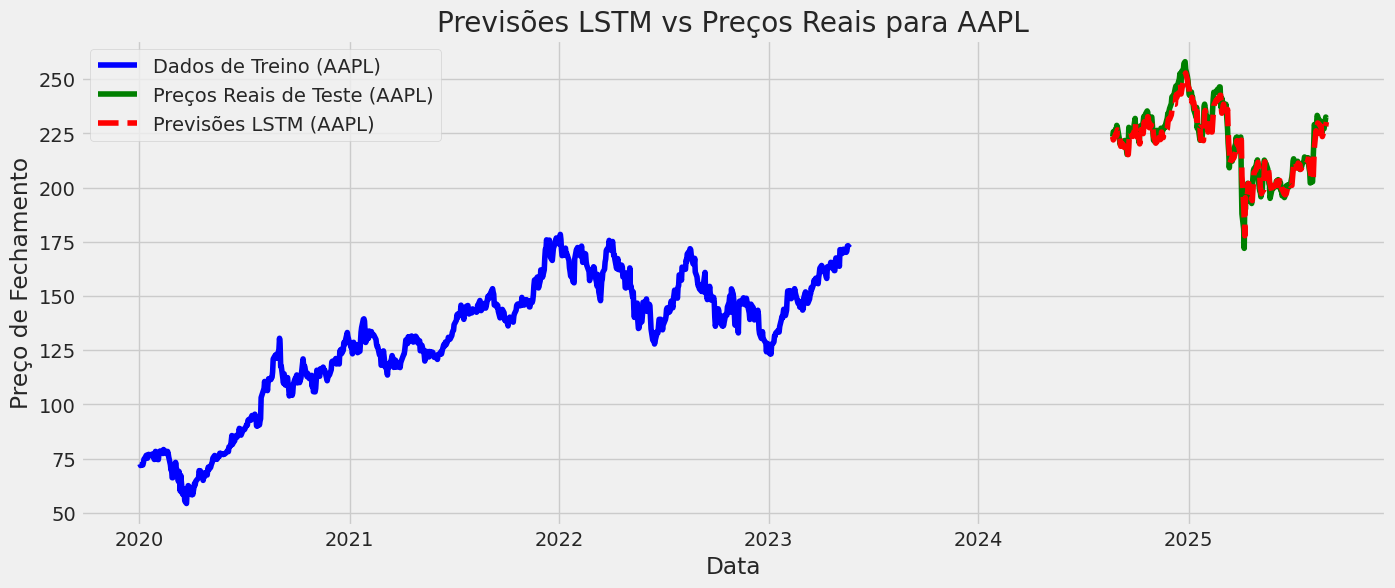

------------------------------

Avaliando e visualizando previsões LSTM para GOOG...
Dados de treino e teste para GOOG obtidos.
Métricas de Avaliação LSTM para GOOG no Teste:
  MSE: 30.669
  RMSE: 5.538
  MAE: 4.651


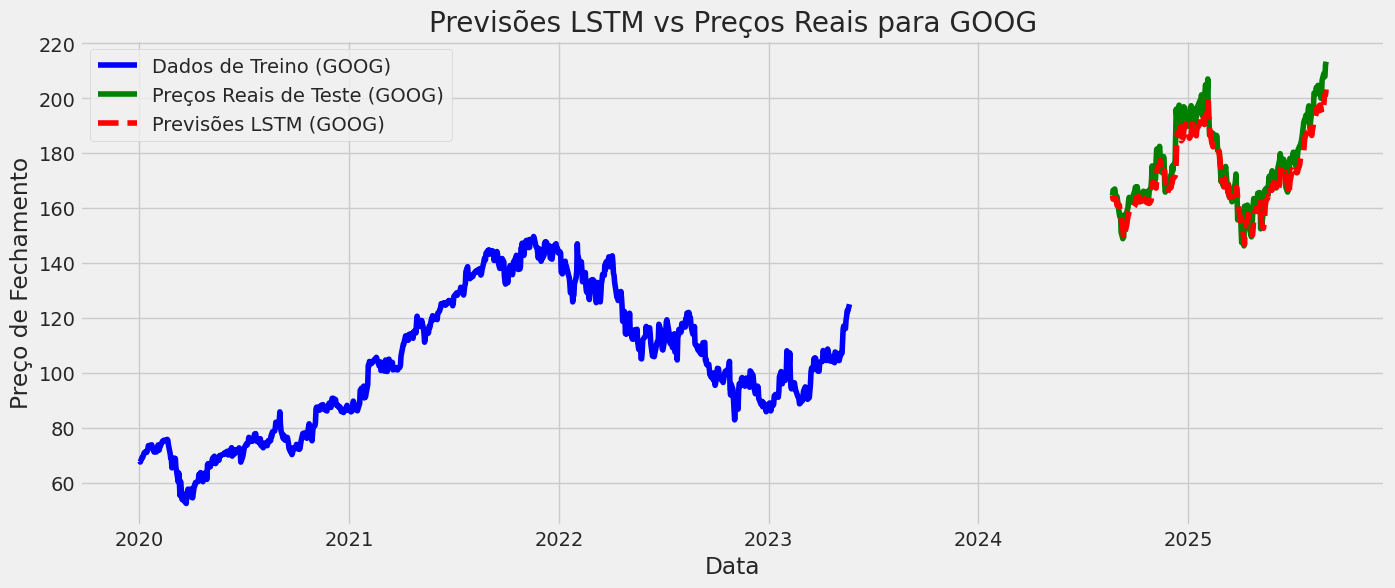

------------------------------

Avaliando e visualizando previsões LSTM para MSFT...
Dados de treino e teste para MSFT obtidos.
Métricas de Avaliação LSTM para MSFT no Teste:
  MSE: 187.453
  RMSE: 13.691
  MAE: 11.739


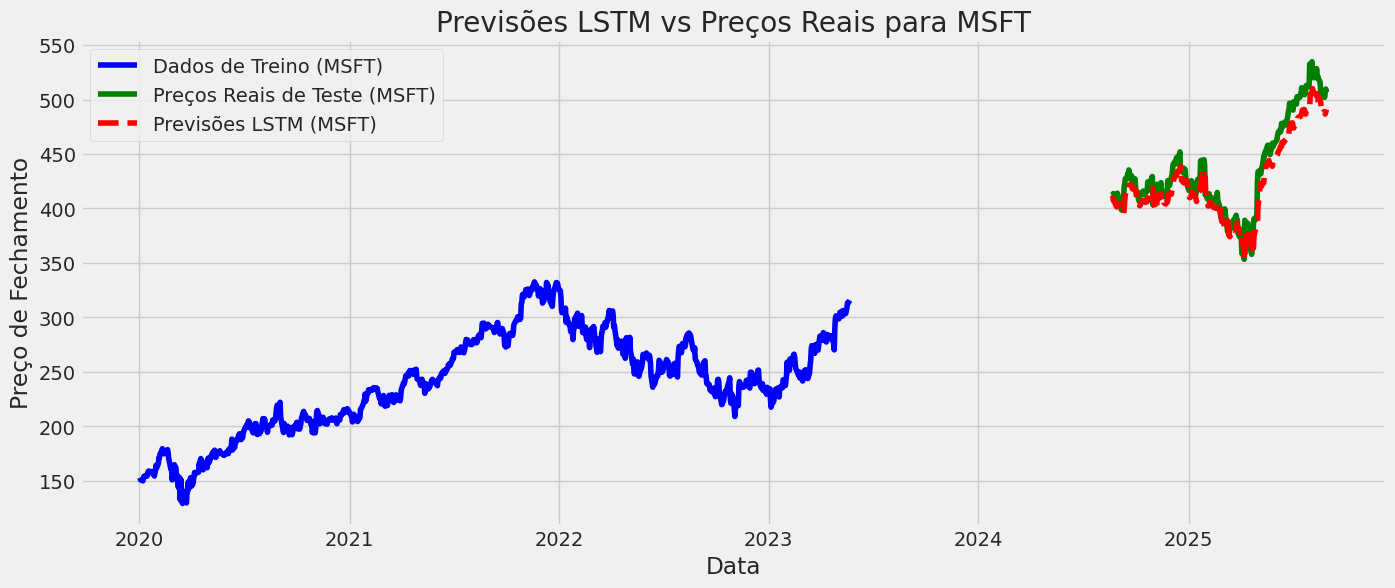

------------------------------

Avaliando e visualizando previsões LSTM para AMZN...
Dados de treino e teste para AMZN obtidos.
Métricas de Avaliação LSTM para AMZN no Teste:
  MSE: 23.055
  RMSE: 4.802
  MAE: 3.678


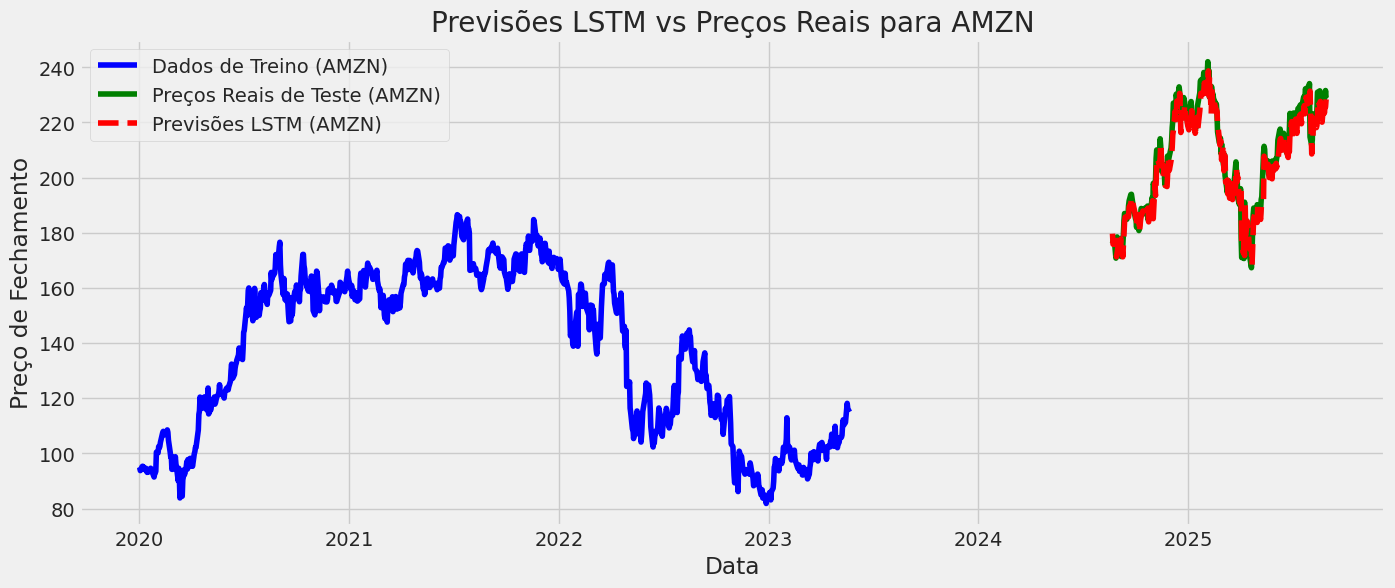

------------------------------

Avaliando e visualizando previsões LSTM para NFLX...
Dados de treino e teste para NFLX obtidos.
Métricas de Avaliação LSTM para NFLX no Teste:
  MSE: 2220.801
  RMSE: 47.125
  MAE: 39.346


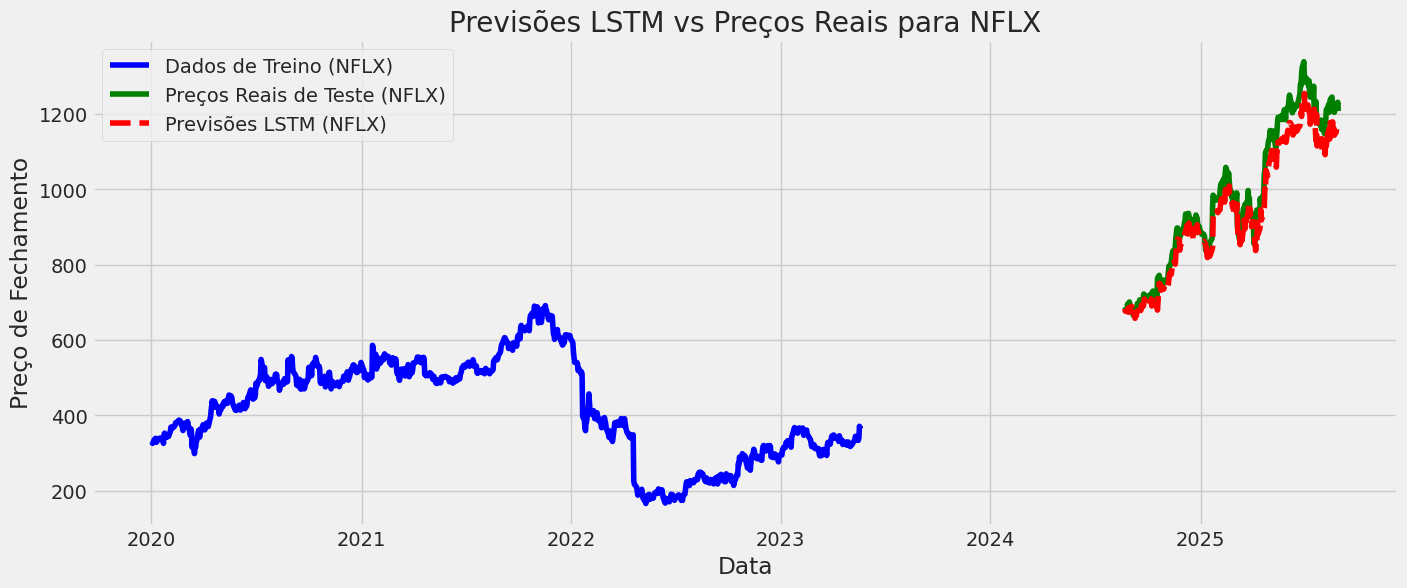

------------------------------

Avaliando e visualizando previsões LSTM para SPOT...
Dados de treino e teste para SPOT obtidos.
Métricas de Avaliação LSTM para SPOT no Teste:
  MSE: 2094.177
  RMSE: 45.762
  MAE: 37.076


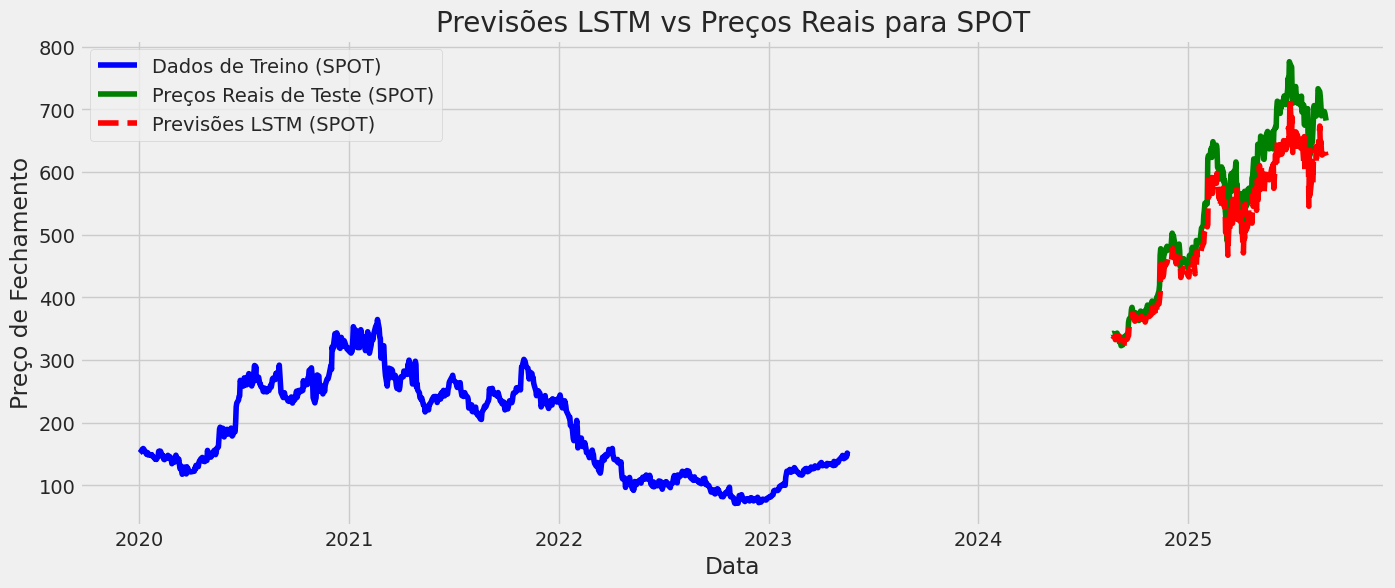

------------------------------

Métricas de Avaliação do Modelo LSTM no Teste (Recalculadas neste passo):


,LSTM MSE (Test),LSTM RMSE (Test),LSTM MAE (Test)
AAPL,19.740352,4.443012,3.274795
GOOG,30.668651,5.537928,4.650588
MSFT,187.452936,13.691345,11.739430
AMZN,23.054783,4.801540,3.678106
NFLX,2220.800703,47.125372,39.345909
SPOT,2094.177071,45.762179,37.075840


In [34]:
# Dicionário para armazenar as métricas de avaliação do LSTM no Teste
# Usaremos lstm_test_metrics populado na avaliação anterior, mas recalcular aqui para consistência com este passo
lstm_test_metrics_recalculated = {}


# Verifica se tech_list, lstm_predictions_original_scale e test_data estão definidos
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida. Por favor, defina a lista de tickers antes de executar esta célula.")
elif 'lstm_predictions_original_scale' not in globals():
    print("Previsões LSTM não encontradas ('lstm_predictions_original_scale'). Por favor, execute a célula de geração de previsões LSTM antes desta.")
elif 'test_data' not in globals():
    print("DataFrame test_data não encontrado. Por favor, execute a célula de divisão de dados antes desta.")
elif 'train_data' not in globals():
     print("DataFrame train_data não encontrado. Por favor, execute a célula de divisão de dados antes desta para visualização.")

else:
    for ticker in tech_list:
        print(f"\nAvaliando e visualizando previsões LSTM para {ticker}...")

        # Obtem as previsões LSTM na escala original para a ação atual
        predictions = lstm_predictions_original_scale.get(ticker)

        # Obtem os dados reais de treino e teste para a ação selecionada
        # Utiliza os DataFrames train_data e test_data criados na divisão cronológica
        # Verifica se os DataFrames contêm o ticker
        if ticker in train_data.columns and ticker in test_data.columns:
            train_data_ticker = train_data[ticker].dropna()
            test_data_ticker = test_data[ticker].dropna()
            print(f"Dados de treino e teste para {ticker} obtidos.")

            # Verifica se as previsões e os dados de teste reais estão disponíveis e não vazios
            if predictions is not None and not predictions.empty and not test_data_ticker.empty:

                # --- Avalia as Previsões ---
                # Precisamos alinhar os valores reais do teste com o índice das previsões para a avaliação
                # As previsões foram geradas para um período específico dentro do test_data_ticker
                # Usar o índice das previsões para selecionar os valores reais correspondentes no test_data_ticker
                # Verificar se o índice das previsões está contido no índice do test_data_ticker
                if predictions.index.isin(test_data_ticker.index).all():
                     actual_test_prices_aligned = test_data_ticker.loc[predictions.index]

                     # Verifica se o comprimento dos dados reais alinhados corresponde ao comprimento das previsões
                     if len(actual_test_prices_aligned) == len(predictions):
                          # Calcula métricas de avaliação
                          mse = mean_squared_error(actual_test_prices_aligned, predictions)
                          rmse = np.sqrt(mse)
                          mae = mean_absolute_error(actual_test_prices_aligned, predictions)

                          lstm_test_metrics_recalculated[ticker] = {
                              'MSE': mse,
                              'RMSE': rmse,
                              'MAE': mae
                          }

                          print(f"Métricas de Avaliação LSTM para {ticker} no Teste:")
                          print(f"  MSE: {mse:.3f}")
                          print(f"  RMSE: {rmse:.3f}")
                          print(f"  MAE: {mae:.3f}")

                     else:
                          print(f"\nO comprimento das previsões LSTM ({len(predictions)}) não corresponde ao comprimento dos preços de teste reais correspondentes ({len(actual_test_prices_aligned)}) para {ticker}. Não é possível calcular métricas.")
                          lstm_test_metrics_recalculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}


                else:
                    print(f"\nO índice das previsões para {ticker} não está completamente contido no índice dos dados de teste reais. Não é possível alinhar para calcular métricas.")
                    lstm_test_metrics_recalculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}


                # --- Visualiza as Previsões ---
                plt.figure(figsize=(15, 6))

                # Plota dados de treino
                plt.plot(train_data_ticker.index, train_data_ticker, label=f'Dados de Treino ({ticker})', color='blue')

                # Plota dados de teste reais (a parte que corresponde às previsões)
                # Usamos actual_test_prices_aligned se o alinhamento foi bem-sucedido, caso contrário, tentamos plotar a parte correspondente do test_data_ticker
                if predictions is not None and not predictions.empty and isinstance(predictions.index, pd.DatetimeIndex) and predictions.index.isin(test_data_ticker.index).all():
                     plt.plot(predictions.index, test_data_ticker.loc[predictions.index], label=f'Preços Reais de Teste ({ticker})', color='green')
                elif not test_data_ticker.empty:
                       if predictions is not None and not predictions.empty and isinstance(predictions.index, pd.DatetimeIndex):
                           try:
                                plt.plot(predictions.index, test_data_ticker.loc[predictions.index], label=f'Preços Reais de Teste ({ticker})', color='green')
                           except KeyError:
                                print(f"Aviso: Chaves de índice de previsão não encontradas no índice de test_data_ticker para {ticker}. Plotagem parcial ou incorreta pode ocorrer.")
                                plt.plot(test_data_ticker.index, test_data_ticker, label=f'Preços Reais de Teste ({ticker})', color='green') # Plota tudo se o alinhamento falhar novamente
                       else:
                            print(f"Aviso: Previsões ou índice de previsão inválido para {ticker}. Plotando test_data_ticker completo.")
                            plt.plot(test_data_ticker.index, test_data_ticker, label=f'Preços Reais de Teste ({ticker})', color='green') # Plota tudo se não houver previsões válidas com índice


                # Plota previsões do LSTM
                if predictions is not None and not predictions.empty and isinstance(predictions.index, pd.DatetimeIndex):
                     plt.plot(predictions.index, predictions, label=f'Previsões LSTM ({ticker})', color='red', linestyle='--')
                else:
                     print(f"Aviso: Não foi possível plotar previsões com índice de data alinhado para {ticker}. Previsões não plotadas.")


                plt.title(f'Previsões LSTM vs Preços Reais para {ticker}')
                plt.xlabel('Data')
                plt.ylabel('Preço de Fechamento')
                plt.legend()
                plt.grid(True)
                plt.show()

            else:
                print(f"Previsões ou dados de teste reais não disponíveis ou vazios para {ticker}. Não é possível avaliar ou gerar o gráfico.")
                lstm_test_metrics_recalculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}


        else:
             print(f"DataFrames de treino ou teste não encontrados ou ticker '{ticker}' não encontrado. Pulando avaliação/visualização para {ticker}.")
             lstm_test_metrics_recalculated[ticker] = {'MSE': np.nan, 'RMSE': np.nan, 'MAE': np.nan}


        print("-" * 30)


    # Exibe as métricas de avaliação do LSTM no conjunto de teste
    print("\nMétricas de Avaliação do Modelo LSTM no Teste (Recalculadas neste passo):")
    display(pd.DataFrame(lstm_test_metrics_recalculated).T.rename(columns={
        'MSE': 'LSTM MSE (Test)',
        'RMSE': 'LSTM RMSE (Test)',
        'MAE': 'LSTM MAE (Test)'
    }))

#Gerar uma tabela comparativa do preço real com o preço previsto pela LSTM

In [35]:
# Cria um dicionário para armazenar DataFrames de comparação para cada empresa
comparison_tables = {}

# Verifica se tech_list, lstm_predictions_original_scale e test_data estão definidos
if 'tech_list' not in globals():
    print("Variável 'tech_list' não definida. Por favor, defina a lista de tickers antes de executar esta célula.")
elif 'lstm_predictions_original_scale' not in globals():
    print("Previsões LSTM não encontradas ('lstm_predictions_original_scale'). Por favor, execute a célula de geração de previsões LSTM antes desta.")
elif 'test_data' not in globals():
    print("DataFrame test_data não encontrado. Por favor, execute a célula de divisão de dados antes desta.")
else:
    for ticker in tech_list:
        print(f"\nCriando tabela de comparação para {ticker}...")

        # Obtem as previsões LSTM e os dados reais de teste para a empresa atual
        predictions = lstm_predictions_original_scale.get(ticker)

        # Obtem os dados reais de teste para a empresa selecionada, tratando possíveis NaNs
        if ticker in test_data.columns:
            test_data_ticker = test_data[ticker].dropna()
            print(f"Dados reais de teste para {ticker} obtidos.")

            # Verifica se as previsões e os dados reais de teste estão disponíveis e não estão vazios
            if predictions is not None and not predictions.empty and not test_data_ticker.empty:
                 # Alinha os preços reais de teste com o índice das previsões para comparação
                 # Garante que o índice das previsões esteja contido no índice dos dados de teste
                 if predictions.index.isin(test_data_ticker.index).all():
                      actual_test_prices_aligned = test_data_ticker.loc[predictions.index]

                      # Cria um DataFrame para comparar preços reais e previstos
                      comparison_df = pd.DataFrame({
                          'Preço Real': actual_test_prices_aligned,
                          'Preço Previsto (LSTM)': predictions
                      })

                      # Armazena o DataFrame de comparação no dicionário
                      comparison_tables[ticker] = comparison_df
                      print(f"Tabela de comparação criada para {ticker}.")

                 else:
                      print(f"\nO índice das previsões para {ticker} não está completamente contido no índice dos dados reais de teste. Não é possível criar a tabela de comparação.")
                      comparison_tables[ticker] = None # Armazenar None se o alinhamento falhou


            else:
                print(f"Previsões ou dados reais de teste não disponíveis ou vazios para {ticker}. Não é possível criar a tabela de comparação.")
                comparison_tables[ticker] = None # Armazenar None se os dados estiverem faltando


        else:
             print(f"Ticker '{ticker}' não encontrado em test_data. Não é possível criar a tabela de comparação para este ticker.")
             comparison_tables[ticker] = None # Armazenar None se o ticker não estiver em test_data


        print("-" * 30)


    print("\nCriação de tabelas de comparação concluída para todas as empresas.")

    # Exibe as tabelas de comparação para cada empresa
    print("\n--- Tabelas de Comparação (Preços Reais vs Preços Previstos) ---")
    for ticker, comparison_df in comparison_tables.items():
        if comparison_df is not None:
            print(f"\n--- {ticker} ---")
            display(comparison_df)
        else:
            print(f"\n--- {ticker}: Tabela de comparação não disponível ---")


Criando tabela de comparação para AAPL...
Dados reais de teste para AAPL obtidos.
Tabela de comparação criada para AAPL.
------------------------------

Criando tabela de comparação para GOOG...
Dados reais de teste para GOOG obtidos.
Tabela de comparação criada para GOOG.
------------------------------

Criando tabela de comparação para MSFT...
Dados reais de teste para MSFT obtidos.
Tabela de comparação criada para MSFT.
------------------------------

Criando tabela de comparação para AMZN...
Dados reais de teste para AMZN obtidos.
Tabela de comparação criada para AMZN.
------------------------------

Criando tabela de comparação para NFLX...
Dados reais de teste para NFLX obtidos.
Tabela de comparação criada para NFLX.
------------------------------

Criando tabela de comparação para SPOT...
Dados reais de teste para SPOT obtidos.
Tabela de comparação criada para SPOT.
------------------------------

Criação de tabelas de comparação concluída para todas as empresas.

--- Tabelas d

,Preço Real,Preço Previsto (LSTM)
Date,,
2024-08-22,223.489883,223.482086
2024-08-23,225.789169,222.015366
2024-08-26,226.127594,223.917496
2024-08-27,226.973663,224.451401
2024-08-28,225.440796,225.180344
...,...,...
2025-08-25,227.160004,226.086243
2025-08-26,229.309998,225.820023
2025-08-27,230.490005,227.506104



--- GOOG ---


,Preço Real,Preço Previsto (LSTM)
Date,,
2024-08-22,164.552261,164.528000
2024-08-23,166.481247,163.280151
2024-08-26,166.978409,163.265839
2024-08-27,165.437210,163.689194
2024-08-28,163.567856,163.313995
...,...,...
2025-08-25,208.973221,197.662323
2025-08-26,207.764297,200.667267
2025-08-27,208.024078,201.271606



--- MSFT ---


...

,Preço Real,Preço Previsto (LSTM)
Date,,
2024-08-22,176.130005,179.684952
2024-08-23,177.039993,175.853348
2024-08-26,175.500000,177.183197
2024-08-27,173.119995,175.675171
2024-08-28,170.800003,173.421295
...,...,...
2025-08-25,227.940002,227.673141
2025-08-26,228.710007,223.388962
2025-08-27,229.119995,225.735596



--- NFLX ---


,Preço Real,Preço Previsto (LSTM)
Date,,
2024-08-22,688.960022,683.213196
2024-08-23,686.729980,676.805115
2024-08-26,688.440002,675.996460
2024-08-27,695.719971,678.170898
2024-08-28,683.840027,684.992493
...,...,...
2025-08-25,1218.069946,1151.255371
2025-08-26,1226.089966,1160.594849
2025-08-27,1223.500000,1163.065308



--- SPOT ---


,Preço Real,Preço Previsto (LSTM)
Date,,
2024-08-22,342.200012,338.521362
2024-08-23,342.489990,337.540955
2024-08-26,336.070007,338.061157
2024-08-27,339.470001,332.429810
2024-08-28,337.559998,335.606354
...,...,...
2025-08-25,694.789978,636.820251
2025-08-26,696.469971,631.566040
2025-08-27,692.989990,634.098083


Com base na tabela de comparação entre os preços reais e os preços previstos pelo modelo LSTM, podemos fazer a seguinte análise sobre as previsões:

1) **Acompanhamento da Tendência:** negrito Observando as tabelas geradas para cada ação, o modelo LSTM demonstrou uma capacidade razoável de seguir a tendência geral dos preços de fechamento no conjunto de teste. Ele parece capturar a direção predominante dos movimentos de preços ao longo do tempo.

2) **Variações e Erros:** Apesar de seguir a tendência, as previsões do LSTM não são perfeitas. Existem variações entre o preço previsto e o preço real em dias específicos. Essas variações são quantificadas pelas métricas de erro (MSE, RMSE, MAE) que calculamos. Um MSE, RMSE ou MAE menor indica que, em média, a diferença entre o valor previsto e o valor real é menor, significando previsões mais próximas da realidade.

3) **Desempenho Variável por Ação:** A qualidade das previsões do LSTM (e dos outros modelos) varia entre as ações. Algumas ações podem ser mais fáceis de prever do que outras, dependendo de sua volatilidade e dos padrões históricos nos dados de teste. As métricas de avaliação mostram essas diferenças de desempenho entre as ações.

4) **Limitações:** Como mencionado na conclusão do projeto, a previsão de preços de ações é inerentemente desafiadora devido à natureza complexa e volátil do mercado. Fatores externos e informações não incluídas no modelo (como notícias, eventos econômicos, etc.) afetam os preços e são difíceis de prever apenas com base no histórico de preços.

O modelo LSTM, como um algoritmo de Deep Learning, conseguiu aprender padrões nos dados históricos para fazer previsões que geralmente acompanham a direção do mercado, mas está sujeito a erros e variações diárias, que são normais em previsões de séries temporais financeiras. A análise das métricas e a visualização gráfica ajudam a entender a magnitude desses erros e a confiança que podemos ter nas previsões.

# Conclusão do Projeto

Este projeto realizou uma análise exploratória e modelagem preditiva dos preços de fechamento de um conjunto de ações de tecnologia (AAPL, GOOG, MSFT, AMZN, NFLX, SPOT) utilizando dados históricos de janeiro de 2020 a agosto de 2025.

A análise inicial dos dados revelou tendências históricas de preços, padrões de volume de negociação e métricas descritivas importantes para cada ação. Exploramos a média móvel para suavizar as flutuações de preços e identificar tendências. A análise de retorno diário médio e Value at Risk (VaR) nos forneceu insights sobre o risco associado a cada ação no período analisado. A matriz de correlação destacou a alta correlação positiva entre os retornos diários da maioria das ações de tecnologia na carteira.

Na fase de modelagem preditiva, foram comparados modelos Baseline (Média Móvel), Random Forest, ARIMA e LSTM. O modelo LSTM foi otimizado e o ARIMA também passou por otimização de hiperparâmetros (ordem p, d, q) usando o conjunto de validação antes de serem avaliados. As métricas de avaliação no conjunto de teste (MSE, RMSE, MAE) foram consolidadas para comparação.

Com base no MSE médio no conjunto de teste, o ranking de desempenho dos modelos, do melhor para o pior, foi:

1.  **ARIMA Otimizado:** Apresentou o menor MSE médio, indicando o melhor desempenho geral.
2.  **LSTM:** Embora não tenha tido o menor MSE médio, demonstrou uma capacidade razoável de seguir a tendência e teve desempenho significativamente superior ao Baseline e Random Forest para a maioria das ações.
3.  **Random Forest (Otimizado):** Teve um desempenho superior ao Baseline, mas geralmente inferior ao ARIMA Otimizado e LSTM em termos de MSE.
4.  **Baseline (Média Móvel):** Como esperado, foi o modelo com o pior desempenho (maior MSE), servindo como um ponto de comparação simples.

As tabelas de comparação entre os preços reais e previstos pela LSTM visualizam a capacidade do modelo de seguir a tendência geral dos preços, embora com variações e erros inerentes à previsão de séries temporais financeiras.

# Limitações do Projeto

É importante reconhecer as limitações deste projeto:

1. **Modelos:** Os modelos utilizados (ARIMA com grade limitada e a arquitetura de LSTM) são relativamente simples e podem não capturar todas as complexidades e não linearidades do mercado de ações. Modelos mais avançados ou ensembles poderiam ser explorados.
2. **Otimização do LSTM:** Embora a otimização de hiperparâmetros para o LSTM tenha sido realizada, a grade de busca utilizada pode ter sido limitada, e **uma otimização mais abrangente poderia levar a um modelo ainda mais preciso.**
3. **Recursos Utilizados:** O projeto focou apenas no preço de fechamento como principal característica de entrada para os modelos preditivos. Fatores externos e outras características (volume, indicadores técnicos, notícias, eventos macroeconômicos) que influenciam os preços das ações não foram incluídos, o que limita a capacidade preditiva dos modelos.
4. **Período de Dados:** A análise e os modelos são baseados em um período de dados específico. O comportamento histórico pode não se repetir no futuro, e os modelos precisam ser reavaliados e retreinados periodicamente.
5. **Divisão de Dados:** A divisão cronológica em treino, validação e teste é padrão, mas diferentes proporções ou técnicas de validação cruzada para séries temporais poderiam ser consideradas.
6. **Natureza do Mercado:** O mercado de ações é inerentemente volátil e influenciado por inúmeros fatores imprevisíveis. Mesmo os modelos mais sofisticados não podem garantir previsões perfeitas. As previsões devem ser usadas como ferramentas de apoio, não como garantia de resultados.
7. **Interpretabilidade do LSTM:** Embora o LSTM tenha apresentado bom desempenho preditivo, sua natureza de "caixa preta" torna a interpretação direta de como ele chega às previsões mais desafiadora em comparação com modelos mais tradicionais como o ARIMA.

#Próximos Passos e Melhorias na Modelagem:

1. **Otimização Mais Abrangente/Robusta do LSTM:** Retomar e concluir uma otimização de hiperparâmetros mais exaustiva para o modelo LSTM (expandindo a grade de busca ou utilizando técnicas como busca aleatória ou otimização Bayesiana) pode levar a um modelo ainda mais preciso.
2. **Explorar Outros Modelos Avançados:** Experimentar outros modelos de séries temporais, como:
   * **SARIMA:** Se houver sazonalidade não capturada pelo ARIMA simples.
   * **Prophet:** Desenvolvido pelo Facebook, é robusto para dados com fortes efeitos sazonais e de feriados.
   * **Modelos de Machine Learning/Deep Learning Mais Complexos:** Redes neurais recorrentes (RNNs) mais profundas, LSTMs Bidirecionais, GRUs, ou até mesmo modelos baseados em Transformers (embora exijam mais dados e poder computacional).
   * **Modelos de Ensemble:** Combinar as previsões de diferentes modelos pode frequentemente levar a resultados mais robustos.
3. **Inclusão de Features Adicionais (Engenharia de Atributos):** A previsão de preços de ações é complexa e não depende apenas do histórico de preços. Incluir outras features relevantes pode melhorar significativamente os modelos:
   * **Indicadores Técnicos:** Médias móveis de diferentes períodos (além da usada como baseline), RSI, MACD, bandas de Bollinger, etc.
   * **Volume de Negociação:** O volume pode indicar a força de um movimento de preço.
   * **Fatores Macroeconômicos:** Taxa de juros, inflação, dados de emprego, etc.
   * **Sentimento de Notícias/Redes Sociais:** Análise de sentimento de notícias relacionadas às empresas ou do sentimento geral do mercado.
   * **Preços de Outras Ações/Índices:** A correlação vista anteriormente sugere que os movimentos de ações correlacionadas são relevantes.
4. **Previsões Multi-passos:** Em vez de prever apenas o próximo dia, explorar a previsão para múltiplos dias ou semanas no futuro. Isso é mais desafiador, mas mais útil para estratégias de investimento de médio prazo.
5. **Considerar a Volatilidade:** Modelos que explicitamente modelam a volatilidade (como modelos GARCH) podem ser úteis para entender e prever a incerteza dos preços.

**Melhorias na Análise e Avaliação:**

6. **Análise Mais Profunda de Resíduos:** Analisar os erros de previsão (resíduos) para identificar padrões não capturados pelos modelos.
7. **Métricas de Avaliação Adicionais:** Considerar outras métricas relevantes para previsão de séries temporais, como MASE (Mean Absolute Scaled Error) ou diferentes tipos de erro percentual.
8. **Backtesting:** Simular estratégias de negociação baseadas nas previsões para avaliar seu desempenho financeiro real no histórico de dados.

**Boas Práticas e Robustez:**

9. **Validação Cruzada para Séries Temporais:** Implementar técnicas de validação cruzada apropriadas para dados de séries temporais (por exemplo, Time Series Split) para obter uma estimativa mais robusta do desempenho do modelo.
10. **Tratamento de Outliers e Eventos Especiais:** Considerar o tratamento específico de outliers extremos ou o impacto de eventos de mercado (como a pandemia de COVID-19, que pode ter impactado os dados iniciais).